In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from autogluon.tabular import TabularPredictor
from sbpy.data import Names
import json
from scipy.stats import poisson
from sklearn.metrics import mean_poisson_deviance, mean_tweedie_deviance
from autogluon.core.metrics import make_scorer
import matplotlib.pyplot as plt
import matplotlib
import statsmodels.api as sm
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

import torch

import datetime

import activityscope_utils as utils
import os
import tempfile

        Use pytest instead. [astropy.tests.runner]
        Use pytest instead. [astropy.utils.decorators]


In [2]:
try:
    import psycopg2
    sbn_pw = os.environ['SBN_PUB_PASSWORD'] # Contact first author if you would like the password, but it's really not necessary for the main result of the paper
    print("SBN_PUB_PASSWORD environment variable is set. Covariance will be pulled in, and the experimental pessimistic second pass will be enabled. (this is not a core feature of the paper)")
except Exception as e:
    print(f"Either SBN_PUB_PASSWORD environment variable is not set or psycopg2 is not available. No covariance will be pulled in, and the experimental pessimistic second pass will be skipped. (this is not a core feature of the paper) Exception: {e}")

SBN_PUB_PASSWORD environment variable is set. Covariance will be pulled in, and the experimental pessimistic second pass will be enabled. (this is not a core feature of the paper)


In [3]:
## MOST IMPORTANT PARAMETER TO SET: do you want the paper's reproducibility snapshot of the data,
## or do you want the latest data?
use_reproducibility_snapshot = True  # If True, will use a reproducibility snapshot of the data. If False, will use the latest data.

In [4]:
# PARAMETERS

# We are doing >= 4 opps as the positive class in the binary classification example
NUM_OPPS_FOR_TRAINING = 4

# Training filters (less than this and we don't trust the orbit)
MIN_ARC_LENGTH_FOR_TRAINING = 20
MIN_NUM_OBS_FOR_TRAINING = 16

# Total training time limit (seconds), don't set below 500, but potentially go up to two hours for maximum performance
TRAINING_TIME_LIMIT = 4000

# Load known active objects and dual designation list from JSON files
# This is NOT used in any way to bias the model results, and if you remove it, the model will still behave overall in roughly the same way.
# Excluding them may improve model performance by reducing noise in the training data, and may allow the next layer of discoveries to emerge more clearly.
with open('known_active_objects.json', 'r') as f:
    known_strongly_suspected_active_objects = json.load(f)

# MPC lists these as (2060) for example and pandas makes that a negative number. We are removing dual asteroid comet designations from the training set.
with open('dual_designation_list.json', 'r') as f:
    dual_designation_list = json.load(f)

# Bringing in Orbit Database, Do Feature Engineering, and Specific Fixes/Filters on it


The `utils.load_all_databases()` function performs comprehensive database loading and initial processing.

**Database Loading:**

- Loads MPC (Minor Planet Center) orbit database from `mpcorb_extended.json.gz

- Creates `Is_Past_Threshold` binary classification target (>= 4 oppositions). Creates `Num_opps_minus_one` regression target (additional oppositions beyond the first) which is the regression target.

- Loads astrometry counts from local JSON file and merges with MPC data. These astrometry counts can be generated using the astrometry_counter.ipynb notebook.

- Loads AstDyS multi-opposition and single-opposition catalogs

- Loads JPL (Jet Propulsion Laboratory) unnumbered objects database

- `filter out unless updated.csv` - objects excluded unless orbit has been updated (arc length changed)

- `filter until further notice.csv` - objects excluded until removed from the file

**Database Cross-Comparison:**

- Applies filter lists to exclude problematic objects:

- Compares MPC orbits with AstDyS to identify multi-opposition discrepancies- Applies magnitude corrections from `absolute magnitude fixes.csv` for objects with known photometry issues

- Compares MPC orbits with JPL for independent verification

**Data Quality Corrections:**

- Computes absolute differences in orbital elements (H magnitude, semi-major axis a, eccentricity e, inclination i) between MPC and AstDyS

- Computes H magnitude differences with JPL- Sets final H magnitude to the **dimmest** (most conservative) value across all three databases


The `utils.feature_engineering()` function then adds **visibility metrics** (apparent magnitudes at various orbital configurations), **orbital dynamics features** (Tisserand parameter, resonances, Trojan classification), and **geometric features** (perihelion direction vectors, declination, galactic plane alignment).

In [5]:
if use_reproducibility_snapshot:
    # Load the reproducibility snapshot of the database from a parquet file
    orb = pd.read_parquet('orb_snapshot.parquet')
else:
    try:
        orb = utils.load_all_databases()
    except Exception as e:
        print(f"Error loading databases: {e}")
        # delete all from .cache folder so that next time it might work
        cache_dir = os.path.join(os.getcwd(), '.cache')
        # delete all files from the cache directory
        for filename in os.listdir(cache_dir):
            file_path = os.path.join(cache_dir, filename)
            try:
                if os.path.isfile(file_path):
                    os.unlink(file_path)
            except Exception as e:
                print(f"Error deleting file {file_path}: {e}")

        raise Exception(f"Failed to load databases. To fix this, try deleting all files in the cache directory: {cache_dir}. Original error: {e}")

# Un-comment this if wishing to make a new shapshot of the database
# orb.to_parquet('orb_snapshot.parquet', compression='zstd', index=False)

# feature_engineering defaults to the lean feature set: it computes everything in mlcols
# below (the orbit-averaged block, and so vis_orbit_mag_multi, is always computed) and
# skips only the exploratory/superseded families -- vis_opp_* and the last-perihelia
# columns. Pass extra_features=True to get those back, byte for byte unchanged.
orb = utils.feature_engineering(orb)

# Filtering of Training Dataset

After database loading and feature engineering, we apply additional filters to create a high-quality training set. These filters ensure the training data consists of well-observed, reliably linked objects with concordant orbital elements across independent databases.

**Extension Difficulty Filter:**

- Merges pre-computed `extension_difficulty` metric (probability an orbit linkage is incorrect)

- We re-calculate extension difficulty later but this is a pre-stored one used only for filtering the training dataset

**Training Set Quality Filters (applied below):**

- See pandas code for exact filters

In [6]:
# This is prior saved extension difficulty which we'll use for filtering purposes up front. We can re-estimate these right after the modeling is done.
extension_difficulty = pd.read_csv("extension_difficulty.csv")
orb = orb.merge(extension_difficulty, on="Principal_desig", how="left")

In [7]:
# A variety of filters to select decent quality orbits for training. We want as few as possible poorly defined orbits and mislinkages in the training database.
# In some ways less is more at this stage so that the model is not confused by noisy data.

orb_decent_orbit = orb[((orb["Arc_length"]>=MIN_ARC_LENGTH_FOR_TRAINING)|(orb["Arc_length"].isna())|(orb["Perihelion_dist"]<1.3)) # allow more NEOs into the training set to boost performance on these
                       &(orb["Num_obs"]>=MIN_NUM_OBS_FOR_TRAINING)
                       &~orb["filtered_out"].astype(bool)
                       # the following 5 filters are to further filter out situations of disagreement between MPC and AstDyS and JPL
                       &(orb["a_diff_abs"]<0.0005)
                       &(orb["e_diff_abs"]<0.00015)
                       &(orb["i_diff_abs"]<0.003)
                       &(orb["multi_opp_disagree"]==0)
                       &((orb["extension_difficulty"]<0.1)| (orb["extension_difficulty"].isna())|(orb["Perihelion_dist"]<1.3)) # allow more NEOs into the training set to boost performance on these, also few mislinkages for these
                       # Use MPC U parameter as another filter
                       &((orb["U"]<9)|(orb["Perihelion_dist"]<1.3)) # allow more NEOs into training
                       # We will not train on known active objects as the model is supposed to reflect the inert asteroid population
                       &~orb["Principal_desig"].isin(known_strongly_suspected_active_objects)
                       &~orb["Number"].isin(dual_designation_list)]

print(f"Total objects in orbit database: {len(orb)}")
print(f"Total objects in decent orbit database: {len(orb_decent_orbit)}")

orb_training = orb_decent_orbit


Total objects in orbit database: 1563218
Total objects in decent orbit database: 1377035


In [8]:
# # The following code can be uncommented in order to remove recently discovered objects which may not have complete ITF and DESDES linkages and may corrupt training slightly. The following is an example of removing entries which are MPEC DOU E2026-L and later.
# orb_training = orb_training[~((orb_training["extension_difficulty"].isna())
#                               &(orb_training["Num_opps"]==1)
#                               &(orb_training["Ref"].str.startswith("E2026"))
#                               &(orb_training["Ref"]>"E2026-L"))]

# Modeling
There are two models: Poisson regression followed by binary classification where the latter model is alloed to reference the out-of-fold predictions by the former.

In [9]:
## FEATURE SELECTION

# These are the features we will use for classification. Ignore all the others in the data. These were selected based on model performance.
# mlcols = ['H', 'Node', "a", "e", 'i', 'vis_flux', 'vis_q', 'orbital_period_sync', 'galactic_inc', 'Perihelion_direction_x_e', 'Perihelion_direction_y_e', 'Perihelion_direction_z_e', 'dec_perihelion',
#            'vis_last_perihelion', 'vis_orbit_flux_opp', 'vis_orbit_flux_multi', 'vis_orbit_mag_multi',
#            'Is_Past_Threshold']
# mlcols = ['H', 'Node', "a", "e", 'i', 'vis_flux', 'vis_q', 'orbital_period_sync', 'Perihelion_direction_x_e', 'Perihelion_direction_y_e',
#            'vis_last_perihelion', 'vis_orbit_mag_multi',
#            'Is_Past_Threshold']

# 'vis_inc' pulled out 'vis_flux', and 'opp_bright_count', too

mlcols = ['H', 'Node', 'a', 'i', 'vis_q',
          'Perihelion_direction_x_e', 'Perihelion_direction_y_e',
          'days_since_last_opp',
          'n_detectable', 'n_detectable_var', 'years_since_first_detectable', 'days_since_last_detectable',
       'Is_Past_Threshold']

# mlcols = ['H', 'Node', 'a', 'vis_flux', 'vis_inc',
#        'Perihelion_direction_z_e', 'Perihelion_direction_y_e',
#        'vis_opp_mean', 'e', 'vis_q', 'vis_timeavg',
#        'spatial_discoverability_fraction'
#        ,'Is_Past_Threshold']

print(f"Number of features used for classification: {len(mlcols) - 1}")

# for the regression model, swap "Is_Past_Threshold" with "Num_opps" in the feature list
mlcols_reg = mlcols.copy()
mlcols_reg.remove("Is_Past_Threshold")
mlcols_reg.append("Num_opps_minus_one")

data_df = orb_training.dropna(subset=["H"])[mlcols].astype(np.float32)
data_df_reg = orb_training.dropna(subset=["H"])[mlcols_reg].astype(np.float32)

# Shared 8-fold assignment so the regression, quantile, and binary predictors use identical splits.
# This eliminates leakage of exp_Num_opps / quantile_Opps OOF features into the binary classifier:
# when fold k is held out for the classifier, the regression OOF predictions on the training folds
# were produced by regressors that also never saw fold k. AutoGluon's groups= auto-excludes this column.
shared_folds = np.random.default_rng(0).integers(0, 8, size=len(data_df))
data_df["Shared_Fold"] = shared_folds
data_df_reg["Shared_Fold"] = shared_folds

# so we don't try to save the heavy models forever since each is intended to be ephemeral for a single run
save_path = os.path.join(tempfile.gettempdir(), 'activityscope_ag')

Number of features used for classification: 12


In [10]:
# KEY TO REGRESSION: We see the first opposition as a given. No object ends up in any orbit database with zero oppositions.
# Then each additional opposition is an approximately Poisson process dependent on visibility factors.
# Poisson assumptions are indeed violated somewhat (survey depth not constant forever in time/history) but this is still likely the best model to use—
# except possibly Tweedie regression which we will evaluate in future work.


# Regression model training
predictor_reg = TabularPredictor(label="Num_opps_minus_one", groups="Shared_Fold", eval_metric=utils.POISSON_SCORER, problem_type='regression', path=os.path.join(save_path, datetime.datetime.now().strftime("%Y%m%d_%H%M%S")))
# Note that in some environments we are seeing problems with parallel fitting using Ray, so sequential is safer and yields more consistent results across more machines and more environments.
predictor_reg.fit(data_df_reg, presets="good_quality", hyperparameters=utils.HYPERPARAMETERS_POISSON, num_stack_levels=0, num_bag_folds=8, dynamic_stacking=False, ag_args_ensemble={"fold_fitting_strategy": "sequential_local"}, time_limit=TRAINING_TIME_LIMIT/3)

# make out-of-fold predictions and add them to orb as well as to data_df
# Ultimately this allows the binary classifier model to leverage the regression model's predictions as a feature
data_df["exp_Num_opps"] = predictor_reg.predict(data_df) + 1


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.6.1
Python Version:     3.11.16
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.6.0: Mon Jan 19 22:00:55 PST 2026; root:xnu-11417.140.69.708.3~1/RELEASE_ARM64_T6000
CPU Count:          10
Pytorch Version:    2.10.0
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       10.29 GB / 32.00 GB (32.2%)
Disk Space Avail:   27.25 GB / 926.35 GB (2.9%)
Presets specified: ['good_quality']
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this risk by setting `save_bag_folds=True`.


Values in column 'Shared_Fold' used as split folds instead of being automatically set. Bagged models will have 8 splits.
Beginning AutoGluon training ... Time limit = 1333s
AutoGluon will save models to "/var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/activityscope_ag/20260911_164110"
Train Data Rows:    1377032
Train Data Columns: 13
Label Column:       Num_opps_minus_one
Problem Type:       regression
Preprocessing data...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    10561.30 MB
	Train Data (Original)  Memory Usage: 63.04 MB (0.6% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
	Stage 4 Generators:
		Fitting DropUniqueF

[1000]	valid_set's poisson: -13.2844	valid_set's mean_poisson_deviance: -0.384184
[1000]	valid_set's poisson: -13.1924	valid_set's mean_poisson_deviance: -0.382557
[1000]	valid_set's poisson: -13.2227	valid_set's mean_poisson_deviance: -0.382861
[1000]	valid_set's poisson: -13.2558	valid_set's mean_poisson_deviance: -0.383641
[1000]	valid_set's poisson: -13.2523	valid_set's mean_poisson_deviance: -0.383837
[1000]	valid_set's poisson: -13.227	valid_set's mean_poisson_deviance: -0.38442
[1000]	valid_set's poisson: -13.2924	valid_set's mean_poisson_deviance: -0.383237
[1000]	valid_set's poisson: -13.1962	valid_set's mean_poisson_deviance: -0.390163


	-0.3844	 = Validation score   (-mean_poisson_deviance)
	452.27s	 = Training   runtime
	15.62s	 = Validation runtime
Fitting model: XGBoost_BAG_L1 ... Training model for up to 861.69s of the 861.69s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=10, gpus=0)
	-0.3784	 = Validation score   (-mean_poisson_deviance)
	820.94s	 = Training   runtime
	6.31s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ... Training model for up to 360.00s of the 32.86s of remaining time.
	Fitting 1 model on all data | Fitting with cpus=10, gpus=0, mem=0.1/6.4 GB
	Ensemble Weights: {'XGBoost_BAG_L1': 0.818, 'LightGBM_BAG_L1': 0.182}
	-0.3781	 = Validation score   (-mean_poisson_deviance)
	0.94s	 = Training   runtime
	0.02s	 = Validation runtime
AutoGluon training complete, total runtime = 1302.07s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 7848.7 rows/s (172129 batch size)
Automatically performing

In [11]:
# provided only for the curious of the models under the hood and the ensembling/stacking process.
predictor_reg.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-0.378076,mean_poisson_deviance,21.950728,1274.153610,0.022750,0.941338,2,False,3
1,XGBoost_BAG_L1,-0.378380,mean_poisson_deviance,6.306832,820.942019,6.306832,820.942019,1,False,2
2,LightGBM_BAG_L1,-0.384364,mean_poisson_deviance,15.621147,452.270254,15.621147,452.270254,1,False,1
3,XGBoost_BAG_L1_FULL,NaN,mean_poisson_deviance,NaN,45.882615,NaN,45.882615,1,True,5
4,WeightedEnsemble_L2_FULL,NaN,mean_poisson_deviance,NaN,66.838623,NaN,0.941338,2,True,6
5,LightGBM_BAG_L1_FULL,NaN,mean_poisson_deviance,NaN,20.014670,NaN,20.014670,1,True,4


In [12]:
data_df["exp_Num_opps"].update(TabularPredictor.predict_oof(predictor_reg) + 1)
# Also expose the regression OOF predictions to the quantile model as a feature.
# Safe under shared folds: for any held-out fold k, the exp_Num_opps values on fold k
# were generated by reg models that excluded fold k, so no label leaks into quant's validation.
data_df_reg["exp_Num_opps"] = data_df["exp_Num_opps"]
# data_df["poisson_cdf_lte4"] = poisson.cdf(4-1, data_df["exp_Num_opps"]-1)

Using OOF from "WeightedEnsemble_L2" as a proxy for "WeightedEnsemble_L2_FULL".
/var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/ipykernel_90507/2806720809.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_df["exp_Num_opps"].update(TabularPredictor.predict_oof(predictor_reg) + 1)


In [13]:
# Quantile regression

# Regression model training
predictor_quant = TabularPredictor(label="Num_opps_minus_one", groups="Shared_Fold", problem_type='quantile', quantile_levels=[0.006], path=os.path.join(save_path, datetime.datetime.now().strftime("%Y%m%d_%H%M%S")))
# Note that in some environments we are seeing problems with parallel fitting using Ray, so sequential is safer and yields more consistent results across more machines and more environments.
predictor_quant.fit(data_df_reg, presets="good_quality", hyperparameters=utils.HYPERPARAMETERS_QUANTILE, num_stack_levels=1, num_bag_folds=8, dynamic_stacking=False, ag_args_ensemble={"fold_fitting_strategy": "sequential_local"}, time_limit=TRAINING_TIME_LIMIT/3)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.6.1
Python Version:     3.11.16
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.6.0: Mon Jan 19 22:00:55 PST 2026; root:xnu-11417.140.69.708.3~1/RELEASE_ARM64_T6000
CPU Count:          10
Pytorch Version:    2.10.0
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       6.61 GB / 32.00 GB (20.7%)
Disk Space Avail:   31.86 GB / 926.35 GB (3.4%)
Presets specified: ['good_quality']
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this risk by setting `save_bag_folds=True`.
Values in c

In [14]:
# provided only for the curious of the models under the hood and the ensembling/stacking process.
predictor_quant.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L3,-0.023320,pinball_loss,48.662032,1263.083521,0.032125,1.702379,3,False,5
1,LightGBMXT_BAG_L2,-0.023371,pinball_loss,48.629907,1261.381142,15.998039,413.555501,2,False,4
2,LightGBMXT_BAG_L1,-0.023384,pinball_loss,29.686198,714.332952,29.686198,714.332952,1,False,1
3,WeightedEnsemble_L2,-0.023384,pinball_loss,29.736160,715.534273,0.049961,1.201321,2,False,3
4,LightGBM_BAG_L1,-0.027110,pinball_loss,2.945670,133.492689,2.945670,133.492689,1,False,2
5,WeightedEnsemble_L3_FULL,NaN,pinball_loss,NaN,164.549492,NaN,1.702379,3,True,10
6,WeightedEnsemble_L2_FULL,NaN,pinball_loss,NaN,121.037054,NaN,1.201321,2,True,8
7,LightGBM_BAG_L1_FULL,NaN,pinball_loss,NaN,13.332971,NaN,13.332971,1,True,7
8,LightGBMXT_BAG_L2_FULL,NaN,pinball_loss,NaN,162.847113,NaN,29.678409,2,True,9
9,LightGBMXT_BAG_L1_FULL,NaN,pinball_loss,NaN,119.835733,NaN,119.835733,1,True,6


In [15]:

# make out-of-fold predictions and add them to orb as well as to data_df
# Ultimately this allows the binary classifier model to leverage the regression model's predictions as a feature
data_df["quantile_Opps"] = predictor_quant.predict(data_df)[0.006] + 1
data_df["quantile_Opps"].update(TabularPredictor.predict_oof(predictor_quant)[0.006] + 1)

Using OOF from "WeightedEnsemble_L3" as a proxy for "WeightedEnsemble_L3_FULL".
/var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/ipykernel_90507/1045314886.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_df["quantile_Opps"].update(TabularPredictor.predict_oof(predictor_quant)[0.006] + 1)


In [16]:
# Binary Classifier Training

# There's a known issue where torch probability calibration dies sometimes with multiple threads. This is a workaround.
torch.set_num_threads(1)

predictor = TabularPredictor(label="Is_Past_Threshold", groups="Shared_Fold", eval_metric='log_loss', path=os.path.join(save_path, datetime.datetime.now().strftime("%Y%m%d_%H%M%S")))
# Note that in some environments we are seeing problems with parallel fitting using Ray, so sequential is safer and yields more consistent results across more machines and more environments.
predictor.fit(data_df, presets="good_quality", hyperparameters=utils.HYPERPARAMETERS_BINARY, num_stack_levels=0, num_bag_folds=8, dynamic_stacking=False, ag_args_ensemble={"fold_fitting_strategy": "sequential_local"}, time_limit=TRAINING_TIME_LIMIT/3)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.6.1
Python Version:     3.11.16
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.6.0: Mon Jan 19 22:00:55 PST 2026; root:xnu-11417.140.69.708.3~1/RELEASE_ARM64_T6000
CPU Count:          10
Pytorch Version:    2.10.0
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       6.87 GB / 32.00 GB (21.5%)
Disk Space Avail:   31.39 GB / 926.35 GB (3.4%)
Presets specified: ['good_quality']
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this risk by setting `save_bag_folds=True`.
Values in c

In [17]:
# provided only for the curious of the models under the hood and the ensembling/stacking process.
predictor.leaderboard()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-0.147018,log_loss,3.619077,359.737002,0.025882,1.905024,2,False,5
1,XGBoost_BAG_L1,-0.147109,log_loss,1.153314,207.133328,1.153314,207.133328,1,False,2
2,XGBoost_tuned_BAG_L1,-0.147320,log_loss,0.721102,78.419667,0.721102,78.419667,1,False,3
3,LightGBM_BAG_L1,-0.147376,log_loss,1.718779,72.278984,1.718779,72.278984,1,False,1
4,LightGBMLarge_BAG_L1,-0.147595,log_loss,2.811628,163.139111,2.811628,163.139111,1,False,4
5,XGBoost_tuned_BAG_L1_FULL,NaN,log_loss,NaN,8.660689,NaN,8.660689,1,True,8
6,XGBoost_BAG_L1_FULL,NaN,log_loss,NaN,23.196765,NaN,23.196765,1,True,7
7,WeightedEnsemble_L2_FULL,NaN,log_loss,NaN,48.477607,NaN,1.905024,2,True,10
8,LightGBM_BAG_L1_FULL,NaN,log_loss,NaN,14.715129,NaN,14.715129,1,True,6
9,LightGBMLarge_BAG_L1_FULL,NaN,log_loss,NaN,29.388579,NaN,29.388579,1,True,9


# Make Predictions
The two key predictions are exp_Num_opps and prob from the two models.
Note that the out-of-fold predictions are used for anything that was included in training data.

In [18]:
# Hard code both 2009 DP2 and 2024 XE22 to Num_opps = 1 with Arc_length of 22 for illustration purposes
# this is so that we can clearly show what the scores were WHEN THE MODEL FLAGGED THEM as single-opp comets
orb.loc[orb["Principal_desig"]=="2009 DP2", "Num_opps"] = 1
orb.loc[orb["Principal_desig"]=="2024 XE22", "Num_opps"] = 1
orb.loc[orb["Principal_desig"]=="2009 DP2", "Arc_length"] = 22 # dummy length of an "immanently extensible" arc
orb.loc[orb["Principal_desig"]=="2024 XE22", "Arc_length"] = 22 # dummy length of an "immanently extensible" arc

In [19]:
# # Anything with more than 16 oppositions doesn't need much analysis, and no absolute magnitude means fundamentally impossible to apply these methods
# orb_pred = orb[(orb["Num_opps"]<=16)].dropna(subset=["H_MPC","H_astdys","H_jpl"], how='all')

# No absolute magnitude means fundamentally impossible to apply these methods
orb_pred = orb.dropna(subset=["H_MPC","H_astdys","H_jpl"], how='all').copy()

orb_pred = utils.apply_nights_overrides(orb_pred)
orb_pred = utils.apply_magnitude_corrections(orb_pred)

# Now the predictions for the regression model
orb_pred["exp_Num_opps"] = predictor_reg.predict(orb_pred) + 1
orb_pred["exp_Num_opps"].update(TabularPredictor.predict_oof(predictor_reg) + 1)

orb_pred["quantile_Opps"] = predictor_quant.predict(orb_pred)[0.006] + 1
orb_pred["quantile_Opps"].update(TabularPredictor.predict_oof(predictor_quant)[0.006] + 1)

# Predictions for the probabalistic binary classification model
# predict_proba to set probs in orb_pred (this sets the probability for anything not in the training dataset, but anything in the training will get overridden in the next line)
orb_pred["prob"] = predictor.predict_proba(orb_pred)[1]
# override the prob field in orb_pred to ag_probs lining up data index, but only for the rows that exist in both (same index in both)
orb_pred["prob"].update(TabularPredictor.predict_proba_oof(predictor)[1])

orb_pred["poisson_cdf"] = poisson.cdf(orb_pred["Num_opps"]-1, orb_pred["exp_Num_opps"]-1)

Using OOF from "WeightedEnsemble_L2" as a proxy for "WeightedEnsemble_L2_FULL".
/var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/ipykernel_90507/4279286315.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  orb_pred["exp_Num_opps"].update(TabularPredictor.predict_oof(predictor_reg) + 1)
Using OOF from "WeightedEnsemble_L3" as a proxy for "WeightedEnsemble_L3_FULL".
/var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/ipykernel_90507/4279286315.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series t

In [20]:
def getFinal(orb_pred):
    final = orb_pred.copy()

    # renames of Perihelion_dist to q and Aphelion_dist to Q for brevity
    final.rename(columns={"Perihelion_dist":"q","Aphelion_dist":"Q"},inplace=True)
    final.set_index("Principal_desig", inplace=True)

    # Calculate "quantile deficit"
    final['DeltaQ'] = final["quantile_Opps"]-final["Num_opps"]
    final.sort_values("DeltaQ",ascending=False, inplace=True)

    # Mark which ones are known or strongly suspected
    final["Known / Strong Suspect"] = final.index.isin(known_strongly_suspected_active_objects)
    return final

final = getFinal(orb_pred)

# Extension Difficulty Classifier


The `extension_difficulty` feature quantifies how challenging it is to extend an object's orbit, capturing two distinct situations which would make it difficult or impossible to recover/extend using the ITF. In the case of mislinkage, recovery/extension is impossible as the object does not exist and the orbit is nonsense. In the case of orbital uncertainty too high to recover the object, it may be possible to recover in the ITF but difficult because of the sheer number of plausible tracklets that might match it.

This classifier uses the principle that highly-rated objects from the prior ML models that remain single opposition are more representative of "difficult to extend" objects. The extension difficulty is based primarily on astrometry metadata (e.g., number of nights, arc length, gap patterns) rather than orbital elements themselves.

In [21]:
#reload activityscope_utils to get the latest version of the function that trains the extension difficulty classifier, which is the next step after we have the regression and binary classification predictions in place.
import importlib
importlib.reload(utils)

# Train extension difficulty classifier
orb_pred, final = utils.train_extension_difficulty_classifier(orb_pred, final, orb)

# filter out objects marked in either of the two named filter csvs
orb_pred_incl_mislinkages = orb_pred.copy()
orb_pred = orb_pred[~orb_pred["filtered_out"].astype(bool)]
final = final[~final["filtered_out"].astype(bool)]
orb_pred_incl_mislinkages = getFinal(orb_pred_incl_mislinkages)

Positive examples from filter list: 43
Positive examples from multi-opp mislinkages: 96
Positive examples (high extension difficulty): 1722
Negative examples (low extension difficulty): 456895
Training set after refinement: 457866


# Pessimistic Second Pass (`prob_pessimistic`)

This is not part of the paper and is provided only as an experimental feature.

This does LOV analysis and tries 5 LOV nodes, also offsetting H by 0.3 mag dimmer. After trying all 10 of these, it takes the lowest prob and calls it prob_pessimistic, essentially answering the question: "How much lower would prob be if a variant orbit were used (compatible but not nominal) and if we assumed a slight overestimate of brightness?"


In [22]:
# reimport "import activityscope_utils as utils" / reload the package
import importlib
import activityscope_utils as utils
importlib.reload(utils)


# if sbn_pw is set do the following
if 'sbn_pw' in globals():
    # Pessimistic second pass: re-score the strongest single-opposition candidates on the
    # LOWER BOUND of n_detectable over the orbit covariance and a fainter H, rather than the point
    # estimate. See utils.pessimistic_detectable_bounds; the bound costs ten evaluations but only
    # five orbit propagations, since the two H scenarios share their geometry.
    PESSIMISTIC_PROB_MIN = 0.99      # only the candidates that would actually be acted on
    PESSIMISTIC_H_OFFSET = 0.3       # magnitudes fainter: the less optimistic photometry
    PESSIMISTIC_LOV_NODES = 5        # a short-arc covariance is ~99.9% rank one

    _DET_COLS = list(utils.DETECTABLE_COLS)   # n_detectable, n_detectable_var, years_since_first_detectable, days_since_last_detectable

    # The pass is optional (not a core feature of the paper): without SBN_PUB_PASSWORD the
    # columns it fills are left NaN so the ranking tables below still work.
    for _frame in (orb_pred, final):
        for _col in ("prob_pessimistic", "n_detectable_lower", "n_detectable_point"):
            _frame[_col] = np.nan
    final["DeltaQ_pessimistic"] = np.nan
    final["initial_linkage_sbn"] = pd.NaT

    if "SBN_PUB_PASSWORD" not in os.environ:
        print("SBN_PUB_PASSWORD not set: skipping the pessimistic second pass; prob_pessimistic left NaN")
    else:
        _cand = orb_pred[(orb_pred["Num_opps"] == 1)
                        & (orb_pred["prob"] > PESSIMISTIC_PROB_MIN)].copy()
        _cand = _cand.drop(columns=["prob_pessimistic", "n_detectable_lower", "n_detectable_point"], errors="ignore")
        print(f"pessimistic pass: {len(_cand)} single-opposition candidates with prob > {PESSIMISTIC_PROB_MIN}")

        _desigs = _cand["Principal_desig"].astype(str).tolist()
        _conn = utils.sbn_connect()
        try:
            _cov = {}
            for _lo in range(0, len(_desigs), 5000):
                _cov.update(utils.sbn_fetch_covariances(_desigs[_lo:_lo + 5000], conn=_conn))
        finally:
            _conn.close()
        print(f"  {len(_cov)} of them have a covariance in public.mpc_orbits")

        _bounds = utils.pessimistic_detectable_bounds(_cov, n_nodes=PESSIMISTIC_LOV_NODES,
                                                    h_offset=PESSIMISTIC_H_OFFSET)

        # Substitute the minimising scenario's four apparition features and re-run the whole chain:
        # the binary classifier takes exp_Num_opps and quantile_Opps as features, so those must be
        # recomputed too. Counterfactual rows are scored with the fitted models rather than the
        # out-of-fold predictions, following the H-sweep above; for candidates that were in training
        # this makes prob_pessimistic very slightly optimistic relative to their out-of-fold prob.
        _scen = _cand.merge(_bounds[["Principal_desig", "n_detectable_nominal", "n_detectable_upper"]
                                    + [c + "_lower" for c in _DET_COLS]],
                            on="Principal_desig", how="inner")
        if len(_scen):
            _scen["n_detectable_point"] = _scen["n_detectable"]
            for _c in _DET_COLS:
                _scen[_c] = _scen[_c + "_lower"]          # the substitution
            _scen["exp_Num_opps"] = predictor_reg.predict(_scen) + 1
            _scen["quantile_Opps"] = predictor_quant.predict(_scen)[0.006] + 1
            _scen["prob_pessimistic"] = predictor.predict_proba(_scen)[1]

            _by_desig = _scen.set_index("Principal_desig")
            for _frame, _key in ((orb_pred, orb_pred["Principal_desig"]), (final, final.index)):
                for _col in ("prob_pessimistic", "n_detectable_lower", "n_detectable_point"):
                    _frame[_col] = pd.Series(_by_desig[_col]).reindex(_key).to_numpy()
            # DeltaQ under the pessimistic scenario, for ranking consistency with DeltaQ
            final["DeltaQ_pessimistic"] = (pd.Series(_by_desig["quantile_Opps"])
                                        .reindex(final.index).to_numpy() - final["Num_opps"])

            _moved = _scen.sort_values("prob_pessimistic", ascending=False)
            print(f"  scored {len(_scen)}; median prob {_scen['prob'].median():.4f} -> "
                f"prob_pessimistic {_scen['prob_pessimistic'].median():.4f}")
            # display(_moved[["Principal_desig", "H", "Num_obs", "Arc_length", "U",
            #                 "n_detectable_point", "n_detectable_lower", "prob", "prob_pessimistic"]].head(25))
        else:
            print("  no candidates with covariances; prob_pessimistic left NaN")
else:
    # add prob_pessimistic as a null to the final DataFrame
    final["prob_pessimistic"] = np.nan
    final["initial_linkage_sbn"] = pd.NaT

pessimistic pass: 1372 single-opposition candidates with prob > 0.99
  1367 of them have a covariance in public.mpc_orbits
  scored 1367; median prob 0.9995 -> prob_pessimistic 0.5429


In [23]:
# # output Updated extension_difficulty.csv for future runs (uncomment to update this)
# orb_pred[["Principal_desig", "extension_difficulty"]].to_csv("extension_difficulty.csv", index=False)

In [24]:
# Out of curiousity, how many objects exist in the MPC database with at least moderately high extension difficulty (greater than 0.8)?
# Not all of these will be mislinkages! Many will simply be unconstrained orbits. It's like there is a decent number of mislinkages though (minimum 250, possibly over 1000?)
print(f"Number of objects with extension difficulty > 0.8: {final[final['extension_difficulty']>0.8].shape[0]}")

Number of objects with extension difficulty > 0.8: 3312


# Centralized Ranking using DeltaQ and extension_difficulty

This is somewhat experimental, but it is the best unified system for identifying active objects.

In [25]:
extension_difficulty_threshold = 0.9

default_col_set = ["prob", "prob_pessimistic", "DeltaQ", "poisson_cdf", "extension_difficulty", "Num_opps", "quantile_Opps", "exp_Num_opps", "nights_total",  "Ref", "Num_obs", "Arc_length", "U","a","i","H","q","TJ"]
# engineer a feature that grades overall "priority" of follow up based on a gradient such that up and to the left on the scatterplot below is higher priority and lines of equal priority are parallel
final["priority_score"] = final["DeltaQ"] - (final["extension_difficulty"] * 15.5)

combined_rankings = final[((final["Arc_length"]>=8)|(final["Arc_length"].isna()))
      &(final["Num_obs"]>=6)

      # Admitted this is a bit of a hack but it excludes THOR objects with odd sparsity
      &((final["Num_obs"]>=7)|(final["nights_total"]>=5))

      &(final["DeltaQ"]>0.3*final["quantile_Opps"])

      &(final["prob"]>0.9)
      &(final["q"]>1.1)
      &((final["extension_difficulty"].between(0,extension_difficulty_threshold))|(final["nights_total"].isna()))
      &(final["Orbital_period"]<20)].copy()

combined_rankings.sort_values("priority_score", ascending=False, inplace=True)

In [26]:
# Top ratings by priority score which uses both DeltaQ and extension difficulty
# willing to prioritize a high DeltaQ for evaluation even if moderate extension_difficulty
##### NOTICE THE (almost) LINEAR SEPARABILITY OF THIS RANKING SYSTEM ########
# (as long as we are regularly running ITF extension routines and DESDES, this will be pretty much true)
combined_rankings.head(1000)[['Known / Strong Suspect']+default_col_set].head(25)

,Known / Strong Suspect,prob,prob_pessimistic,DeltaQ,poisson_cdf,extension_difficulty,Num_opps,quantile_Opps,exp_Num_opps,nights_total,Ref,Num_obs,Arc_length,U,a,i,H,q,TJ
Principal_desig,,,,,,,,,,,,,,,,,,,
2025 HV38,True,0.999992,0.999992,16.689064,2.112428e-09,0.000002,1,17.689064,20.975428,18.0,MPO988024,48,51,8,2.484172,7.24007,15.42,2.366069,3.463847
2008 BJ22,True,0.999991,0.999991,15.906303,2.776332e-09,0.000014,1,16.906303,20.702135,13.0,MPO732621,53,83,4,3.073201,11.51245,15.20,2.942906,3.197832
2008 GO98,True,0.999992,NaN,14.007002,1.961240e-05,0.000028,7,21.007002,24.473412,NaN,MPO969452,1549,<NA>,0,3.971173,15.55983,12.91,2.864301,2.92673
2019 OE31,True,0.999989,0.999989,12.203197,1.044393e-07,0.000071,1,13.203197,17.074659,10.0,E2024-JA9,32,137,3,4.381322,5.22115,14.64,3.942522,3.006031
2003 BM80,True,0.999992,NaN,12.049309,1.007258e-04,0.000028,7,19.049309,22.279791,NaN,MPO984040,222,<NA>,0,4.234372,5.81319,13.62,3.438718,2.991756
2010 RH69,True,0.999992,NaN,11.556589,4.026698e-06,0.000139,3,14.556589,18.576057,11.0,MPO619842,31,<NA>,5,4.532396,11.54822,13.95,4.276048,2.97391
2001 BV70,True,0.999992,0.999836,11.138252,2.564328e-07,0.000164,1,12.138252,16.176399,8.0,MPO 13809,32,50,10,3.593632,4.33032,15.14,2.063079,2.947403
2007 VB146,True,0.999991,0.999992,9.955434,1.056960e-06,0.001466,1,10.955434,14.760114,4.0,MPO130330,13,16,10,2.752892,3.49271,16.94,2.439879,3.332674
2015 BC566,True,0.999992,0.999992,8.813442,3.839168e-06,0.000003,1,9.813442,13.470255,11.0,MPO771428,52,39,5,3.06321,11.68986,16.33,2.951045,3.200295


In [103]:
# only the known/suspected:
final[final['Known / Strong Suspect']][['Known / Strong Suspect']+default_col_set].head(25)

,Known / Strong Suspect,prob,prob_pessimistic,DeltaQ,poisson_cdf,extension_difficulty,Num_opps,quantile_Opps,exp_Num_opps,nights_total,Ref,Num_obs,Arc_length,U,a,i,H,q,TJ
Principal_desig,,,,,,,,,,,,,,,,,,,
2025 HV38,True,0.999992,0.999992,16.689064,2.112428e-09,0.000002,1,17.689064,20.975428,18.0,MPO988024,48,51,8,2.484172,7.24007,15.42,2.366069,3.463847
2008 BJ22,True,0.999991,0.999991,15.906303,2.776332e-09,0.000014,1,16.906303,20.702135,13.0,MPO732621,53,83,4,3.073201,11.51245,15.20,2.942906,3.197832
2008 GO98,True,0.999992,NaN,14.007002,1.961240e-05,0.000028,7,21.007002,24.473412,NaN,MPO969452,1549,<NA>,0,3.971173,15.55983,12.91,2.864301,2.92673
2019 OE31,True,0.999989,0.999989,12.203197,1.044393e-07,0.000071,1,13.203197,17.074659,10.0,E2024-JA9,32,137,3,4.381322,5.22115,14.64,3.942522,3.006031
2003 BM80,True,0.999992,NaN,12.049309,1.007258e-04,0.000028,7,19.049309,22.279791,NaN,MPO984040,222,<NA>,0,4.234372,5.81319,13.62,3.438718,2.991756
2010 RH69,True,0.999992,NaN,11.556589,4.026698e-06,0.000139,3,14.556589,18.576057,11.0,MPO619842,31,<NA>,5,4.532396,11.54822,13.95,4.276048,2.97391
2001 BV70,True,0.999992,0.999836,11.138252,2.564328e-07,0.000164,1,12.138252,16.176399,8.0,MPO 13809,32,50,10,3.593632,4.33032,15.14,2.063079,2.947403
2007 VB146,True,0.999991,0.999992,9.955434,1.056960e-06,0.001466,1,10.955434,14.760114,4.0,MPO130330,13,16,10,2.752892,3.49271,16.94,2.439879,3.332674
2015 BC566,True,0.999992,0.999992,8.813442,3.839168e-06,0.000003,1,9.813442,13.470255,11.0,MPO771428,52,39,5,3.06321,11.68986,16.33,2.951045,3.200295


In [27]:
# Counterfactual H sweep: hold each candidate's orbital and astrometric data fixed,
# then recompute H-dependent visibility features before applying the regression model.
H_NEUTRALITY_PROBABILITY_MIN = 0.998
H_NEUTRALITY_EXTENSION_DIFFICULTY_MAX = 0.5
H_NEUTRALITY_TOLERANCE = 0.5
H_GRID = np.arange(5.0, 30.01, 0.05)
H_NEUTRALITY_MAX_OBJECTS = 250

h_neutrality_candidates = combined_rankings[
    (combined_rankings["prob"] >= H_NEUTRALITY_PROBABILITY_MIN)
    & (combined_rankings["extension_difficulty"] <= H_NEUTRALITY_EXTENSION_DIFFICULTY_MAX)
    & combined_rankings["Num_opps"].notna()
].head(H_NEUTRALITY_MAX_OBJECTS)

h_neutrality_results = []
for designation, candidate in h_neutrality_candidates.iterrows():
    observed_num_opps = float(candidate["Num_opps"])
    h_scenarios = pd.DataFrame([candidate] * len(H_GRID))
    h_scenarios["H"] = H_GRID
    h_scenarios = utils.feature_engineering(h_scenarios)
    swept_exp_num_opps = np.asarray(predictor_reg.predict(h_scenarios), dtype=float) + 1
    residuals = np.abs(swept_exp_num_opps - observed_num_opps)
    neutral_indices = np.flatnonzero(residuals <= H_NEUTRALITY_TOLERANCE)
    if len(neutral_indices):
        best_index = neutral_indices[
            np.abs(H_GRID[neutral_indices] - candidate["H"]).argmin()
        ]
    else:
        best_index = residuals.argmin()
    h_neutrality_results.append({
        "Designation": designation,
        "extension_difficulty": candidate["extension_difficulty"],
        "H_current": candidate["H"],
        "H_neutral": H_GRID[best_index],
        "H_change_to_neutral": H_GRID[best_index] - candidate["H"],
        
        "Num_opps": observed_num_opps,
        "exp_Num_opps_at_neutral_H": swept_exp_num_opps[best_index],
        "neutrality_residual": residuals[best_index],
        "neutral_within_0p5": residuals[best_index] <= H_NEUTRALITY_TOLERANCE,
        "prob": candidate["prob"],
        
        "priority_score": candidate["priority_score"],
    })

h_neutrality = pd.DataFrame(h_neutrality_results).sort_values(
    ["neutral_within_0p5", "H_change_to_neutral", "priority_score"],
    ascending=[False, False, False],
)
h_neutrality.head(25)

,Designation,extension_difficulty,H_current,H_neutral,H_change_to_neutral,Num_opps,exp_Num_opps_at_neutral_H,neutrality_residual,neutral_within_0p5,prob,priority_score
0,2025 HV38,0.000002,15.42,20.55,5.13,1.0,1.438589,0.438589,True,0.999992,16.689033
1,2008 BJ22,0.000014,15.20,19.45,4.25,1.0,1.498201,0.498201,True,0.999991,15.906086
6,2001 BV70,0.000164,15.14,19.10,3.96,1.0,1.475006,0.475006,True,0.999992,11.135710
114,2020 VJ34,0.338517,17.83,21.45,3.62,1.0,1.282576,0.282576,True,0.998066,-1.950109
11,2009 FP8,0.000038,16.94,20.55,3.61,1.0,1.443047,0.443047,True,0.999987,6.795475
17,2025 QB175,0.022956,18.07,21.45,3.38,1.0,1.447633,0.447633,True,0.999844,4.036125
105,2023 WZ43,0.496154,17.78,21.10,3.32,1.0,1.368236,0.368236,True,0.999992,-0.418729
119,2016 WV86,0.445038,18.00,21.20,3.20,1.0,1.499442,0.499442,True,0.999415,-3.168375
2,2008 GO98,0.000028,12.91,16.10,3.19,7.0,7.393101,0.393101,True,0.999992,14.006568
30,2002 FU44,0.335138,14.38,17.50,3.12,1.0,1.465017,0.465017,True,0.999963,2.815344


In [28]:
# New ones to consider and work:
combined_rankings[~combined_rankings["Known / Strong Suspect"]][default_col_set].to_clipboard()
combined_rankings[~combined_rankings["Known / Strong Suspect"]][default_col_set].head(20)

,prob,prob_pessimistic,DeltaQ,poisson_cdf,extension_difficulty,Num_opps,quantile_Opps,exp_Num_opps,nights_total,Ref,Num_obs,Arc_length,U,a,i,H,q,TJ
Principal_desig,,,,,,,,,,,,,,,,,,
2001 UY217,0.999962,0.956172,5.037077,0.000150,0.008505,1,6.037077,9.802517,4.0,MPO285656,13,9,10,2.107378,2.67958,19.09,1.719158,3.718634
2025 QB175,0.999844,0.487919,4.391943,0.000244,0.022956,1,5.391943,9.318005,3.0,E2026-HE1,8,11,9,2.734152,0.38037,18.07,2.268057,3.331534
2021 PM141,0.997779,0.757151,3.454135,0.000367,0.000033,1,4.454135,8.910940,5.0,MPO680902,18,37,4,3.166015,9.59919,17.10,2.877454,3.17527
2024 TR15,0.997865,0.972583,3.383703,0.000492,0.000095,1,4.383703,8.617723,4.0,MPO873056,13,10,6,3.036671,9.13842,17.27,2.828388,3.218368
2006 QX142,0.999377,0.947368,3.461029,0.000977,0.009194,1,4.461029,7.931071,4.0,MPO960587,13,14,9,2.73949,0.86834,17.95,2.054292,3.304206
2026 PJ16,0.999241,0.979352,3.62364,0.000313,0.022028,1,4.623640,9.069344,NaN,E2026-RB7,13,28,7,2.166404,1.16218,19.23,2.002136,3.68824
2014 DV193,0.999500,NaN,3.268724,0.001849,0.000171,2,5.268724,9.549870,5.0,MPO677854,18,<NA>,4,2.557255,3.50419,18.20,2.379007,3.430714
2007 RY230,0.999972,NaN,3.192852,0.006227,0.000005,4,7.192852,11.684912,17.0,MPO659887,69,<NA>,0,2.79993,2.74579,17.52,2.540633,3.317436
2016 AH333,0.997251,0.567437,3.202616,0.000457,0.001576,1,4.202616,8.691185,4.0,MPO603269,12,34,5,3.154608,7.41891,17.10,3.001613,3.191792


In [29]:
# New ones to consider and work:
z = combined_rankings[combined_rankings["prob_pessimistic"]>0.993]
z[~z["Known / Strong Suspect"]][default_col_set+['v_mag_avg']].sort_values("extension_difficulty", ascending=True)

,prob,prob_pessimistic,DeltaQ,poisson_cdf,extension_difficulty,Num_opps,quantile_Opps,exp_Num_opps,nights_total,Ref,Num_obs,Arc_length,U,a,i,H,q,TJ,v_mag_avg
Principal_desig,,,,,,,,,,,,,,,,,,,
2024 WC87,0.999327,0.995498,3.382324,0.000819,0.294752,1,4.382324,8.107050,3.0,MPO886973,12,22,5,2.472883,6.06682,18.34,2.052664,3.45517,21.977273
2023 SN79,0.999837,0.998224,4.433005,0.000396,0.369458,1,5.433005,8.834803,3.0,MPO811336,12,29,6,2.96826,8.59588,17.32,2.384983,3.217404,21.829167
2015 PF156,0.999990,0.999388,5.025169,0.000070,0.372744,1,6.025169,10.573647,3.0,MPO839241,9,27,7,2.812708,12.58886,16.56,1.463558,3.109095,21.920000
2016 EA382,0.999686,0.995962,3.90554,0.000474,0.379078,1,4.905540,8.653849,3.0,MPO870180,12,30,6,3.332936,7.75487,16.54,2.135639,3.041297,21.668333
2023 WZ43,0.999992,0.999986,7.271658,0.000022,0.496154,1,8.271658,11.721279,3.0,MPO793415,9,26,7,2.312829,8.06358,17.78,1.641763,3.51309,22.263333
2006 JE41,0.999986,0.994079,6.419292,0.000032,0.639332,1,7.419292,11.355620,3.0,MPO102346,16,14,10,2.267336,2.08041,18.42,1.83257,3.589674,20.243750
2023 FJ17,0.999991,0.999888,5.830195,0.000064,0.640913,1,6.830195,10.660779,3.0,E2024-U35,10,28,6,2.844615,8.1468,16.92,2.237396,3.259224,22.146000
2022 UD92,0.999992,0.999991,7.116449,0.000024,0.650989,1,8.116449,11.623616,3.0,MPO727159,12,27,7,2.931673,15.27526,16.21,1.748754,3.099866,22.525385
2000 SP366,0.999986,0.996533,5.682778,0.000042,0.837749,1,6.682778,11.070526,3.0,MPO 13781,12,8,10,2.544182,4.23977,17.80,1.881998,3.391709,19.483333


In [30]:
# New ones to consider and work:
z = combined_rankings[combined_rankings["prob_pessimistic"]>0.985]
z[~z["Known / Strong Suspect"]][default_col_set+['v_mag_avg']].sort_values("Arc_length", ascending=True)

,prob,prob_pessimistic,DeltaQ,poisson_cdf,extension_difficulty,Num_opps,quantile_Opps,exp_Num_opps,nights_total,Ref,Num_obs,Arc_length,U,a,i,H,q,TJ,v_mag_avg
Principal_desig,,,,,,,,,,,,,,,,,,,
2020 BB167,0.999990,0.990199,7.054208,0.000008,0.430607,1,8.054208,12.779360,3.0,MPO871285,11,8,9,2.785411,3.17919,16.99,1.925476,3.257669,22.083636
2000 SP366,0.999986,0.996533,5.682778,0.000042,0.837749,1,6.682778,11.070526,3.0,MPO 13781,12,8,10,2.544182,4.23977,17.80,1.881998,3.391709,19.483333
2011 VT2,0.999846,0.991592,4.605025,0.000182,0.513582,1,5.605025,9.614200,3.0,MPO215239,15,11,10,2.752654,4.71581,17.80,2.610203,3.338027,21.280000
2006 JE41,0.999986,0.994079,6.419292,0.000032,0.639332,1,7.419292,11.355620,3.0,MPO102346,16,14,10,2.267336,2.08041,18.42,1.83257,3.589674,20.243750
2022 RO99,0.998859,0.988402,3.409932,0.000359,0.088916,1,4.409932,8.932844,NaN,E2026-R81,9,14,8,3.018608,12.17348,17.21,2.902291,3.211655,NaN
2024 WC87,0.999327,0.995498,3.382324,0.000819,0.294752,1,4.382324,8.107050,3.0,MPO886973,12,22,5,2.472883,6.06682,18.34,2.052664,3.45517,21.977273
2008 ES144,0.999957,0.994661,5.058669,0.000134,0.899526,1,6.058669,9.915307,3.0,MPO172276,16,24,10,3.169797,10.69793,16.82,2.9475,3.171579,21.193750
2018 YS27,0.999626,0.990780,3.936113,0.000453,0.701287,1,4.936113,8.700304,3.0,MPO870920,9,26,5,2.300866,5.82754,18.51,1.869128,3.560938,22.192727
2023 WZ43,0.999992,0.999986,7.271658,0.000022,0.496154,1,8.271658,11.721279,3.0,MPO793415,9,26,7,2.312829,8.06358,17.78,1.641763,3.51309,22.263333


In [102]:
# a > 5.4
final[((final["Arc_length"]>=8)|(final["Arc_length"].isna()))
      &(final["Num_obs"]>=6)
      &(final["a"]>5.4)
      &(final["prob"]>0.75)
      &((final["extension_difficulty"].between(0,extension_difficulty_threshold))|(final["nights_total"].isna()))
      &(final["Orbital_period"]<20)].sort_values("poisson_cdf", ascending=True).head(20)[default_col_set]

,prob,prob_pessimistic,DeltaQ,poisson_cdf,extension_difficulty,Num_opps,quantile_Opps,exp_Num_opps,nights_total,Ref,Num_obs,Arc_length,U,a,i,H,q,TJ
Principal_desig,,,,,,,,,,,,,,,,,,
2024 XE22,0.992018,0.899177,2.284489,0.004386,0.000034,1,3.284489,6.429345,10.0,MPO988022,36,22,4,5.86508,27.16003,14.26,4.535879,2.727256
2009 DP2,0.901645,NaN,0.861522,0.019508,0.000028,1,1.861522,4.936909,19.0,E2026-N01,79,22,2,6.646579,26.76899,14.17,3.822559,2.609808
2008 VK110,0.967416,NaN,-0.419241,0.069925,0.000100,3,2.580759,6.831461,9.0,MPO791125,24,<NA>,4,7.167172,7.38588,14.06,4.436583,2.878252
2023 GC4,0.913481,NaN,-0.232817,0.081825,0.000325,2,1.767183,5.140282,16.0,E2024-R79,57,<NA>,3,6.396129,54.63139,14.70,2.680366,1.85821
2021 WT6,0.795339,NaN,-0.403095,0.084546,0.001807,2,1.596905,5.099625,38.0,E2024-CC8,196,<NA>,3,5.759657,135.15128,15.39,1.711947,-0.157988
2010 CM53,0.818613,NaN,-0.843086,0.114920,0.000133,2,1.156914,4.714070,13.0,E2024-A12,55,<NA>,1,5.819806,19.17617,15.71,2.485397,2.531455
2016 PW84,0.886986,NaN,-1.327655,0.214263,0.000033,3,1.672345,5.169807,13.0,MPO544895,49,<NA>,1,5.823954,14.52161,14.60,4.196552,2.860166
A920 UB,0.999868,NaN,-10.62965,0.224418,0.000028,31,20.370350,36.050774,NaN,MPO964281,1959,<NA>,0,5.728736,42.52433,10.55,1.93591,2.067358
2017 UV43,0.999767,NaN,-3.319654,0.227646,0.000028,10,6.680346,13.172508,NaN,E2026-QA1,188,<NA>,0,6.740135,5.20127,13.71,4.976884,2.959964


In [33]:
# Comets, this is is required as some comets will be missed by DeltaQ ranking but found by poisson_cdf ranking

# Please note that 2009 DP2 has been hard-coded as H=14.2 (the brighter of it's two apparations)
# as the average of the two apparations would not flag it as clearly. It was flagged as a single-opp object with only the 2009 observations
# but its 2026 appartion leads to a calculated H_V of 16.0 (if we assumed it an inert asteroid)

comets = final[(final["Num_opps"]>=2)
      &(~final["a"].between(5,5.4))
      &(final["prob"]>.5)
      &(final["q"]>1.1)
      &(final["TJ"]<3)
      &(final["a"].between(1.1,9))
      &~(final["a"].between(4.9,5.5))
      &(final["poisson_cdf"]<0.07)
      &(final["DeltaQ"]>-4)
      &((final["extension_difficulty"].between(0,0.6)))
      &(final["Orbital_period"]<40)].copy()

comets.sort_values("poisson_cdf", ascending=True, inplace=True)
comets[['Known / Strong Suspect','TJ']+[c for c in default_col_set if c != 'TJ']].head(15)

,Known / Strong Suspect,TJ,prob,prob_pessimistic,DeltaQ,poisson_cdf,extension_difficulty,Num_opps,quantile_Opps,exp_Num_opps,nights_total,Ref,Num_obs,Arc_length,U,a,i,H,q
Principal_desig,,,,,,,,,,,,,,,,,,,
2010 RH69,True,2.97391,0.999992,NaN,11.556589,0.000004,0.000139,3,14.556589,18.576057,11.0,MPO619842,31,<NA>,5,4.532396,11.54822,13.95,4.276048
2008 GO98,True,2.92673,0.999992,NaN,14.007002,0.000020,0.000028,7,21.007002,24.473412,NaN,MPO969452,1549,<NA>,0,3.971173,15.55983,12.91,2.864301
2003 BM80,True,2.991756,0.999992,NaN,12.049309,0.000101,0.000028,7,19.049309,22.279791,NaN,MPO984040,222,<NA>,0,4.234372,5.81319,13.62,3.438718
2017 QN84,True,2.943831,0.999990,NaN,5.022078,0.003088,0.000014,4,9.022078,12.612292,64.0,MPO907046,213,<NA>,0,3.769087,12.07147,14.97,2.474881
2006 VY13,False,2.960881,0.999984,NaN,1.683567,0.019833,0.000028,4,5.683567,10.095953,NaN,MPO985184,2710,<NA>,0,2.918237,4.67638,17.22,1.125542
2000 EJ37,False,2.441353,0.999988,NaN,3.230863,0.024368,0.000028,11,14.230863,19.441231,NaN,MPO983854,1682,<NA>,0,4.617423,10.09302,13.71,1.359633
2019 SH281,False,2.730809,0.996826,NaN,0.487974,0.049311,0.000242,3,3.487974,7.314760,9.0,MPO987796,32,<NA>,1,3.324618,25.4655,16.38,1.364388
2014 KA34,False,2.99889,0.980175,NaN,-0.234464,0.058891,0.000020,3,2.765536,7.070621,10.0,MPO918703,38,<NA>,1,3.163291,28.92008,16.65,2.764348
2013 PN2,False,2.88245,0.999290,NaN,0.528467,0.066167,0.000028,4,4.528467,8.328532,NaN,MPO702843,133,<NA>,0,3.165968,29.55928,16.22,1.87459


In [34]:
# Multi-opp asteroids with significant deficits

comets = final[(final["Num_opps"]>=2)
      &(~final["a"].between(5,5.4))
      &(final["prob"]>.5)
      &(final["q"]>1.1)
      &(final["TJ"]>=3)
      &(final["a"].between(1.1,9))
      &~(final["a"].between(4.9,5.5))
      &(final["poisson_cdf"]<0.07)
      &(final["DeltaQ"]>-4)
      &((final["extension_difficulty"].between(0,0.6)))
      &(final["Orbital_period"]<40)].copy()

comets.sort_values("poisson_cdf", ascending=True, inplace=True)
comets[['Known / Strong Suspect','TJ']+[c for c in default_col_set if c != 'TJ']].head(10)

,Known / Strong Suspect,TJ,prob,prob_pessimistic,DeltaQ,poisson_cdf,extension_difficulty,Num_opps,quantile_Opps,exp_Num_opps,nights_total,Ref,Num_obs,Arc_length,U,a,i,H,q
Principal_desig,,,,,,,,,,,,,,,,,,,
2014 DV193,False,3.430714,0.999500,NaN,3.268724,0.001849,0.000171,2,5.268724,9.549870,5.0,MPO677854,18,<NA>,4,2.557255,3.50419,18.20,2.379007
2014 RP82,False,3.181612,0.999450,NaN,3.041841,0.002677,0.000117,2,5.041841,9.135242,6.0,MPO602647,26,<NA>,3,3.170401,8.29754,17.00,2.932139
2017 UR48,False,3.257009,0.992617,NaN,2.458522,0.002681,0.000058,2,4.458522,9.133548,8.0,MPO645806,26,<NA>,2,2.902049,9.67615,17.40,2.594633
2017 BG200,False,3.299152,0.999229,NaN,2.650008,0.003338,0.000970,2,4.650008,8.886944,5.0,MPO679645,18,<NA>,4,2.860171,3.24402,17.80,2.789654
2015 MZ169,False,3.340294,0.998997,NaN,2.257687,0.003656,0.000808,2,4.257687,8.784419,5.0,E2020-U37,16,<NA>,4,2.722964,8.80276,17.80,2.667128
2015 AL171,False,3.190573,0.999463,NaN,2.379082,0.004126,0.006902,2,4.379082,8.647620,5.0,MPO678344,21,<NA>,5,2.991105,12.64257,16.90,2.406167
2020 OV146,False,3.24768,0.998924,NaN,2.466887,0.004260,0.000023,2,4.466887,8.611719,5.0,MPO962081,16,<NA>,3,2.923067,11.34035,17.44,2.766709
2015 TN54,False,3.182864,0.988861,NaN,1.668685,0.004688,0.000112,2,3.668685,8.503251,8.0,MPO664389,28,<NA>,3,3.163912,8.37615,17.10,2.92005
2017 OL153,False,3.367065,0.998511,NaN,2.156632,0.004729,0.000447,2,4.156632,8.493248,7.0,MPO716444,24,<NA>,3,2.681449,5.65128,18.01,2.535938


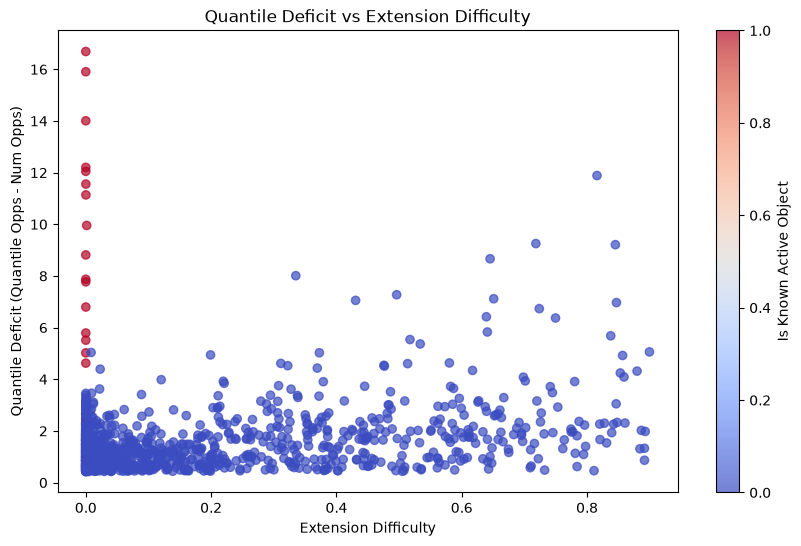

In [35]:
# plot DeltaQ vs extension difficulty, RED is known active object, BLUE is not so listed in the known active json
tempout3 = combined_rankings[combined_rankings["DeltaQ"]>0]

plt.figure(figsize=(10,6))
plt.scatter(tempout3["extension_difficulty"], tempout3["DeltaQ"], c=tempout3["Known / Strong Suspect"], cmap='coolwarm', alpha=0.7)
plt.colorbar(label='Is Known Active Object')
plt.xlabel('Extension Difficulty')
plt.ylabel('Quantile Deficit (Quantile Opps - Num Opps)')
plt.title('Quantile Deficit vs Extension Difficulty')
plt.show()

# Ranking Candidates, Starting with Asteroid Orbits
All predictions here are out-of-fold predictions, that is each prediction is made using training data that excludes itself.
This is possible because AutoGluon uses cross validation and we are using the predict_proba_oof method for data in the training dataset.

## First starting with an overall list of single-opposition objects
After the initial nicely-filtered list, we will also have several lists here which show the "fringe" objects where number of nights or extension_difficulty presents some skepticism for the likelihood of being a real object that is indeed recoverable (yet hasn't been)

In [36]:
# Overall Single-Opposition List, broken out further below by orbital class
# You should still pay attention to extension_difficulty as anything above 0.01 means there are
# mitigating factors that make it more likely to be very difficult to recover in the ITF and/or a mislinkage
extension_difficulty_threshold = 0.15

cols_to_show = ["Num_obs", "extension_difficulty", "quantile_Opps", "n_detectable", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms", "exp_Num_opps" ]
tempout = final[(final["Arc_length"]>7)
      &(final["Num_opps"]==1)
      &(final["Num_obs"]>7)
      &(final["prob"]>0.9993)
      &(final["a"]>1.1)
      &((final["extension_difficulty"].between(0,extension_difficulty_threshold))|(final["nights_total"].isna()))
      &(final["Orbital_period"]<20)]
tempout = tempout[cols_to_show]
tempout.sort_values("prob", ascending=False).head(30)

,Num_obs,extension_difficulty,quantile_Opps,n_detectable,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,
2025 HV38,48,0.000002,17.689064,20.270840,18.0,0.999992,MPO988024,51,8,2.484172,0.047542,7.24007,15.42,2.366069,2.602275,3.463847,0.84,20.975428
2015 BC566,52,0.000003,9.813442,10.664938,11.0,0.999992,MPO771428,39,5,3.06321,0.036617,11.68986,16.33,2.951045,3.175376,3.200295,0.42,13.470255
2001 BV70,32,0.000164,12.138252,10.715999,8.0,0.999992,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,16.176399
2007 VB146,13,0.001466,10.955434,10.168521,4.0,0.999991,MPO130330,16,10,2.752892,0.113703,3.49271,16.94,2.439879,3.065905,3.332674,0.38,14.760114
2008 BJ22,53,0.000014,16.906303,16.381821,13.0,0.999991,MPO732621,83,4,3.073201,0.042397,11.51245,15.20,2.942906,3.203495,3.197832,0.67,20.702135
2025 VZ8,50,0.000003,8.771757,11.248911,15.0,0.999991,MPO988040,43,6,2.620616,0.086127,12.10031,16.76,2.39491,2.846323,3.368118,0.65,12.467668
2019 OE31,32,0.000071,13.203197,11.548095,10.0,0.999989,E2024-JA9,137,3,4.381322,0.100152,5.22115,14.64,3.942522,4.820122,3.006031,0.65,17.074659
2021 AY8,24,0.000009,8.871577,8.035199,7.0,0.999989,E2024-S20,101,4,2.722797,0.057054,5.00731,17.52,2.567449,2.878144,3.349841,0.85,12.557765
2018 BJ11,46,0.000013,6.512388,6.477298,13.0,0.999987,MPO750185,107,5,4.200594,0.225616,3.43068,15.55,3.252873,5.148315,2.986205,0.47,10.684333


In [37]:
# Sort by DeltaQ instead of prob
extension_difficulty_threshold = 0.002000

cols_to_show = ["DeltaQ", "Num_obs", "extension_difficulty", "quantile_Opps", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(((final["Arc_length"])>7)|final["Arc_length"].isna())
      &final["a"].between(1.15,20)
      &final["extension_difficulty"].between(0,extension_difficulty_threshold)]

tempout = tempout.sort_values("DeltaQ", ascending=False)[cols_to_show]
tempout.head(30)

,DeltaQ,Num_obs,extension_difficulty,quantile_Opps,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,,
2025 HV38,16.689064,48,0.000002,17.689064,18.0,0.999992,MPO988024,51,8,2.484172,0.047542,7.24007,15.42,2.366069,2.602275,3.463847,0.84,0.999992,20.975428
2008 BJ22,15.906303,53,0.000014,16.906303,13.0,0.999991,MPO732621,83,4,3.073201,0.042397,11.51245,15.20,2.942906,3.203495,3.197832,0.67,0.999991,20.702135
2008 GO98,14.007002,1549,0.000028,21.007002,NaN,0.999992,MPO969452,<NA>,0,3.971173,0.278727,15.55983,12.91,2.864301,5.078044,2.92673,0.88,0.999992,24.473412
2019 OE31,12.203197,32,0.000071,13.203197,10.0,0.999989,E2024-JA9,137,3,4.381322,0.100152,5.22115,14.64,3.942522,4.820122,3.006031,0.65,0.999989,17.074659
2003 BM80,12.049309,222,0.000028,19.049309,NaN,0.999992,MPO984040,<NA>,0,4.234372,0.187904,5.81319,13.62,3.438718,5.030026,2.991756,1.16,0.999992,22.279791
2010 RH69,11.556589,31,0.000139,14.556589,11.0,0.999992,MPO619842,<NA>,5,4.532396,0.056559,11.54822,13.95,4.276048,4.788743,2.97391,0.96,0.999992,18.576057
2001 BV70,11.138252,32,0.000164,12.138252,8.0,0.999992,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,0.999992,16.176399
2007 VB146,9.955434,13,0.001466,10.955434,4.0,0.999991,MPO130330,16,10,2.752892,0.113703,3.49271,16.94,2.439879,3.065905,3.332674,0.38,0.999991,14.760114
2015 BC566,8.813442,52,0.000003,9.813442,11.0,0.999992,MPO771428,39,5,3.06321,0.036617,11.68986,16.33,2.951045,3.175376,3.200295,0.42,0.999992,13.470255


In [38]:
# NEW WOW tight ext diff
extension_difficulty_threshold = 0.000500

cols_to_show = ["DeltaQ", "Num_obs", "extension_difficulty", "quantile_Opps", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(((final["Arc_length"])>7)|final["Arc_length"].isna())
      &final["a"].between(1.05,20)
      &final["extension_difficulty"].between(0,extension_difficulty_threshold)]

tempout = tempout.sort_values("DeltaQ", ascending=False)[cols_to_show]
tempout.head(30)

,DeltaQ,Num_obs,extension_difficulty,quantile_Opps,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,,
2025 HV38,16.689064,48,0.000002,17.689064,18.0,0.999992,MPO988024,51,8,2.484172,0.047542,7.24007,15.42,2.366069,2.602275,3.463847,0.84,0.999992,20.975428
2008 BJ22,15.906303,53,0.000014,16.906303,13.0,0.999991,MPO732621,83,4,3.073201,0.042397,11.51245,15.20,2.942906,3.203495,3.197832,0.67,0.999991,20.702135
2008 GO98,14.007002,1549,0.000028,21.007002,NaN,0.999992,MPO969452,<NA>,0,3.971173,0.278727,15.55983,12.91,2.864301,5.078044,2.92673,0.88,0.999992,24.473412
2019 OE31,12.203197,32,0.000071,13.203197,10.0,0.999989,E2024-JA9,137,3,4.381322,0.100152,5.22115,14.64,3.942522,4.820122,3.006031,0.65,0.999989,17.074659
2003 BM80,12.049309,222,0.000028,19.049309,NaN,0.999992,MPO984040,<NA>,0,4.234372,0.187904,5.81319,13.62,3.438718,5.030026,2.991756,1.16,0.999992,22.279791
2010 RH69,11.556589,31,0.000139,14.556589,11.0,0.999992,MPO619842,<NA>,5,4.532396,0.056559,11.54822,13.95,4.276048,4.788743,2.97391,0.96,0.999992,18.576057
2001 BV70,11.138252,32,0.000164,12.138252,8.0,0.999992,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,0.999992,16.176399
2015 BC566,8.813442,52,0.000003,9.813442,11.0,0.999992,MPO771428,39,5,3.06321,0.036617,11.68986,16.33,2.951045,3.175376,3.200295,0.42,0.999992,13.470255
2021 AY8,7.871577,24,0.000009,8.871577,7.0,0.999989,E2024-S20,101,4,2.722797,0.057054,5.00731,17.52,2.567449,2.878144,3.349841,0.85,0.999989,12.557765


In [39]:
# WOW sort by EXT DIFF
extension_difficulty_threshold = 0.000500

cols_to_show = ["DeltaQ", "Num_obs", "extension_difficulty", "quantile_Opps", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(((final["Arc_length"])>7)|final["Arc_length"].isna())
      &final["a"].between(1.05,20)
      &final["DeltaQ"].between(3.5,1000)]

tempout = tempout.sort_values("extension_difficulty", ascending=True)[cols_to_show]
tempout.head(30)

,DeltaQ,Num_obs,extension_difficulty,quantile_Opps,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,,
2025 HV38,16.689064,48,0.000002,17.689064,18.0,0.999992,MPO988024,51,8,2.484172,0.047542,7.24007,15.42,2.366069,2.602275,3.463847,0.84,0.999992,20.975428
2015 BC566,8.813442,52,0.000003,9.813442,11.0,0.999992,MPO771428,39,5,3.06321,0.036617,11.68986,16.33,2.951045,3.175376,3.200295,0.42,0.999992,13.470255
2025 VZ8,7.771757,50,0.000003,8.771757,15.0,0.999991,MPO988040,43,6,2.620616,0.086127,12.10031,16.76,2.39491,2.846323,3.368118,0.65,0.999991,12.467668
2021 AY8,7.871577,24,0.000009,8.871577,7.0,0.999989,E2024-S20,101,4,2.722797,0.057054,5.00731,17.52,2.567449,2.878144,3.349841,0.85,0.999989,12.557765
2018 BJ11,5.512388,46,0.000013,6.512388,13.0,0.999987,MPO750185,107,5,4.200594,0.225616,3.43068,15.55,3.252873,5.148315,2.986205,0.47,0.999987,10.684333
2008 BJ22,15.906303,53,0.000014,16.906303,13.0,0.999991,MPO732621,83,4,3.073201,0.042397,11.51245,15.20,2.942906,3.203495,3.197832,0.67,0.999991,20.702135
2017 QN84,5.022078,213,0.000014,9.022078,64.0,0.999990,MPO907046,<NA>,0,3.769087,0.343374,12.07147,14.97,2.474881,5.063294,2.943831,1.13,0.999990,12.612292
2008 GO98,14.007002,1549,0.000028,21.007002,NaN,0.999992,MPO969452,<NA>,0,3.971173,0.278727,15.55983,12.91,2.864301,5.078044,2.92673,0.88,0.999992,24.473412
2008 SA152,4.123707,558,0.000028,15.123707,NaN,0.999995,MPO968829,<NA>,0,2.70414,0.160357,11.77485,15.55,2.270512,3.137769,3.317322,0.8,0.999995,18.413410


In [40]:
# WOW sort by EXT DIFF U != 9 (avoiding really uncertain orbits)
extension_difficulty_threshold = 0.000500

cols_to_show = ["DeltaQ", "Num_obs", "extension_difficulty", "quantile_Opps", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(((final["Arc_length"])>7)|final["Arc_length"].isna())
      &final["a"].between(1.05,20)
      &(final["U"]!=9)
      &final["DeltaQ"].between(3.6,1000)
      &(final["DeltaQ"]>0.4*final["quantile_Opps"])
      ]

tempout = tempout.sort_values("extension_difficulty", ascending=True)[cols_to_show]
tempout.head(30)

,DeltaQ,Num_obs,extension_difficulty,quantile_Opps,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,,
2025 HV38,16.689064,48,0.000002,17.689064,18.0,0.999992,MPO988024,51,8,2.484172,0.047542,7.24007,15.42,2.366069,2.602275,3.463847,0.84,0.999992,20.975428
2025 VZ8,7.771757,50,0.000003,8.771757,15.0,0.999991,MPO988040,43,6,2.620616,0.086127,12.10031,16.76,2.39491,2.846323,3.368118,0.65,0.999991,12.467668
2015 BC566,8.813442,52,0.000003,9.813442,11.0,0.999992,MPO771428,39,5,3.06321,0.036617,11.68986,16.33,2.951045,3.175376,3.200295,0.42,0.999992,13.470255
2021 AY8,7.871577,24,0.000009,8.871577,7.0,0.999989,E2024-S20,101,4,2.722797,0.057054,5.00731,17.52,2.567449,2.878144,3.349841,0.85,0.999989,12.557765
2018 BJ11,5.512388,46,0.000013,6.512388,13.0,0.999987,MPO750185,107,5,4.200594,0.225616,3.43068,15.55,3.252873,5.148315,2.986205,0.47,0.999987,10.684333
2017 QN84,5.022078,213,0.000014,9.022078,64.0,0.999990,MPO907046,<NA>,0,3.769087,0.343374,12.07147,14.97,2.474881,5.063294,2.943831,1.13,0.999990,12.612292
2008 BJ22,15.906303,53,0.000014,16.906303,13.0,0.999991,MPO732621,83,4,3.073201,0.042397,11.51245,15.20,2.942906,3.203495,3.197832,0.67,0.999991,20.702135
2003 BM80,12.049309,222,0.000028,19.049309,NaN,0.999992,MPO984040,<NA>,0,4.234372,0.187904,5.81319,13.62,3.438718,5.030026,2.991756,1.16,0.999992,22.279791
2008 GO98,14.007002,1549,0.000028,21.007002,NaN,0.999992,MPO969452,<NA>,0,3.971173,0.278727,15.55983,12.91,2.864301,5.078044,2.92673,0.88,0.999992,24.473412


In [41]:
# WOW Comets
extension_difficulty_threshold = 0.0100

cols_to_show = ["DeltaQ", "Num_obs", "extension_difficulty", "Num_opps", "quantile_Opps", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(((final["Arc_length"])>7)|final["Arc_length"].isna())
      &final["a"].between(1.05,20)
      &~final["a"].between(4.9,5.5)
      &(final["TJ"]<3.03)
      &(final["Num_opps"]<=13)
      &final["prob"].between(0.85,1000)
      &final["DeltaQ"].between(2.8,1000)]

tempout = tempout.sort_values("extension_difficulty", ascending=True)[cols_to_show]
tempout.head(30)

,DeltaQ,Num_obs,extension_difficulty,Num_opps,quantile_Opps,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,,,
2018 BJ11,5.512388,46,0.000013,1,6.512388,13.0,0.999987,MPO750185,107,5,4.200594,0.225616,3.43068,15.55,3.252873,5.148315,2.986205,0.47,0.999987,10.684333
2017 QN84,5.022078,213,0.000014,4,9.022078,64.0,0.999990,MPO907046,<NA>,0,3.769087,0.343374,12.07147,14.97,2.474881,5.063294,2.943831,1.13,0.999990,12.612292
2008 GO98,14.007002,1549,0.000028,7,21.007002,NaN,0.999992,MPO969452,<NA>,0,3.971173,0.278727,15.55983,12.91,2.864301,5.078044,2.92673,0.88,0.999992,24.473412
2003 BM80,12.049309,222,0.000028,7,19.049309,NaN,0.999992,MPO984040,<NA>,0,4.234372,0.187904,5.81319,13.62,3.438718,5.030026,2.991756,1.16,0.999992,22.279791
2000 EJ37,3.230863,1682,0.000028,11,14.230863,NaN,0.999988,MPO983854,<NA>,0,4.617423,0.705543,10.09302,13.71,1.359633,7.875214,2.441353,0.54,0.999988,19.441231
2008 YB3,2.917625,533,0.000036,9,11.917625,NaN,0.999920,E2024-C06,<NA>,1,11.590737,0.439749,105.16413,9.46,6.493725,16.687748,-0.252411,0.59,0.999920,20.031359
2019 OE31,12.203197,32,0.000071,1,13.203197,10.0,0.999989,E2024-JA9,137,3,4.381322,0.100152,5.22115,14.64,3.942522,4.820122,3.006031,0.65,0.999989,17.074659
2010 RH69,11.556589,31,0.000139,3,14.556589,11.0,0.999992,MPO619842,<NA>,5,4.532396,0.056559,11.54822,13.95,4.276048,4.788743,2.97391,0.96,0.999992,18.576057
2001 BV70,11.138252,32,0.000164,1,12.138252,8.0,0.999992,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,0.999992,16.176399


In [42]:
# NEW Idea v_mag_avg - NOT PART OF THE PAPER AS THIS IS EXPERIMENTAL
cols_to_show = ["v_mag_avg", "v_mag_min", "Num_obs", "extension_difficulty", "DeltaQ", "quantile_Opps", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(((final["Arc_length"])>7)|final["Arc_length"].isna())
      &final["a"].between(1.05,20)
    #   &(final["U"]!=9)
      &(final["extension_difficulty"].between(0,0.65))
      &(final["prob"]>.999)
      &( (final["v_mag_avg"]-final["v_mag_min"])<3)
      &final["DeltaQ"].between(3,1000)]

tempout = tempout.sort_values("v_mag_avg", ascending=True)[cols_to_show]
tempout.head(30)

,v_mag_avg,v_mag_min,Num_obs,extension_difficulty,DeltaQ,quantile_Opps,nights_total,prob,Ref,Arc_length,...,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,,,,
2001 BV70,18.343478,16.90,32,0.000164,11.138252,12.138252,8.0,0.999992,MPO 13809,50,...,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,0.999992,16.176399
2017 QN84,19.164199,17.03,213,0.000014,5.022078,9.022078,64.0,0.999990,MPO907046,<NA>,...,3.769087,0.343374,12.07147,14.97,2.474881,5.063294,2.943831,1.13,0.999990,12.612292
2008 BJ22,19.590000,18.90,53,0.000014,15.906303,16.906303,13.0,0.999991,MPO732621,83,...,3.073201,0.042397,11.51245,15.20,2.942906,3.203495,3.197832,0.67,0.999991,20.702135
2002 CW116,19.802174,19.00,27,0.000046,4.624349,5.624349,7.0,0.999945,E2024-D99,88,...,2.690282,0.231232,8.13852,17.52,2.068204,3.312361,3.319074,0.53,0.999945,9.304622
2006 QX142,19.975000,19.80,13,0.009194,3.461029,4.461029,4.0,0.999377,MPO960587,14,...,2.73949,0.250119,0.86834,17.95,2.054292,3.424688,3.304206,0.56,0.999377,7.931071
2010 RH69,20.177576,18.10,31,0.000139,11.556589,14.556589,11.0,0.999992,MPO619842,<NA>,...,4.532396,0.056559,11.54822,13.95,4.276048,4.788743,2.97391,0.96,0.999992,18.576057
2006 JE41,20.243750,19.70,16,0.639332,6.419292,7.419292,3.0,0.999986,MPO102346,14,...,2.267336,0.191752,2.08041,18.42,1.83257,2.702102,3.589674,0.35,0.999986,11.355620
2009 FP8,20.246154,19.30,22,0.000038,6.796064,7.796064,7.0,0.999987,MPO166339,35,...,3.014208,0.177985,4.62744,16.94,2.477724,3.550692,3.219233,0.46,0.999987,11.882175
2007 VB146,20.371429,20.10,13,0.001466,9.955434,10.955434,4.0,0.999991,MPO130330,16,...,2.752892,0.113703,3.49271,16.94,2.439879,3.065905,3.332674,0.38,0.999991,14.760114


In [43]:
# 2013 QC85 and 2013 DZ10 search - WORKING!
cols_to_show = ["v_mag_avg", "v_mag_min", "Num_obs", "extension_difficulty", "quantile_Opps", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(((final["Arc_length"])>=3)|final["Arc_length"].isna())
      &final["a"].between(1.05,20)
      &final["Num_opps"].between(1,1)
    #   &(final["U"]!=9)
      &(final["extension_difficulty"].between(0,0.9))
      &(final["prob"]>.99)
      &( (final["v_mag_avg"]-final["v_mag_min"])<2.5)

      # There are some bad old objects we need to filter starting with 1992
      &(pd.to_numeric(final.index.str[0:4], errors="coerce")>1992)

      &final["DeltaQ"].between(1,1000)
      ]
tempout = tempout.sort_values("v_mag_avg", ascending=True)[cols_to_show]
tempout.head(30)

,v_mag_avg,v_mag_min,Num_obs,extension_difficulty,quantile_Opps,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,,,
2001 BV70,18.343478,16.90,32,0.000164,12.138252,8.0,0.999992,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,0.999992,16.176399
2005 UG561,18.766667,18.30,6,0.312579,3.980049,3.0,0.997136,MPO976062,12,7,2.960485,0.386145,7.32373,17.29,1.81731,4.103661,3.137753,0.16,0.997136,7.295449
2000 KQ4,18.907143,18.50,14,0.011264,3.527555,4.0,0.992070,MPO 1653,9,10,2.238668,0.380371,11.95771,18.51,1.387144,3.090191,3.511105,0.52,0.992070,6.529140
2005 WW206,19.133333,19.00,12,0.691581,20.170534,3.0,0.999993,MPO 98017,3,10,3.233998,0.086857,22.0817,13.82,2.953103,3.514893,3.06445,0.53,0.999993,23.371777
2005 XO113,19.133333,19.10,12,0.790415,7.936124,4.0,0.999991,MPO 98031,3,10,3.103499,0.306931,21.37122,16.04,2.15094,4.056058,3.045499,0.3,0.999991,12.118067
2000 SP366,19.483333,19.20,12,0.837749,6.682778,3.0,0.999986,MPO 13781,8,10,2.544182,0.260274,4.23977,17.80,1.881998,3.206365,3.391709,0.48,0.999986,11.070526
2008 BJ22,19.590000,18.90,53,0.000014,16.906303,13.0,0.999991,MPO732621,83,4,3.073201,0.042397,11.51245,15.20,2.942906,3.203495,3.197832,0.67,0.999991,20.702135
2005 BT,19.611538,18.70,29,0.497164,3.832765,3.0,0.993133,MPO 74483,3,10,2.516875,0.408932,12.27461,18.61,1.487644,3.546105,3.307625,0.59,0.993133,6.142251
2002 CW116,19.802174,19.00,27,0.000046,5.624349,7.0,0.999945,E2024-D99,88,5,2.690282,0.231232,8.13852,17.52,2.068204,3.312361,3.319074,0.53,0.999945,9.304622


In [44]:
# 2013 DZ10 like search - U not 9, 0.997
cols_to_show = ["v_mag_avg", "v_mag_min", "Num_obs", "extension_difficulty", "quantile_Opps", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(((final["Arc_length"])>=3)|final["Arc_length"].isna())
      &final["a"].between(1.05,20)
      &final["Num_opps"].between(1,1)
    #   &(final["U"]!=9)
      &(final["extension_difficulty"].between(0,0.6))
      &(final["prob"]>.9998)
      &( (final["v_mag_avg"]-final["v_mag_min"])<2.5)
      &(final["U"]!=9)

      # There are some bad old objects we need to filter starting with 1992
      &(pd.to_numeric(final.index.str[0:4], errors="coerce")>1992)

      &final["DeltaQ"].between(1,1000)
      ]
tempout = tempout.sort_values("v_mag_avg", ascending=True)[cols_to_show]
tempout.head(30)

,v_mag_avg,v_mag_min,Num_obs,extension_difficulty,quantile_Opps,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,,,
2001 BV70,18.343478,16.90,32,0.000164,12.138252,8.0,0.999992,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,0.999992,16.176399
2008 BJ22,19.590000,18.90,53,0.000014,16.906303,13.0,0.999991,MPO732621,83,4,3.073201,0.042397,11.51245,15.20,2.942906,3.203495,3.197832,0.67,0.999991,20.702135
2002 CW116,19.802174,19.00,27,0.000046,5.624349,7.0,0.999945,E2024-D99,88,5,2.690282,0.231232,8.13852,17.52,2.068204,3.312361,3.319074,0.53,0.999945,9.304622
2009 FP8,20.246154,19.30,22,0.000038,7.796064,7.0,0.999987,MPO166339,35,10,3.014208,0.177985,4.62744,16.94,2.477724,3.550692,3.219233,0.46,0.999987,11.882175
2007 VB146,20.371429,20.10,13,0.001466,10.955434,4.0,0.999991,MPO130330,16,10,2.752892,0.113703,3.49271,16.94,2.439879,3.065905,3.332674,0.38,0.999991,14.760114
2001 UY217,20.376923,19.90,13,0.008505,6.037077,4.0,0.999962,MPO285656,9,10,2.107378,0.184219,2.67958,19.09,1.719158,2.495598,3.718634,0.5,0.999962,9.802517
2015 BC566,20.539583,20.03,52,0.000003,9.813442,11.0,0.999992,MPO771428,39,5,3.06321,0.036617,11.68986,16.33,2.951045,3.175376,3.200295,0.42,0.999992,13.470255
2019 OE31,20.711875,19.98,32,0.000071,13.203197,10.0,0.999989,E2024-JA9,137,3,4.381322,0.100152,5.22115,14.64,3.942522,4.820122,3.006031,0.65,0.999989,17.074659
2025 HV38,20.739111,18.93,48,0.000002,17.689064,18.0,0.999992,MPO988024,51,8,2.484172,0.047542,7.24007,15.42,2.366069,2.602275,3.463847,0.84,0.999992,20.975428


In [45]:
# NEW Idea v_mag_avg Comets - NOT PART OF THE PAPER AS THIS IS EXPERIMENTAL
cols_to_show = ["DeltaQ", "v_mag_avg", "Num_obs", "extension_difficulty", "quantile_Opps", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(((final["Arc_length"])>7)|final["Arc_length"].isna())
      &final["a"].between(1.05,8)
      &final["q"].between(1.05,20)
      &final["TJ"].between(2,3.03)
      &final["Num_opps"].between(0,1.5)
      &final["prob"].between(0.75,1)
      &(final["extension_difficulty"].between(0,0.6))
      &( (final["v_mag_avg"]-final["v_mag_min"])<3)
      &final["DeltaQ"].between(0.9,1000)]

tempout = tempout.sort_values("v_mag_avg", ascending=True)[cols_to_show]
tempout.head(30)

,DeltaQ,v_mag_avg,Num_obs,extension_difficulty,quantile_Opps,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,,,
2001 BV70,11.138252,18.343478,32,0.000164,12.138252,8.0,0.999992,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,0.999992,16.176399
2007 TD441,2.571346,19.808333,7,0.383450,3.571346,3.0,0.995105,E2026-MB0,9,9,3.419821,0.427441,12.57225,16.33,1.958051,4.881591,2.952142,0.39,0.995105,7.531785
2012 XK149,1.122724,20.420000,14,0.000040,2.122724,4.0,0.952719,MPO987382,36,6,3.950724,0.32834,4.00114,16.64,2.653545,5.247903,2.959117,0.77,0.952719,6.148684
2015 VY223,1.327237,20.616667,12,0.041401,2.327237,3.0,0.953192,MPO870086,13,8,3.209892,0.109866,26.70514,16.71,2.857234,3.56255,3.015764,0.53,0.953192,6.122886
2019 OE31,12.203197,20.711875,32,0.000071,13.203197,10.0,0.999989,E2024-JA9,137,3,4.381322,0.100152,5.22115,14.64,3.942522,4.820122,3.006031,0.65,0.999989,17.074659
2013 UD65,1.22888,20.960000,15,0.317080,2.228880,3.0,0.942508,MPO869667,62,8,3.720047,0.523748,4.69887,17.57,1.771681,5.668413,2.834426,0.53,0.942508,5.523969
2008 WF41,0.945788,21.100000,9,0.561318,1.945788,3.0,0.941862,MPO149159,14,10,3.961463,0.212165,3.95649,16.70,3.120978,4.801949,3.014751,0.18,0.941862,5.742368
2015 CP7,1.078113,21.360667,18,0.000352,2.078113,5.0,0.946938,E2026-KA3,20,7,3.961451,0.218084,6.10547,16.65,3.097522,4.825381,3.006881,0.95,0.946938,6.090296
2024 FW19,0.971326,21.386923,49,0.000047,1.971326,13.0,0.947278,E2024-P43,135,3,3.19066,0.228058,26.34242,17.07,2.463004,3.918315,2.997261,0.81,0.947278,5.355237


In [46]:
# Show specific objects in a table
cols_to_show = ["DeltaQ", "Num_obs", "extension_difficulty", "quantile_Opps", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[final.index.isin(["2024 XE22", "2008 VK110", '2008 SM113','2014 SG99','2022 GD19','2013 PM21','2012 TV407','2010 TR241','2012 XK149','2020 RX133'])]

tempout = tempout.sort_values("DeltaQ", ascending=False)[cols_to_show]
tempout.head(30)

,DeltaQ,Num_obs,extension_difficulty,quantile_Opps,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,,
2010 TR241,5.791911,12,0.000045,6.791911,4.0,0.999978,E2026-GD6,36,5,3.05075,0.099885,12.41983,16.97,2.746025,3.355474,3.193626,0.8,0.999978,10.649594
2024 XE22,2.284489,36,0.000034,3.284489,10.0,0.992018,MPO988022,22,4,5.86508,0.22663,27.16003,14.26,4.535879,7.194282,2.727256,0.81,0.992018,6.429345
2014 SG99,1.995767,12,0.385201,2.995767,4.0,0.988710,MPO311513,9,10,3.020191,0.073212,1.177,17.65,2.799078,3.241305,3.242102,0.12,0.988710,6.855797
2012 TV407,1.235962,12,0.023259,2.235962,4.0,0.950641,MPO869515,13,9,3.053034,0.142964,0.11741,17.82,2.616559,3.48951,3.220502,0.82,0.950641,5.961221
2012 XK149,1.122724,14,0.000040,2.122724,4.0,0.952719,MPO987382,36,6,3.950724,0.32834,4.00114,16.64,2.653545,5.247903,2.959117,0.77,0.952719,6.148684
2008 VK110,-0.419241,24,0.000100,2.580759,9.0,0.967416,MPO791125,<NA>,4,7.167172,0.380986,7.38588,14.06,4.436583,9.897761,2.878252,0.96,0.967416,6.831461
2013 PM21,-1.321712,20,0.243336,1.678288,4.0,0.921380,E2026-Q12,<NA>,2,2.592541,0.180362,15.05986,17.90,2.124944,3.060138,3.347843,0.6,0.921380,5.635843
2022 GD19,-1.646916,35,0.000095,3.353084,6.0,0.994587,E2026-P69,<NA>,0,2.265382,0.075098,5.96352,18.86,2.095256,2.435509,3.60559,0.39,0.994587,7.442897
2020 RX133,-4.187146,34,0.000015,1.812854,9.0,0.935686,MPO733796,<NA>,0,5.049634,0.104891,1.82058,15.54,4.519975,5.579293,2.988817,0.34,0.935686,5.689007


In [47]:
# Consider carefully these 4-nighters even if extension_difficulty is above extension_difficulty_threshold as they may be real objects that are just difficult to recover in the ITF
# ... but possible with the right ITF algorithm. Note: we've seen situations where our ITF algorithm doesn't find it but someone else's does and vice versa.
cols_to_show = ["Num_obs", "extension_difficulty", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(final["Arc_length"]>7)
      &(final["Num_obs"]>7)
      &(final["prob"]>0.9988)
      &(final["a"]>1.1)
      &((final["extension_difficulty"]>extension_difficulty_threshold) & (final["nights_total"]>3) )
      # &(final["H_diff_abs_max"]<0.6)
      &(final["Orbital_period"]<20)]
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,extension_difficulty,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,
2025 NV385,8,0.199083,4.0,0.999984,E2026-L57,8,9,2.368791,0.183429,7.47077,18.04,1.934285,2.803297,3.511802,0.05,0.999984,9.890302


In [48]:
# These objects with higher extension_difficulty may be real objects (but more likely super short arcs or mislinkages),
# but in practice we've found it unrewarding to invest too much manual effort chasing them. They should still be examined
# if one has the bandwidth and/or can use pipelines / citizen science to examine them at scale.
cols_to_show = ["Num_obs", "extension_difficulty", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(final["Arc_length"]>7)
      &(final["Num_obs"]>7)
      &(final["prob"]>0.9999)
      &((final["extension_difficulty"]>extension_difficulty_threshold) & (final["extension_difficulty"]<0.6))
      # &(final["H_diff_abs_max"]<0.6)
      &(final["Orbital_period"]<20)]
tempout = tempout[cols_to_show].sort_values("extension_difficulty", ascending=True)
tempout.head(20)

,Num_obs,extension_difficulty,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,
2025 NV385,8,0.199083,4.0,0.999984,E2026-L57,8,9,2.368791,0.183429,7.47077,18.04,1.934285,2.803297,3.511802,0.05,0.999984,9.890302
2021 FV45,8,0.311257,3.0,0.999920,E2021-N02,30,5,2.392089,0.194944,8.8241,18.00,1.925765,2.858414,3.489426,0.28,0.999920,9.268368
2002 FU44,10,0.335138,NaN,0.999963,E2026-R81,20,9,5.29866,0.155289,1.88403,14.38,4.475838,6.121482,2.974687,0.73,0.999963,13.306461
2015 PF156,9,0.372744,3.0,0.999990,MPO839241,27,7,2.812708,0.479662,12.58886,16.56,1.463558,4.161859,3.109095,1.02,0.999990,10.573647
2020 BB167,11,0.430607,3.0,0.999990,MPO871285,8,9,2.785411,0.308728,3.17919,16.99,1.925476,3.645345,3.257669,0.96,0.999990,12.779360
2021 VU103,10,0.476479,3.0,0.999980,MPO840342,8,9,2.496464,0.365259,12.15146,17.29,1.584609,3.408319,3.344902,0.59,0.999980,9.682303
2023 WZ43,9,0.496154,3.0,0.999992,MPO793415,26,7,2.312829,0.29015,8.06358,17.78,1.641763,2.983896,3.51309,0.44,0.999992,11.721279
2024 WQ82,10,0.517441,3.0,0.999978,MPO886961,13,9,2.469075,0.108741,1.18404,18.31,2.200586,2.737564,3.476554,0.87,0.999978,10.666221
2025 NJ491,10,0.533778,3.0,0.999968,E2026-L19,9,9,2.470514,0.048263,1.13196,18.34,2.351279,2.589749,3.482316,0.16,0.999968,11.260266


## List by Orbital Class
### Asteroidal

In [49]:
# Single-opposition asteroid-only list (T_J > 3.05), sorted by prob
cols_to_show = ["Num_obs","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" , "extension_difficulty"]
tempout = final[(final["Arc_length"]>11)
      &(final["Num_obs"]>7)
      &(final["prob"]>0.98)
      &(final["TJ"]>3.05)
      &(final["extension_difficulty"]<0.07)
      # &(final["H_diff_abs_max"]<0.6)
      &(final["Orbital_period"]<20)]
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps,extension_difficulty
Principal_desig,,,,,,,,,,,,,,,
2025 HV38,48,MPO988024,51,8,2.484172,0.047542,7.24007,15.42,2.366069,2.602275,3.463847,0.84,0.999992,20.975428,0.000002
2008 BJ22,53,MPO732621,83,4,3.073201,0.042397,11.51245,15.20,2.942906,3.203495,3.197832,0.67,0.999991,20.702135,0.000014
2007 VB146,13,MPO130330,16,10,2.752892,0.113703,3.49271,16.94,2.439879,3.065905,3.332674,0.38,0.999991,14.760114,0.001466
2015 BC566,52,MPO771428,39,5,3.06321,0.036617,11.68986,16.33,2.951045,3.175376,3.200295,0.42,0.999992,13.470255,0.000003
2021 AY8,24,E2024-S20,101,4,2.722797,0.057054,5.00731,17.52,2.567449,2.878144,3.349841,0.85,0.999989,12.557765,0.000009
2025 VZ8,50,MPO988040,43,6,2.620616,0.086127,12.10031,16.76,2.39491,2.846323,3.368118,0.65,0.999991,12.467668,0.000003
2009 FP8,22,MPO166339,35,10,3.014208,0.177985,4.62744,16.94,2.477724,3.550692,3.219233,0.46,0.999987,11.882175,0.000038
2010 TR241,12,E2026-GD6,36,5,3.05075,0.099885,12.41983,16.97,2.746025,3.355474,3.193626,0.8,0.999978,10.649594,0.000045
2002 CW116,27,E2024-D99,88,5,2.690282,0.231232,8.13852,17.52,2.068204,3.312361,3.319074,0.53,0.999945,9.304622,0.000046


In [50]:
# Single-opposition asteroid-only TIGHTER with more than 16 observations
cols_to_show = ["Num_obs","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" , "extension_difficulty"]
tempout = final[(final["Arc_length"]>11)
      &(final["Num_obs"]>16)
      &(final["prob"]>0.98)
      &(final["TJ"]>3.05)
      &(final["extension_difficulty"]<0.07)
      # &(final["H_diff_abs_max"]<0.6)
      &(final["Orbital_period"]<20)]
tempout = tempout[cols_to_show]
tempout.head(10)

,Num_obs,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps,extension_difficulty
Principal_desig,,,,,,,,,,,,,,,
2025 HV38,48,MPO988024,51,8,2.484172,0.047542,7.24007,15.42,2.366069,2.602275,3.463847,0.84,0.999992,20.975428,0.000002
2008 BJ22,53,MPO732621,83,4,3.073201,0.042397,11.51245,15.20,2.942906,3.203495,3.197832,0.67,0.999991,20.702135,0.000014
2015 BC566,52,MPO771428,39,5,3.06321,0.036617,11.68986,16.33,2.951045,3.175376,3.200295,0.42,0.999992,13.470255,0.000003
2021 AY8,24,E2024-S20,101,4,2.722797,0.057054,5.00731,17.52,2.567449,2.878144,3.349841,0.85,0.999989,12.557765,0.000009
2025 VZ8,50,MPO988040,43,6,2.620616,0.086127,12.10031,16.76,2.39491,2.846323,3.368118,0.65,0.999991,12.467668,0.000003
2009 FP8,22,MPO166339,35,10,3.014208,0.177985,4.62744,16.94,2.477724,3.550692,3.219233,0.46,0.999987,11.882175,0.000038
2002 CW116,27,E2024-D99,88,5,2.690282,0.231232,8.13852,17.52,2.068204,3.312361,3.319074,0.53,0.999945,9.304622,0.000046
2021 PM141,18,MPO680902,37,4,3.166015,0.091143,9.59919,17.10,2.877454,3.454576,3.17527,0.08,0.997779,8.910940,0.000033
2026 OZ8,17,E2026-RB7,47,4,2.790664,0.059627,4.33037,17.77,2.624266,2.957062,3.322378,0.82,0.997008,8.417981,0.000171


In [51]:
# 2025 and 2026 objects
cols_to_show = ["Num_obs","extension_difficulty","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps"]
tempout = final[(final["Arc_length"]>9)
      &(final["Num_obs"]>6)
      &(final["prob"]>0.997)
      &(pd.to_numeric(final.index.str[0:4], errors="coerce")>=2025)
      # &(final["H_diff_abs_max"]<0.6)
      &(final["Orbital_period"]<20)]
tempout = tempout[cols_to_show]
tempout.to_clipboard()
tempout.head(10)

,Num_obs,extension_difficulty,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,
2025 HV38,48,0.000002,MPO988024,51,8,2.484172,0.047542,7.24007,15.42,2.366069,2.602275,3.463847,0.84,0.999992,20.975428
2025 VZ8,50,0.000003,MPO988040,43,6,2.620616,0.086127,12.10031,16.76,2.39491,2.846323,3.368118,0.65,0.999991,12.467668
2025 QB175,8,0.022956,E2026-HE1,11,9,2.734152,0.170471,0.38037,18.07,2.268057,3.200248,3.331534,0.11,0.999844,9.318005
2025 NX446,8,0.120379,E2026-L10,10,9,2.164547,0.098677,2.35596,18.95,1.950957,2.378137,3.686346,0.25,0.999752,9.037461
2025 SM161,11,0.219491,E2026-R81,10,8,2.569781,0.032843,6.64557,18.11,2.485383,2.654179,3.420055,0.53,0.998984,9.305457
2025 SC79,21,0.000067,MPO962929,10,8,0.495705,0.450047,16.78278,18.83,0.272614,0.718795,11.023965,0.46,0.999857,10.727447
2026 PJ16,13,0.022028,E2026-RB7,28,7,2.166404,0.075825,1.16218,19.23,2.002136,2.330672,3.68824,0.74,0.999241,9.069344
2026 OZ8,17,0.000171,E2026-RB7,47,4,2.790664,0.059627,4.33037,17.77,2.624266,2.957062,3.322378,0.82,0.997008,8.417981
2025 QJ215,9,0.210586,E2026-MA7,11,9,3.074298,0.179275,1.54523,17.61,2.523153,3.625443,3.204324,0.15,0.997706,7.516877


In [52]:
# Same thing, but different sort
# Single-opposition asteroid-only list (T_J > 3.05), sorted by Expeected Number of Oppositions
cols_to_show = ["Num_obs","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" , "extension_difficulty"]
tempout = final[(final["Arc_length"]>11)
      &(final["Num_obs"]>7)
      &(final["prob"]>0.99)
      &(final["TJ"]>3.05)
      &(final["extension_difficulty"]<0.15)
      # &(final["H_diff_abs_max"]<0.6)
      &(final["Orbital_period"]<20)].sort_values("exp_Num_opps", ascending=False)
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps,extension_difficulty
Principal_desig,,,,,,,,,,,,,,,
2025 HV38,48,MPO988024,51,8,2.484172,0.047542,7.24007,15.42,2.366069,2.602275,3.463847,0.84,0.999992,20.975428,0.000002
2008 BJ22,53,MPO732621,83,4,3.073201,0.042397,11.51245,15.20,2.942906,3.203495,3.197832,0.67,0.999991,20.702135,0.000014
2007 VB146,13,MPO130330,16,10,2.752892,0.113703,3.49271,16.94,2.439879,3.065905,3.332674,0.38,0.999991,14.760114,0.001466
2015 BC566,52,MPO771428,39,5,3.06321,0.036617,11.68986,16.33,2.951045,3.175376,3.200295,0.42,0.999992,13.470255,0.000003
2021 AY8,24,E2024-S20,101,4,2.722797,0.057054,5.00731,17.52,2.567449,2.878144,3.349841,0.85,0.999989,12.557765,0.000009
2025 VZ8,50,MPO988040,43,6,2.620616,0.086127,12.10031,16.76,2.39491,2.846323,3.368118,0.65,0.999991,12.467668,0.000003
2009 FP8,22,MPO166339,35,10,3.014208,0.177985,4.62744,16.94,2.477724,3.550692,3.219233,0.46,0.999987,11.882175,0.000038
2010 TR241,12,E2026-GD6,36,5,3.05075,0.099885,12.41983,16.97,2.746025,3.355474,3.193626,0.8,0.999978,10.649594,0.000045
2002 CW116,27,E2024-D99,88,5,2.690282,0.231232,8.13852,17.52,2.068204,3.312361,3.319074,0.53,0.999945,9.304622,0.000046


### On to Comet Orbits

In [53]:
# NEW multiopp 3+ Comets
cols_to_show = ["Num_opps", "exp_Num_opps", "poisson_cdf", "DeltaQ", "quantile_Opps", "extension_difficulty", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(final["Num_opps"]>=3)
      &(final["prob"]>.99)
      &(final["q"]>1.1)
      &(final["TJ"]<3.01)
      &(final["a"].between(1.1,10))
      &~(final["a"].between(4.9,5.5))
      &(final["DeltaQ"]>-3)
      &((final["extension_difficulty"].between(0,0.25)))
      &(final["Orbital_period"]<20)]
tempout = tempout[cols_to_show].sort_values("poisson_cdf", ascending=True)
tempout.head(20)

,Num_opps,exp_Num_opps,poisson_cdf,DeltaQ,quantile_Opps,extension_difficulty,nights_total,prob,Ref,Arc_length,...,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,,,,
2010 RH69,3,18.576057,0.000004,11.556589,14.556589,0.000139,11.0,0.999992,MPO619842,<NA>,...,4.532396,0.056559,11.54822,13.95,4.276048,4.788743,2.97391,0.96,0.999992,18.576057
2008 GO98,7,24.473412,0.000020,14.007002,21.007002,0.000028,NaN,0.999992,MPO969452,<NA>,...,3.971173,0.278727,15.55983,12.91,2.864301,5.078044,2.92673,0.88,0.999992,24.473412
2003 BM80,7,22.279791,0.000101,12.049309,19.049309,0.000028,NaN,0.999992,MPO984040,<NA>,...,4.234372,0.187904,5.81319,13.62,3.438718,5.030026,2.991756,1.16,0.999992,22.279791
2017 QN84,4,12.612292,0.003088,5.022078,9.022078,0.000014,64.0,0.999990,MPO907046,<NA>,...,3.769087,0.343374,12.07147,14.97,2.474881,5.063294,2.943831,1.13,0.999990,12.612292
2006 VY13,4,10.095953,0.019833,1.683567,5.683567,0.000028,NaN,0.999984,MPO985184,<NA>,...,2.918237,0.614308,4.67638,17.22,1.125542,4.710932,2.960881,0.44,0.999984,10.095953
2000 EJ37,11,19.441231,0.024368,3.230863,14.230863,0.000028,NaN,0.999988,MPO983854,<NA>,...,4.617423,0.705543,10.09302,13.71,1.359633,7.875214,2.441353,0.54,0.999988,19.441231
2019 SH281,3,7.314760,0.049311,0.487974,3.487974,0.000242,9.0,0.996826,MPO987796,<NA>,...,3.324618,0.589611,25.4655,16.38,1.364388,5.284847,2.730809,0.9,0.996826,7.314760
2013 PN2,4,8.328532,0.066167,0.528467,4.528467,0.000028,NaN,0.999290,MPO702843,<NA>,...,3.165968,0.407894,29.55928,16.22,1.87459,4.457347,2.88245,0.56,0.999290,8.328532
2014 JF120,4,8.255358,0.069387,0.434686,4.434686,0.000035,9.0,0.998793,MPO918701,<NA>,...,3.203359,0.178658,29.45323,16.41,2.631052,3.775666,2.968727,0.27,0.998793,8.255358


In [54]:
# Comets with stricter TJ
cols_to_show = ["Num_obs", "extension_difficulty", "nights_total", "quantile_Opps", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","exp_Num_opps" ]
tempout = final[(final["Arc_length"]>7)
      &(~final["a"].between(5,5.4))
      &(final["Num_obs"]>7)
      &(final["prob"]>0.9)
      &(final["TJ"]<3.01)
      &((final["extension_difficulty"].between(0,0.15))|(final["nights_total"].isna()))
      &(final["Orbital_period"]<20)]
tempout = tempout[cols_to_show].sort_values("prob", ascending=False)
tempout.head(20)

,Num_obs,extension_difficulty,nights_total,quantile_Opps,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,
2001 BV70,32,0.000164,8.0,12.138252,0.999992,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,16.176399
2019 OE31,32,0.000071,10.0,13.203197,0.999989,E2024-JA9,137,3,4.381322,0.100152,5.22115,14.64,3.942522,4.820122,3.006031,0.65,17.074659
2018 BJ11,46,0.000013,13.0,6.512388,0.999987,MPO750185,107,5,4.200594,0.225616,3.43068,15.55,3.252873,5.148315,2.986205,0.47,10.684333
2024 XE22,36,0.000034,10.0,3.284489,0.992018,MPO988022,22,4,5.86508,0.22663,27.16003,14.26,4.535879,7.194282,2.727256,0.81,6.429345
2023 XN31,11,0.029693,3.0,2.789900,0.973860,MPO793527,27,7,4.00731,0.279352,6.37824,16.25,2.887861,5.126759,2.97328,0.45,5.984847
2017 QU213,9,0.072273,3.0,2.630448,0.971902,MPO870608,25,6,3.611848,0.451168,3.42888,17.88,1.982297,5.241398,2.924996,1.1,5.752972
2025 PW116,8,0.058863,4.0,2.786676,0.969683,E2026-QA1,13,9,3.356826,0.49383,2.5804,18.02,1.699123,5.014529,2.945462,0.21,5.893607
2012 XK149,14,0.000040,4.0,2.122724,0.952719,MPO987382,36,6,3.950724,0.32834,4.00114,16.64,2.653545,5.247903,2.959117,0.77,6.148684
2014 JE52,9,0.123121,3.0,2.248945,0.948902,MPO900148,12,9,3.922256,0.188208,48.68913,15.89,3.184057,4.660455,2.452377,1.11,5.925194


In [55]:
# Single-opp Comets strict TJ and extension difficulty
cols_to_show = ["Num_obs", "extension_difficulty", "nights_total", "quantile_Opps", "TJ", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","rms","prob", "exp_Num_opps" ]
tempout = final[(final["Arc_length"]>7)
      &(~final["a"].between(5,5.4))
      &(final["q"]>0.9)
      &(final["Num_obs"]>7)
      &(final["prob"]>0.9)
      &(final["TJ"]<3.01)
      &((final["extension_difficulty"].between(0,0.05))|(final["nights_total"].isna()))
      &(final["Orbital_period"]<20)]
tempout = tempout[cols_to_show].sort_values("quantile_Opps", ascending=False)
tempout.head(20)

,Num_obs,extension_difficulty,nights_total,quantile_Opps,TJ,prob,Ref,Arc_length,U,a,e,i,H,q,Q,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,,
2019 OE31,32,0.000071,10.0,13.203197,3.006031,0.999989,E2024-JA9,137,3,4.381322,0.100152,5.22115,14.64,3.942522,4.820122,0.65,0.999989,17.074659
2001 BV70,32,0.000164,8.0,12.138252,2.947403,0.999992,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,0.58,0.999992,16.176399
2018 BJ11,46,0.000013,13.0,6.512388,2.986205,0.999987,MPO750185,107,5,4.200594,0.225616,3.43068,15.55,3.252873,5.148315,0.47,0.999987,10.684333
2024 XE22,36,0.000034,10.0,3.284489,2.727256,0.992018,MPO988022,22,4,5.86508,0.22663,27.16003,14.26,4.535879,7.194282,0.81,0.992018,6.429345
2023 XN31,11,0.029693,3.0,2.789900,2.97328,0.973860,MPO793527,27,7,4.00731,0.279352,6.37824,16.25,2.887861,5.126759,0.45,0.973860,5.984847
2012 XK149,14,0.000040,4.0,2.122724,2.959117,0.952719,MPO987382,36,6,3.950724,0.32834,4.00114,16.64,2.653545,5.247903,0.77,0.952719,6.148684
2015 CP7,18,0.000352,5.0,2.078113,3.006881,0.946938,E2026-KA3,20,7,3.961451,0.218084,6.10547,16.65,3.097522,4.825381,0.95,0.946938,6.090296
2024 FW19,49,0.000047,13.0,1.971326,2.997261,0.947278,E2024-P43,135,3,3.19066,0.228058,26.34242,17.07,2.463004,3.918315,0.81,0.947278,5.355237
2009 DP2,79,0.000028,19.0,1.861522,2.609808,0.901645,E2026-N01,22,2,6.646579,0.424883,26.76899,14.17,3.822559,9.470598,0.59,0.901645,4.936909


In [56]:
# NEW Comets a > 4 (for whatever reason, these are more likely true and you can set a lower probability threshold--even as low as 0.8--and still get relevant flags of objects worth checking)
cols_to_show = ["Num_obs", "extension_difficulty", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(final["Arc_length"]>7)
      &(~final["a"].between(5,5.4))
      &(final["a"]>4)&(final["a"]<10)
      &(final["Num_obs"]>7)
      &(final["prob"]>0.7)
      &(final["TJ"]<3.05)
      &((final["extension_difficulty"].between(0,0.15))|(final["nights_total"].isna()))
      &(final["Orbital_period"]<20)]
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,extension_difficulty,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,
2019 OE31,32,0.000071,10.0,0.999989,E2024-JA9,137,3,4.381322,0.100152,5.22115,14.64,3.942522,4.820122,3.006031,0.65,0.999989,17.074659
2018 BJ11,46,0.000013,13.0,0.999987,MPO750185,107,5,4.200594,0.225616,3.43068,15.55,3.252873,5.148315,2.986205,0.47,0.999987,10.684333
2024 XE22,36,0.000034,10.0,0.992018,MPO988022,22,4,5.86508,0.22663,27.16003,14.26,4.535879,7.194282,2.727256,0.81,0.992018,6.429345
2023 XN31,11,0.029693,3.0,0.973860,MPO793527,27,7,4.00731,0.279352,6.37824,16.25,2.887861,5.126759,2.97328,0.45,0.973860,5.984847
2009 DP2,79,0.000028,19.0,0.901645,E2026-N01,22,2,6.646579,0.424883,26.76899,14.17,3.822559,9.470598,2.609808,0.59,0.901645,4.936909
2006 RP118,52,0.000173,5.0,0.911512,MPO133492,8,10,4.302008,0.594638,1.30052,17.21,1.74387,6.860146,2.671206,0.04,0.911512,4.901829
2025 QH62,13,0.098374,4.0,0.737733,MPO950566,23,9,4.300769,0.636857,13.95521,16.85,1.561796,7.039742,2.570317,0.24,0.737733,4.507287
2021 PM66,26,0.000190,7.0,0.781710,MPO660755,60,4,4.566931,0.350355,3.80822,16.70,2.966885,6.166978,2.890403,0.92,0.781710,4.138713
2022 WC21,26,0.000017,8.0,0.700024,MPO727351,69,6,5.767714,0.654776,1.27619,17.06,1.991154,9.544273,2.493263,0.48,0.700024,4.216325


In [57]:
# Single-opp Periodic Comets (excluding Trojans)
cols_to_show = ["Num_obs","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" , "extension_difficulty"]
tempout = final[(~final["a"].between(5,5.4))
      &(final["Orbital_period"]<20)
      &(final["Arc_length"]>14)
      &(final["Num_obs"]>7)
      &(final["TJ"]<3.01)
      &(final["prob"]>0.8)
      &(final["Tp"]>2450000)
      &(final["a"].between(1.1,10))
      &(final["extension_difficulty"]<0.15)]
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps,extension_difficulty
Principal_desig,,,,,,,,,,,,,,,
2019 OE31,32,E2024-JA9,137,3,4.381322,0.100152,5.22115,14.64,3.942522,4.820122,3.006031,0.65,0.999989,17.074659,0.000071
2001 BV70,32,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,0.999992,16.176399,0.000164
2018 BJ11,46,MPO750185,107,5,4.200594,0.225616,3.43068,15.55,3.252873,5.148315,2.986205,0.47,0.999987,10.684333,0.000013
2024 XE22,36,MPO988022,22,4,5.86508,0.22663,27.16003,14.26,4.535879,7.194282,2.727256,0.81,0.992018,6.429345,0.000034
2023 XN31,11,MPO793527,27,7,4.00731,0.279352,6.37824,16.25,2.887861,5.126759,2.97328,0.45,0.973860,5.984847,0.029693
2017 QU213,9,MPO870608,25,6,3.611848,0.451168,3.42888,17.88,1.982297,5.241398,2.924996,1.1,0.971902,5.752972,0.072273
2012 XK149,14,MPO987382,36,6,3.950724,0.32834,4.00114,16.64,2.653545,5.247903,2.959117,0.77,0.952719,6.148684,0.000040
2015 CP7,18,E2026-KA3,20,7,3.961451,0.218084,6.10547,16.65,3.097522,4.825381,3.006881,0.95,0.946938,6.090296,0.000352
2024 FW19,49,E2024-P43,135,3,3.19066,0.228058,26.34242,17.07,2.463004,3.918315,2.997261,0.81,0.947278,5.355237,0.000047


In [58]:
# Comets a > 4 (somehow this list tends to be better at turning up real comets? there are lots with a<4 which are just insufficiently linked/observed)
cols_to_show = ["Num_obs","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" , "extension_difficulty"]
tempout = final[(~final["a"].between(5,5.4))
      &(final["Orbital_period"]<20)
      &(final["Arc_length"]>14)
      &(final["a"]>4)
      &(final["Num_obs"]>7)
      &(final["TJ"]<3.05)
      &(final["prob"]>0.7)
      &(final["Tp"]>2450000)
      &(final["extension_difficulty"]<0.15)]
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps,extension_difficulty
Principal_desig,,,,,,,,,,,,,,,
2019 OE31,32,E2024-JA9,137,3,4.381322,0.100152,5.22115,14.64,3.942522,4.820122,3.006031,0.65,0.999989,17.074659,0.000071
2018 BJ11,46,MPO750185,107,5,4.200594,0.225616,3.43068,15.55,3.252873,5.148315,2.986205,0.47,0.999987,10.684333,0.000013
2024 XE22,36,MPO988022,22,4,5.86508,0.22663,27.16003,14.26,4.535879,7.194282,2.727256,0.81,0.992018,6.429345,0.000034
2023 XN31,11,MPO793527,27,7,4.00731,0.279352,6.37824,16.25,2.887861,5.126759,2.97328,0.45,0.973860,5.984847,0.029693
2009 DP2,79,E2026-N01,22,2,6.646579,0.424883,26.76899,14.17,3.822559,9.470598,2.609808,0.59,0.901645,4.936909,0.000028
2025 QH62,13,MPO950566,23,9,4.300769,0.636857,13.95521,16.85,1.561796,7.039742,2.570317,0.24,0.737733,4.507287,0.098374
2021 PM66,26,MPO660755,60,4,4.566931,0.350355,3.80822,16.70,2.966885,6.166978,2.890403,0.92,0.781710,4.138713,0.000190
2022 WC21,26,MPO727351,69,6,5.767714,0.654776,1.27619,17.06,1.991154,9.544273,2.493263,0.48,0.700024,4.216325,0.000017
2021 GN33,23,MPO641177,33,4,4.001564,0.161138,26.51959,16.16,3.356759,4.64637,2.849137,0.73,0.739409,4.316687,0.000009


In [59]:
# Comets a < 4 (somehow a lot of these are just insufficiently linked/observed and a bit of archival work shows them to be simple ACOs)
cols_to_show = ["Num_obs","Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" , "extension_difficulty"]
tempout = final[(~final["a"].between(5,5.4))
      &(final["Orbital_period"]<20)
      &(final["Arc_length"]>14)
      &(final["a"]<4)
      &(final["Num_obs"]>7)
      &(final["TJ"]<3.02)
      &(final["prob"]>0.7)
      &(final["Tp"]>2450000)
      &(final["extension_difficulty"]<0.15)]
tempout = tempout[cols_to_show]
tempout.head(20)

,Num_obs,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps,extension_difficulty
Principal_desig,,,,,,,,,,,,,,,
2001 BV70,32,MPO 13809,50,10,3.593632,0.425907,4.33032,15.14,2.063079,5.124185,2.947403,0.58,0.999992,16.176399,0.000164
2017 QU213,9,MPO870608,25,6,3.611848,0.451168,3.42888,17.88,1.982297,5.241398,2.924996,1.1,0.971902,5.752972,0.072273
2025 WG24,14,MPO964090,19,6,3.955588,0.217739,2.61671,16.75,3.094303,4.816873,3.015588,0.87,0.953331,5.803842,0.000267
2012 XK149,14,MPO987382,36,6,3.950724,0.32834,4.00114,16.64,2.653545,5.247903,2.959117,0.77,0.952719,6.148684,0.000040
2015 CP7,18,E2026-KA3,20,7,3.961451,0.218084,6.10547,16.65,3.097522,4.825381,3.006881,0.95,0.946938,6.090296,0.000352
2024 FW19,49,E2024-P43,135,3,3.19066,0.228058,26.34242,17.07,2.463004,3.918315,2.997261,0.81,0.947278,5.355237,0.000047
2019 TJ58,20,MPO600179,53,4,3.975285,0.215432,4.30846,16.70,3.118882,4.831689,3.011148,0.13,0.902089,5.482050,0.000165
2023 WD46,10,MPO811404,26,7,3.418711,0.226378,41.89156,16.25,2.644791,4.192632,2.69742,0.41,0.914261,5.404238,0.059435
2021 FE48,14,MPO646208,51,4,3.189196,0.109959,28.28348,16.80,2.838515,3.539877,3.001973,0.16,0.896682,5.402806,0.000445


In [60]:
# JFC / Centaur List (see https://arxiv.org/pdf/2512.11204)
cols_to_show = ["poisson_cdf", "extension_difficulty","Num_opps","Ref","Arc_length","U","a","e","i","H","q","TJ","prob", "exp_Num_opps"]
tempout = final[((final["Arc_length"]>11)| (final["Arc_length"].isna()))
      &(final["Num_obs"]>7)
      &(final["extension_difficulty"]<0.5)
      &(final["a"].between(4.05,5.05))
      &(final["TJ"]<3.05)
      &(final["prob"]>0.8)
      &(final["Orbital_period"]<20)].sort_values("poisson_cdf", ascending=True)
tempout = tempout[cols_to_show]
tempout.head(10)

,poisson_cdf,extension_difficulty,Num_opps,Ref,Arc_length,U,a,e,i,H,q,TJ,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,
2019 OE31,1.044393e-07,0.000071,1,E2024-JA9,137,3,4.381322,0.100152,5.22115,14.64,3.942522,3.006031,0.999989,17.074659
2010 RH69,4.026698e-06,0.000139,3,MPO619842,<NA>,5,4.532396,0.056559,11.54822,13.95,4.276048,2.97391,0.999992,18.576057
2018 BJ11,6.225119e-05,0.000013,1,MPO750185,107,5,4.200594,0.225616,3.43068,15.55,3.252873,2.986205,0.999987,10.684333
2003 BM80,1.007258e-04,0.000028,7,MPO984040,<NA>,0,4.234372,0.187904,5.81319,13.62,3.438718,2.991756,0.999992,22.279791
2000 EJ37,2.436792e-02,0.000028,11,MPO983854,<NA>,0,4.617423,0.705543,10.09302,13.71,1.359633,2.441353,0.999988,19.441231
2023 QP121,9.383068e-02,0.000012,6,MPO973353,<NA>,0,5.049485,0.03575,7.83338,14.82,4.868965,2.981043,0.999695,10.392897
2010 ES189,1.183342e-01,0.000044,3,MPO659990,<NA>,0,4.184707,0.348309,31.50244,15.60,2.727136,2.676863,0.944195,6.076758
2000 XO8,1.313110e-01,0.000023,3,E2026-Q40,<NA>,0,4.236962,0.653018,12.21784,16.40,1.470148,2.563898,0.939712,5.922750
2003 XN43,1.313621e-01,0.000063,4,MPO644189,<NA>,2,4.064148,0.245053,16.387,15.60,3.068217,2.924325,0.995315,7.235898


### Trojans and Multi-opp active asteroid lists, but they've never turned up anything
It's not surprising that the Trojans haven't turned up much (small population). It'a also not surprising that multi-opp active asteroids are a bust, probably because most MBA active asteroids are one-time or impulsive (not recurrent)

In [61]:
# NEO Comets?? (never found one before but maybe it is possible)
cols_to_show = ["Num_obs", "extension_difficulty", "quantile_Opps", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms", "exp_Num_opps" ]
tempout = final[(final["Arc_length"]>7)
      &(final["Num_opps"]==1)
      &(final["Num_obs"]>7)
      &(final["TJ"]<3.02)
      &(final["q"]<1.3)
      &(final["Orbital_period"]<20)]
tempout = tempout[cols_to_show]
tempout.sort_values("prob", ascending=False).head(30)

,Num_obs,extension_difficulty,quantile_Opps,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,
2025 YK9,194,0.000001,1.186098,35.0,0.843268,E2026-M87,110,4,3.062463,0.708215,15.0282,18.79,0.893582,5.231344,2.745191,0.77,5.406041
2016 RR20,25,0.000024,1.028580,5.0,0.688612,MPO740737,37,9,2.620409,0.726398,36.38459,18.06,0.71695,4.523868,2.770881,0.73,4.186468
2013 RD21,39,0.000002,1.117620,12.0,0.683386,MPO781693,34,8,3.176233,0.737167,29.77222,18.36,0.83482,5.517645,2.554627,0.47,4.145489
2001 VB,53,0.000100,1.060138,6.0,0.682952,MPO 21144,8,3,2.331223,0.897126,8.35561,18.40,0.239822,4.422624,2.817018,0.73,4.607185
2018 LB1,133,0.000006,0.976817,35.0,0.597577,E2023-XO2,216,4,2.781513,0.6459,1.1783,20.11,0.984935,4.578092,2.986699,0.78,3.408845
2023 QR6,29,0.004237,0.979415,9.0,0.557856,MPO782830,53,7,2.281558,0.75992,38.6091,18.27,0.547756,4.01536,2.95317,0.54,3.634599
2026 JL4,66,0.000084,1.056488,NaN,0.505684,E2026-M34,39,7,2.375519,0.495117,57.9235,18.95,1.199359,3.551679,2.81378,0.64,3.595276
2022 RX3,90,0.000010,0.997914,20.0,0.500171,E2024-BE1,219,4,2.630199,0.640136,70.55951,17.70,0.946514,4.313885,2.341779,0.63,3.586069
2026 CW4,313,0.000001,0.966584,43.0,0.479742,E2026-QB8,180,3,2.970657,0.715127,15.95053,19.77,0.846259,5.095056,2.767133,0.61,3.435023


In [62]:
# Trojans (never had a true ActivitySCOPE alert for these... they always so far turn out to be recoverable in the archives)
cols_to_show = ["Num_obs", "extension_difficulty", "nights_total", "prob", "Ref","Arc_length","U","a","e","i","H","q","Q","TJ","rms","prob", "exp_Num_opps" ]
tempout = final[(final["Arc_length"]>7)
      &(final["a"].between(5,5.4))
      &(final["Num_obs"]>7)
      &(final["prob"]>0.98)
      &((final["extension_difficulty"].between(0,0.15))|(final["nights_total"].isna()))
      &(final["Orbital_period"]<20)]
tempout = tempout[cols_to_show]
tempout.head(5)

,Num_obs,extension_difficulty,nights_total,prob,Ref,Arc_length,U,a,e,i,H,q,Q,TJ,rms,prob,exp_Num_opps
Principal_desig,,,,,,,,,,,,,,,,,
2002 FU44,10,0.335138,NaN,0.999963,E2026-R81,20,9,5.29866,0.155289,1.88403,14.38,4.475838,6.121482,2.974687,0.73,0.999963,13.306461
2026 FR24,18,0.061284,3.0,0.995878,E2026-J03,11,8,5.263097,0.043631,7.48668,14.81,5.033462,5.492733,2.981052,0.04,0.995878,8.684473
2024 YL57,11,0.001547,4.0,0.989718,MPO900801,65,5,5.185091,0.097791,5.6402,15.14,4.678035,5.692147,2.98082,1.08,0.989718,7.246632
2024 QE16,17,0.000037,5.0,0.990802,MPO872107,38,5,5.10584,0.030488,19.45394,14.93,4.950175,5.261504,2.886289,1.17,0.990802,7.115711
2026 ER17,36,0.000617,5.0,0.986384,E2026-H99,13,9,5.180101,0.068834,4.36061,15.23,4.823536,5.536667,2.989518,0.07,0.986384,7.181832


# Import the Comet Orbit File from MPC
Beyond this point we aren't looking for new discoveries but mostly retrospectively looking at older discoveries.
We import the comet file only to get orbital elements etc. for prior discoveries so we can rank them for the paper (unfortunately didn't save the asteroidal MPCORB elements from prior to cometary confirmation)

In [63]:
discoveries_in_comet_file = ["P/2025 UX109 (Ye)","P/2023 JN16 (Lemmon)","P/2022 BV9 (Lemmon)","P/2017 FL36 (PANSTARRS)","489P/Denning"]

# Objects moved to Comet Orbits (Archived Version, stored in repository since there are occasionally truncation issues live)
comet = pd.read_json("allcometels.json.gz",compression='gzip')

comet = comet[comet["Orbit_type"].isin(["P","D","A"])]
# comet = comet[comet["Designation_and_name"].str[0].isin(["P","D"])]


comet["a"] = comet["Perihelion_dist"] / (1 - comet["e"])
comet["Orbital_period"] = np.sqrt(comet["a"]**3)


def calc_jd(year, month, day):
    y = year.copy()
    m = month.copy()
    mask = m <= 2
    y[mask] -= 1
    m[mask] += 12
    A = np.floor(y / 100)
    B = 2 - A + np.floor(A / 4)
    B[y < 1582] = 0
    B[(y == 1582) & (month < 10)] = 0
    B[(y == 1582) & (month == 10) & (day <= 4)] = 0
    return np.floor(365.25 * (y + 4716)) + np.floor(30.6001 * (m + 1)) + day + B - 1524.5

comet["Tp"] = calc_jd(comet["Year_of_perihelion"], comet["Month_of_perihelion"], comet["Day_of_perihelion"])
comet["Epoch"] = comet["Tp"]
comet["M"] = 0.0


# Only pulling in the magnitude data for comets from find_orb as the MPC H values in the comet file are not H assuming inert
comet_mags_fo = pd.read_fwf("./comet_orbits/comet_els_fo.txt", widths=[8, 5, 1000], names=["Packed", "Mag", "Discard"])

/Users/petervw/mambaforge/envs/actscope-16/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [64]:
comet["fullpacked"] = comet["Orbit_type"] + comet["Provisional_packed_desig"]
comet.drop(columns=["H"], inplace=True, errors="ignore") # Wrong H! This is the comet H and not the inert asteroidal H
cometmerge = comet.merge(comet_mags_fo, left_on="fullpacked", right_on="Packed", how="left")

cometmerge.loc[cometmerge["Designation_and_name"] == "489P/Denning", "Mag"] = 15.35
cometmerge.loc[cometmerge["Designation_and_name"] == "P/2025 UX109 (Ye)", "Mag"] = 15.00

cometmerge["H"] = cometmerge["Mag"]
cometmerge = utils.feature_engineering(cometmerge)

cometmerge["exp_Num_opps"] = predictor_reg.predict(cometmerge) + 1
cometmerge["quantile_Opps"] = predictor_quant.predict(cometmerge)[0.006] + 1

cometmerge["prob"] = predictor.predict_proba(cometmerge)[1]
cometmerge["Num_opps"] = pd.NA # no data for this in the comet file
# but for each of the discoveries_in_comet_file set Num_opps to 1 so they show up in the single-opp comet list
cometmerge.loc[cometmerge["Designation_and_name"].isin(discoveries_in_comet_file), "Num_opps"] = 1

# Poisson_cdf business
num_opps = pd.to_numeric(cometmerge["Num_opps"], errors="coerce")
exp_num_opps = pd.to_numeric(cometmerge["exp_Num_opps"], errors="coerce")
result = poisson.cdf(num_opps - 1, exp_num_opps - 1)
cometmerge["poisson_cdf"] = pd.Series(result, index=cometmerge.index, dtype="Float64")

cometmerge['DeltaQ'] = cometmerge["quantile_Opps"]-cometmerge["Num_opps"]
cometmerge.rename(columns={"Perihelion_dist":"q","Aphelion_dist":"Q"},inplace=True)

/Users/petervw/GitHub/ActivitySCOPE/activityscope_utils.py:2029: RuntimeWarning: invalid value encountered in sqrt
  sqrt_1pe, sqrt_1me = col(np.sqrt(1.0 + e)), col(np.sqrt(1.0 - e))


In [65]:
# This is the 100+ rows referenced in the paper which ActivitySCOPE would have found as likely comets if not found morphologically
cometout = cometmerge[(cometmerge["prob"] > 0.97) & ~(cometmerge["H"].isna())].sort_values("prob", ascending=False)
cometout[["Designation_and_name","q","a","e","i","H",'prob','poisson_cdf','DeltaQ']]#[cometout["fullpacked"].str[:4]=="PK23"]

,Designation_and_name,q,a,e,i,H,prob,poisson_cdf,DeltaQ
258,P/2023 JN16 (Lemmon),2.300095,2.697442,0.147305,3.7013,15.73,0.999993,0.0,15.197319
141,P/2015 X6 (PANSTARRS),2.273303,2.752633,0.174135,4.5666,16.07,0.999992,<NA>,<NA>
201,P/2020 K9 (Lemmon-PANSTARRS),2.861752,4.208057,0.319935,23.1858,14.80,0.999992,<NA>,<NA>
94,P/2012 K3 (Gibbs),2.101062,3.633383,0.421734,13.1785,14.31,0.999992,<NA>,<NA>
175,P/2019 A4 (PANSTARRS),2.385479,2.614212,0.087496,13.3069,17.24,0.999992,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...
262,A/2023 R3,1.360259,-5075.593284,1.000268,12.0976,19.91,0.984190,<NA>,<NA>
74,P/2010 J3 (McMillan),2.478878,8.988183,0.724207,13.2243,12.30,0.981095,<NA>,<NA>
283,P/2024 T2 (Rankin),1.972537,6.171719,0.680391,12.9289,15.47,0.980151,<NA>,<NA>
290,P/2025 D2 (PANSTARRS),7.418015,8.708532,0.148190,5.3583,12.50,0.979192,<NA>,<NA>


In [66]:
# ActivitySCOPE discoveries that currently live in the comet file
cometmerge[cometmerge["Designation_and_name"].isin(discoveries_in_comet_file)][["Designation_and_name","a","e","i","H",'prob','poisson_cdf','DeltaQ','exp_Num_opps']]

,Designation_and_name,a,e,i,H,prob,poisson_cdf,DeltaQ,exp_Num_opps
152,P/2017 FL36 (PANSTARRS),2.927577,0.033763,15.6993,16.65,0.999985,0.000155,5.033251,9.768887
241,P/2022 BV9 (Lemmon),4.366555,0.233335,11.9223,13.79,0.999986,0.0,13.738716,18.283724
258,P/2023 JN16 (Lemmon),2.697442,0.147305,3.7013,15.73,0.999993,0.0,15.197319,19.659964
298,P/2025 UX109 (Ye),3.806430,0.324837,3.1809,15.00,0.999990,0.0,12.660398,16.848789
891,489P/Denning,4.421537,0.646954,4.0269,15.35,0.999521,0.000656,3.722456,8.328936


In [67]:
raise Exception("Stop here for now.")

Exception: Stop here for now.

# This is the part for the paper
Less polished code but it can be used to verify parts of the paper

# Survey Completeness Progress

In [68]:
# exclude legacy objects, short arcs, exclude NEOs and Trojans / things past Jupiter
# as we are mostly curious about MBA survey completeness here
sc_pre_subset = final[(final.index < "2027 ") & final["q"].between(1.3,4)
                      & ((final["Arc_length"]>7)|final["Arc_length"].isna())].copy()
sc_pre_subset = sc_pre_subset[~sc_pre_subset.index.str.contains("-")]
# also exclude known actives
sc_pre_subset = sc_pre_subset[~sc_pre_subset["Known / Strong Suspect"]]
# also exclude all single-opp objects
sc_pre_subset = sc_pre_subset[(sc_pre_subset["Num_opps"]>1)]

def get_latest_principal_desig_for_exp_num_opps_range(i):
    subset = sc_pre_subset[(sc_pre_subset["exp_Num_opps"]>=i) & (sc_pre_subset["exp_Num_opps"]<i+1)]
    if len(subset)==0:
        return None
    else:
        return subset.sort_index().index[-1]

# now create a table with two columns: "exp_Num_opps_range" and "latest_principal_desig"
exp_num_opps_ranges = []
latest_principal_desigs = []
for i in range(1,30):
    exp_num_opps_ranges.append(f"{i}-{i+1}")
    latest_principal_desigs.append(get_latest_principal_desig_for_exp_num_opps_range(i))
exp_num_opps_table = pd.DataFrame({"exp_Num_opps_range": exp_num_opps_ranges, "latest_principal_desig": latest_principal_desigs})
exp_num_opps_table

,exp_Num_opps_range,latest_principal_desig
0,1-2,2026 PY7
1,2-3,2026 QW
2,3-4,2026 QL2
3,4-5,2026 QQ3
4,5-6,2026 PX2
5,6-7,2026 PP9
6,7-8,2026 PT3
7,8-9,2026 PJ3
8,9-10,2026 MT8
9,10-11,2025 OX82


In [69]:
# Fetch SBN linkage dates for the multi-opposition population used in this table.
if "initial_linkage_sbn" not in final:
    final["initial_linkage_sbn"] = pd.NaT

_table_desigs = sc_pre_subset.index.astype(str).tolist()
_sbn_linkages = {}
_conn = utils.sbn_connect()
try:
    _cur = _conn.cursor()
    for _lo in range(0, len(_table_desigs), 5000):
        _cur.execute("""
            select unpacked_primary_provisional_designation, created_at
              from public.mpc_orbits
             where unpacked_primary_provisional_designation = any(%s)
        """, (_table_desigs[_lo:_lo + 5000],))
        _sbn_linkages.update(_cur.fetchall())
finally:
    _conn.close()

_linkage_dates = pd.Series(_sbn_linkages, name="initial_linkage_sbn")
final.loc[_linkage_dates.index, "initial_linkage_sbn"] = _linkage_dates
print(f"fetched SBN linkage dates for {len(_linkage_dates):,} of {len(_table_desigs):,} table objects")


fetched SBN linkage dates for 1,317,937 of 1,317,940 table objects


In [70]:
# Refresh the pre-filtered frame with the timestamps fetched above.
sc_pre_subset = sc_pre_subset.drop(columns=["initial_linkage_sbn"], errors="ignore").join(
    final[["initial_linkage_sbn"]], how="left"
)

def get_latest_linkage_by_exp_num_opps_range(i):
    subset = sc_pre_subset[(sc_pre_subset["exp_Num_opps"] >= i)
                           & (sc_pre_subset["exp_Num_opps"] < i + 1)]
    linkage_dates = subset["initial_linkage_sbn"].dropna()
    if linkage_dates.empty:
        return None, pd.NaT
    designation = linkage_dates.idxmax()
    return designation, linkage_dates.loc[designation]

exp_num_opps_ranges = []
latest_principal_desigs = []
latest_linkage_dates = []
for i in range(1, 30):
    designation, linkage_date = get_latest_linkage_by_exp_num_opps_range(i)
    exp_num_opps_ranges.append(f"{i}-{i + 1}")
    latest_principal_desigs.append(designation)
    latest_linkage_dates.append(linkage_date)

exp_num_opps_table = pd.DataFrame({
    "exp_Num_opps_range": exp_num_opps_ranges,
    "latest_principal_desig": latest_principal_desigs,
    "initial_linkage_sbn": latest_linkage_dates,
})
exp_num_opps_table

,exp_Num_opps_range,latest_principal_desig,initial_linkage_sbn
0,1-2,2026 NQ5,2026-09-09 16:35:44.292198
1,2-3,2026 NP5,2026-09-09 16:10:14.008895
2,3-4,2013 NJ84,2026-09-09 17:37:54.821430
3,4-5,2023 TX212,2026-09-09 16:49:30.152849
4,5-6,2017 BX271,2026-09-09 17:39:23.935405
5,6-7,2014 DS214,2026-09-09 15:28:15.847049
6,7-8,2015 HN554,2026-09-09 06:46:09.957796
7,8-9,2026 AJ27,2026-09-09 16:43:22.861770
8,9-10,2025 CU20,2026-08-16 13:27:31.898785
9,10-11,2010 VK228,2026-09-09 10:33:37.505705


In [81]:
# New objects linked within each calendar year, grouped by expected-opposition band.
linkage_years = {
    "count_2024": (pd.Timestamp("2024-01-01"), pd.Timestamp("2025-01-01")),
    "count_2025": (pd.Timestamp("2025-01-01"), pd.Timestamp("2026-01-01")),
    "count_2026": (pd.Timestamp("2026-01-01"), pd.Timestamp("2027-01-01")),
}

# load dual_designation_list.json and exclude them from this
with open("dual_designation_list.json") as f:
    dual_designation_list_without_paren = json.load(f)

# Convert the items in dual_designation_list_without_paren (negative integers) to positive numbers wrapped in paren
# like -1234 becomes string (1234)
dual_designation_list = [f"({-x})" for x in dual_designation_list_without_paren]

sc_pre_subset = sc_pre_subset[~sc_pre_subset["Number"].isin(dual_designation_list)]

In [82]:
new_linkage_counts = pd.DataFrame({"exprange": [f"{i}--{i + 1}" for i in range(1, 30)]})
for column, (year_start, year_end) in linkage_years.items():
    newly_linked = sc_pre_subset[
        (sc_pre_subset["initial_linkage_sbn"] >= year_start)
        & (sc_pre_subset["initial_linkage_sbn"] < year_end)
    ]
    new_linkage_counts[column] = [
        ((newly_linked["exp_Num_opps"] >= i) & (newly_linked["exp_Num_opps"] < i + 1)).sum()
        for i in range(1, 30)
    ]

new_linkage_counts

,exprange,count_2024,count_2025,count_2026
0,1--2,1751,1479,1858
1,2--3,8029,6192,5057
2,3--4,12736,9502,6752
3,4--5,11076,8098,5558
4,5--6,6821,4875,3017
5,6--7,3877,2892,1416
6,7--8,1780,1775,616
7,8--9,842,1421,207
8,9--10,347,936,64
9,10--11,110,470,25


In [86]:
# TeX table for expected-opposition bands E = 7 through 23.
tex_linkage_counts = new_linkage_counts.iloc[4:23].rename(columns={
    "exprange": r"$E$ range",
    "count_2024": "2024",
    "count_2025": "2025",
    "count_2026": "2026",
})
print(tex_linkage_counts.to_latex(index=False, escape=False, column_format="lrrr"))

\begin{tabular}{lrrr}
\toprule
$E$ range & 2024 & 2025 & 2026 \\
\midrule
5--6 & 6821 & 4875 & 3017 \\
6--7 & 3877 & 2892 & 1416 \\
7--8 & 1780 & 1775 & 616 \\
8--9 & 842 & 1421 & 207 \\
9--10 & 347 & 936 & 64 \\
10--11 & 110 & 470 & 25 \\
11--12 & 41 & 152 & 7 \\
12--13 & 11 & 48 & 1 \\
13--14 & 6 & 10 & 0 \\
14--15 & 6 & 0 & 0 \\
15--16 & 3 & 0 & 0 \\
16--17 & 0 & 1 & 0 \\
17--18 & 1 & 0 & 0 \\
18--19 & 0 & 0 & 0 \\
19--20 & 0 & 0 & 0 \\
20--21 & 1 & 0 & 0 \\
21--22 & 0 & 0 & 0 \\
22--23 & 0 & 0 & 0 \\
23--24 & 0 & 0 & 0 \\
\bottomrule
\end{tabular}



In [78]:
# list of E>15 objects linked in 2024-01-01 or later
z = sc_pre_subset[(sc_pre_subset["exp_Num_opps"] > 18) & (sc_pre_subset["initial_linkage_sbn"] >= "2024-01-01")]
z[["exp_Num_opps", "initial_linkage_sbn"]].sort_values(by=["exp_Num_opps", "initial_linkage_sbn"])

,exp_Num_opps,initial_linkage_sbn
Principal_desig,,
2000 HN99,20.590099,2024-10-31 22:20:22.108196


In [79]:
# list of E>15 objects linked in 2024-01-01 or later
z = sc_pre_subset[(sc_pre_subset["exp_Num_opps"] > 12) & (sc_pre_subset["initial_linkage_sbn"] >= "2026-01-01")]
z[["exp_Num_opps", "initial_linkage_sbn"]].sort_values(by=["exp_Num_opps", "initial_linkage_sbn"])

,exp_Num_opps,initial_linkage_sbn
Principal_desig,,
2025 NH378,12.028936,2026-06-04 05:07:06.517951


In [80]:
# list of E>15 objects linked in 2024-01-01 or later
z = sc_pre_subset[(sc_pre_subset["exp_Num_opps"] > 16) & (sc_pre_subset["initial_linkage_sbn"] >= "2025-01-01")]
z[["exp_Num_opps", "initial_linkage_sbn"]].sort_values(by=["exp_Num_opps", "initial_linkage_sbn"])

,exp_Num_opps,initial_linkage_sbn
Principal_desig,,
2002 QK158,16.047867,2025-01-28 09:01:01.580051


# Feature importance

In [ ]:
# reload utils and then redo feat eng
import importlib
importlib.reload(utils)

orb_training = utils.feature_engineering(orb_training.copy())

In [ ]:
data_df_reg = orb_training.dropna(subset=["H"])[mlcols_reg+[
    # 'vis_opp_fluxsum',
    ]].astype(np.float32)
# drop any desired columns
data_df_reg.drop(columns=[], inplace=True)

# Split data_df_reg into training and test sets
train_data_reg = data_df_reg.sample(len(data_df_reg)-150000, random_state=18)
test_data_reg = data_df_reg.drop(train_data_reg.index)

# drop the exp_Num_opps column from both sets as this is intended only for the quantile regression model to reference the output of the main (Poisson-loss) regression model
train_data_reg = train_data_reg.drop(columns=["Shared_Fold","exp_Num_opps"], errors="ignore")
test_data_reg = test_data_reg.drop(columns=["Shared_Fold","exp_Num_opps"], errors="ignore")

In [ ]:
# Regression model training
predictor_reg_feat_imp = TabularPredictor(label="Num_opps_minus_one", eval_metric=utils.POISSON_SCORER, problem_type='regression', path=os.path.join(save_path, datetime.datetime.now().strftime("%Y%m%d_%H%M%S")))
# Note that in some environments we are seeing problems with parallel fitting using Ray, so sequential is safer and yields more consistent results across more machines and more environments.
predictor_reg_feat_imp.fit(train_data_reg, presets="good_quality", hyperparameters=utils.HYPERPARAMETERS_POISSON, num_stack_levels=0, dynamic_stacking=False, ag_args_ensemble={"fold_fitting_strategy": "sequential_local"}, time_limit=220)

predictor_reg_feat_imp.feature_importance(test_data_reg)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.13
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.6.0: Mon Jan 19 22:00:55 PST 2026; root:xnu-11417.140.69.708.3~1/RELEASE_ARM64_T6000
CPU Count:          10
Pytorch Version:    2.9.1
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       6.44 GB / 32.00 GB (20.1%)
Disk Space Avail:   33.49 GB / 926.35 GB (3.6%)
Presets specified: ['good_quality']
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this risk by setting `save_bag_folds=True`.
Beginning Au

[1000]	valid_set's poisson: -12.805	valid_set's mean_poisson_deviance: -0.421043
[1000]	valid_set's poisson: -12.8174	valid_set's mean_poisson_deviance: -0.419806
[1000]	valid_set's poisson: -12.8032	valid_set's mean_poisson_deviance: -0.419296
[1000]	valid_set's poisson: -12.8787	valid_set's mean_poisson_deviance: -0.418253
[1000]	valid_set's poisson: -12.8126	valid_set's mean_poisson_deviance: -0.420189
[1000]	valid_set's poisson: -12.8608	valid_set's mean_poisson_deviance: -0.418679
[1000]	valid_set's poisson: -12.8054	valid_set's mean_poisson_deviance: -0.422835
[1000]	valid_set's poisson: -12.8292	valid_set's mean_poisson_deviance: -0.421324


	-0.4202	 = Validation score   (-mean_poisson_deviance)
	162.15s	 = Training   runtime
	7.11s	 = Validation runtime
Fitting model: XGBoost_BAG_L1 ... Training model for up to 47.86s of the 47.86s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=10, gpus=0)
	-0.4304	 = Validation score   (-mean_poisson_deviance)
	44.21s	 = Training   runtime
	1.16s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ... Training model for up to 218.33s of the 1.41s of remaining time.
	Fitting 1 model on all data | Fitting with cpus=10, gpus=0, mem=0.1/6.3 GB
	Ensemble Weights: {'LightGBM_BAG_L1': 1.0}
	-0.4202	 = Validation score   (-mean_poisson_deviance)
	0.71s	 = Training   runtime
	0.02s	 = Validation runtime
AutoGluon training complete, total runtime = 219.58s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 21442.7 rows/s (152450 batch size)
Automatically performing refit_full as a post-fit operat

,importance,stddev,p_value,n,p99_high,p99_low
vis_orbit_mag_multi,3.260831,0.098467,9.965489e-08,5,3.463575,3.058087
spatial_discoverability_fraction,0.409334,0.005801,4.840528e-09,5,0.421279,0.397389
vis_opp_mean,0.230566,0.012493,1.030363e-06,5,0.256290,0.204843
vis_opp_fluxsum,0.151099,0.004272,7.661210e-08,5,0.159896,0.142303
H,0.060315,0.005033,5.764742e-06,5,0.070678,0.049952
Node,0.052857,0.002971,1.192867e-06,5,0.058974,0.046739
vis_timeavg,0.035808,0.003897,1.656841e-05,5,0.043831,0.027784
vis_q,0.022820,0.002764,2.533347e-05,5,0.028512,0.017129
a,0.014140,0.004390,9.851529e-04,5,0.023180,0.005100
dec_flux_weighted,0.014015,0.002122,6.118145e-05,5,0.018384,0.009645


# Backward SFS

In [ ]:
len(train_data_reg.columns)-1

15

In [ ]:
# do reverse sfs features selection using just xgboost and the train/test sets above
from xgboost import XGBRegressor
from sklearn.feature_selection import SequentialFeatureSelector

# drop all rows from train and test where anything is nan
train_data_reg_sfs = train_data_reg.dropna()
test_data_reg_sfs = test_data_reg.dropna()

sfs = SequentialFeatureSelector(estimator=XGBRegressor(), n_features_to_select=2, direction='forward', cv=5, n_jobs=-1)
sfs.fit(train_data_reg_sfs.drop(columns=["Num_opps_minus_one"]), train_data_reg_sfs["Num_opps_minus_one"])

SequentialFeatureSelector(estimator=XGBRegressor(base_score=None, booster=None,
                                                 callbacks=None,
                                                 colsample_bylevel=None,
                                                 colsample_bynode=None,
                                                 colsample_bytree=None,
                                                 device=None,
                                                 early_stopping_rounds=None,
                                                 enable_categorical=False,
                                                 eval_metric=None,
                                                 feature_types=None,
                                                 feature_weights=None,
                                                 gamma=None, grow_policy=None,
                                                 importance_type=None,
                                                 interaction_constraints=None,
                                                 learning_rate=None,
                                                 max_bin=None,
                                                 max_cat_threshold=None,
                                                 max_cat_to_onehot=None,
                                                 max_delta_step=None,
                                                 max_depth=None,
                                                 max_leaves=None,
                                                 min_child_weight=None,
                                                 missing=nan,
                                                 monotone_constraints=None,
                                                 multi_strategy=None,
                                                 n_estimators=None, n_jobs=None,
                                                 num_parallel_tree=None, ...),
                          n_features_to_select=2, n_jobs=-1)

In [ ]:
sfs.feature_names_in_[sfs.get_support()]

# 'H', 'Node', 'vis_timeavg', 'spatial_discoverability_fraction'

# top 6
# 'Node', 'a', 'Perihelion_direction_y_e', 'vis_orbit_mag_multi',
#        'spatial_discoverability_fraction', 'vis_mid'

# addl three
    #    'vis_opp_mean', 'vis_q', 'vis_timeavg',


array(['vis_orbit_mag_multi', 'spatial_discoverability_fraction'],
      dtype=object)

In [ ]:
# dropped features from backward sfs
dropped = sfs.feature_names_in_[~sfs.get_support()]
dropped

array(['H', 'Node', 'a', 'i', 'vis_mid', 'Perihelion_direction_x_e',
       'Perihelion_direction_y_e', 'dec_flux_weighted', 'vis_opp_mean',
       'e', 'vis_q', 'vis_timeavg'], dtype=object)

In [ ]:
# now we evaluate RMSE of the model with all features vs the model with the dropped features to see if it actually improves performance to drop them
from sklearn.metrics import mean_squared_error

dropped_override = list(dropped)
# dropped_override = ['vis_timeavg']

# train and evaluate XGB
all_features_model = XGBRegressor()
all_features_model.fit(train_data_reg_sfs.drop(columns=["Num_opps_minus_one"]), train_data_reg_sfs["Num_opps_minus_one"])
preds_all = all_features_model.predict(test_data_reg_sfs.drop(columns=["Num_opps_minus_one"]))
mse_all = mean_squared_error(test_data_reg_sfs["Num_opps_minus_one"], preds_all)
rmse_all = np.sqrt(mse_all)
print(f"RMSE with all features: {rmse_all}")
# Evaluate model without dropped features
reduced_features_model = XGBRegressor()
reduced_features_model.fit(train_data_reg_sfs.drop(columns=["Num_opps_minus_one"] + dropped_override), train_data_reg_sfs["Num_opps_minus_one"])
preds_reduced = reduced_features_model.predict(test_data_reg_sfs.drop(columns=["Num_opps_minus_one"] + dropped_override))
mse_reduced = mean_squared_error(test_data_reg_sfs["Num_opps_minus_one"], preds_reduced)
rmse_reduced = np.sqrt(mse_reduced)

print(f"RMSE without dropped features: {rmse_reduced}")

RMSE with all features: 1.558265670626577
RMSE without dropped features: 1.9123006380178755


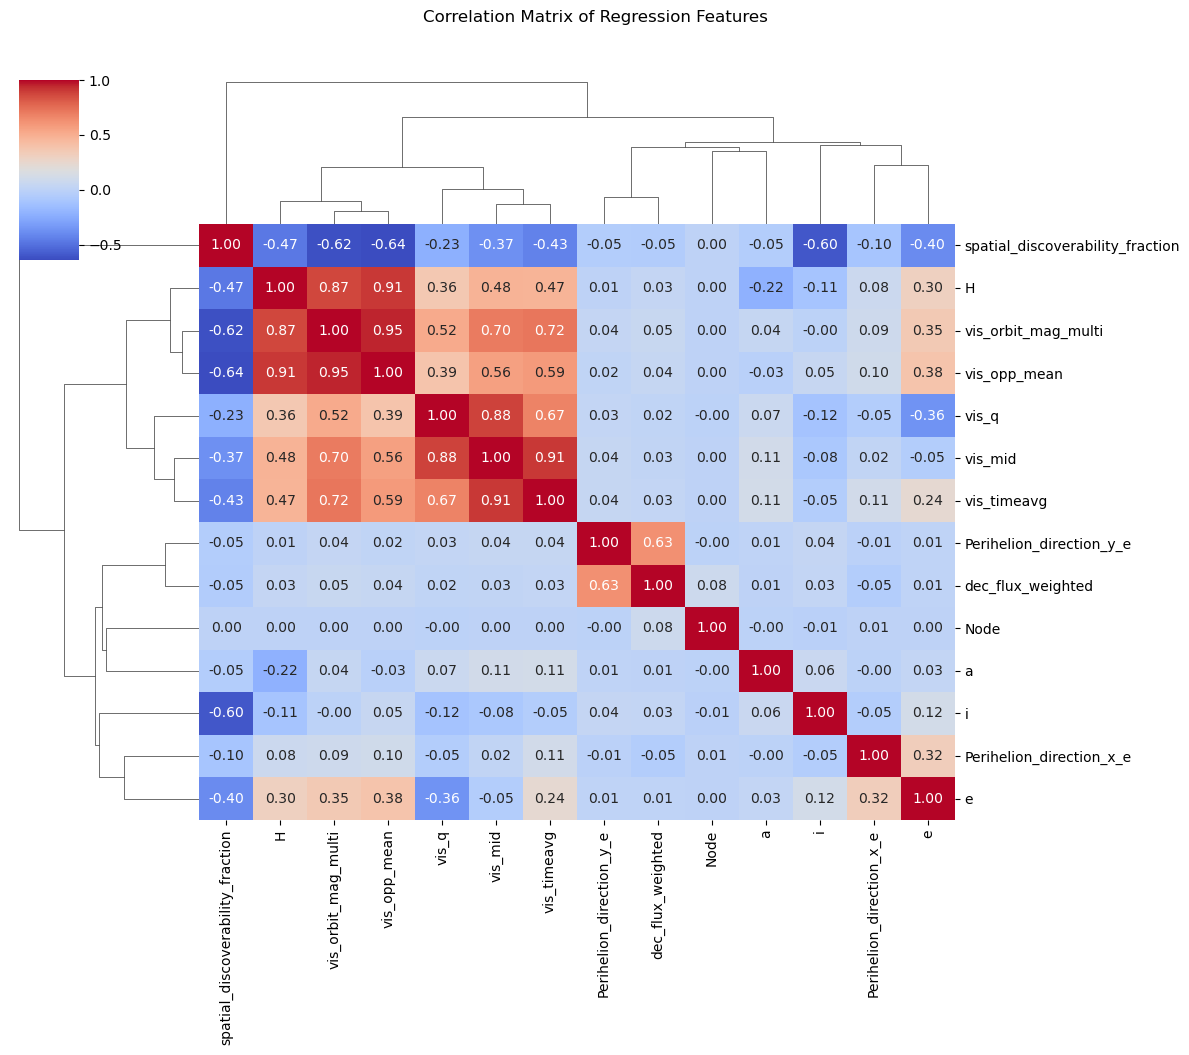

In [ ]:
# show correlation matrix of features in the regression model
import seaborn as sns
import matplotlib.pyplot as plt

corr = train_data_reg.drop(columns=["Num_opps_minus_one"]).corr()

# Use clustermap to automatically group related columns
g = sns.clustermap(corr, annot=True, fmt=".2f", cmap="coolwarm", figsize=(12, 10))
g.fig.suptitle("Correlation Matrix of Regression Features", y=1.05)
plt.show()

In [ ]:
# stop
raise Exception("Stop here for now.")

Exception: Stop here for now.

# SHAP plots

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.6.1
Python Version:     3.11.16
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.6.0: Mon Jan 19 22:00:55 PST 2026; root:xnu-11417.140.69.708.3~1/RELEASE_ARM64_T6000
CPU Count:          10
Pytorch Version:    2.10.0
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       6.01 GB / 32.00 GB (18.8%)
Disk Space Avail:   29.64 GB / 926.35 GB (3.2%)
Presets specified: ['good_quality']
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this risk by setting `save_bag_folds=True`.
Beginning A

[1000]	valid_set's poisson: -13.5556	valid_set's mean_poisson_deviance: -0.449896
[1000]	valid_set's poisson: -13.5753	valid_set's mean_poisson_deviance: -0.451106
[1000]	valid_set's poisson: -13.5271	valid_set's mean_poisson_deviance: -0.449989
[1000]	valid_set's poisson: -13.5543	valid_set's mean_poisson_deviance: -0.44964
[1000]	valid_set's poisson: -13.6558	valid_set's mean_poisson_deviance: -0.453985
[1000]	valid_set's poisson: -13.5748	valid_set's mean_poisson_deviance: -0.451326
[1000]	valid_set's poisson: -13.4877	valid_set's mean_poisson_deviance: -0.450706
[1000]	valid_set's poisson: -13.5412	valid_set's mean_poisson_deviance: -0.45223


	-0.4511	 = Validation score   (-mean_poisson_deviance)
	122.9s	 = Training   runtime
	4.37s	 = Validation runtime
Fitting model: XGBoost_BAG_L1 ... Training model for up to 471.73s of the 471.73s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=10, gpus=0)
	-0.4518	 = Validation score   (-mean_poisson_deviance)
	77.6s	 = Training   runtime
	0.93s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ... Training model for up to 360.00s of the 392.92s of remaining time.
	Fitting 1 model on all data | Fitting with cpus=10, gpus=0, mem=0.1/6.6 GB
	Ensemble Weights: {'LightGBM_BAG_L1': 0.6, 'XGBoost_BAG_L1': 0.4}
	-0.4506	 = Validation score   (-mean_poisson_deviance)
	0.64s	 = Training   runtime
	0.01s	 = Validation runtime
AutoGluon training complete, total runtime = 207.91s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 27541.0 rows/s (146227 batch size)
Automatically performing refit_

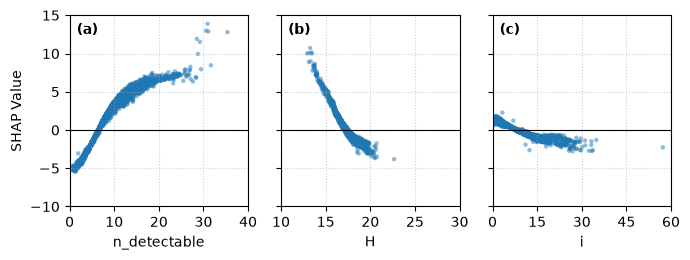

Saved 1 PGF files to additional code for paper/shap_simple_figures


In [88]:
data_df_reg = orb_training.dropna(subset=["H"])[mlcols_reg+[
    # 'vis_opp_fluxsum',
    ]].astype(np.float32)
# drop any desired columns
data_df_reg.drop(columns=[], inplace=True)

# Split data_df_reg into training and test sets
train_data_reg = data_df_reg.sample(len(data_df_reg)-150000, random_state=18)
test_data_reg = data_df_reg.drop(train_data_reg.index)

# drop the exp_Num_opps column from both sets as this is intended only for the quantile regression model to reference the output of the main (Poisson-loss) regression model
train_data_reg = train_data_reg.drop(columns=["Shared_Fold","exp_Num_opps"], errors="ignore")
test_data_reg = test_data_reg.drop(columns=["Shared_Fold","exp_Num_opps"], errors="ignore")

import sys, importlib
sys.path.insert(0, "additional code for paper")
import shap_simple
importlib.reload(shap_simple)

# subset train_data_reg and test_data_reg to only include MBAs (generous definition)
train_mbas = train_data_reg[(train_data_reg['a'] > 1.7) & (train_data_reg['a'] < 3.5)]  # Replace 'a' with the actual column name for the second condition if needed
test_mbas = test_data_reg[(test_data_reg['a'] > 1.7) & (test_data_reg['a'] < 3.5)]  # Replace 'a' with the actual column name for the second condition if needed

model_s, X_test_s, shap_values_s = shap_simple.run(
    train_mbas.dropna()[['n_detectable', 'H', 'i', 'Num_opps_minus_one']],
    test_mbas.dropna()[['n_detectable', 'H', 'i', 'Num_opps_minus_one']],
    out_dir="additional code for paper/shap_simple_figures",
)

## Some interesting plots

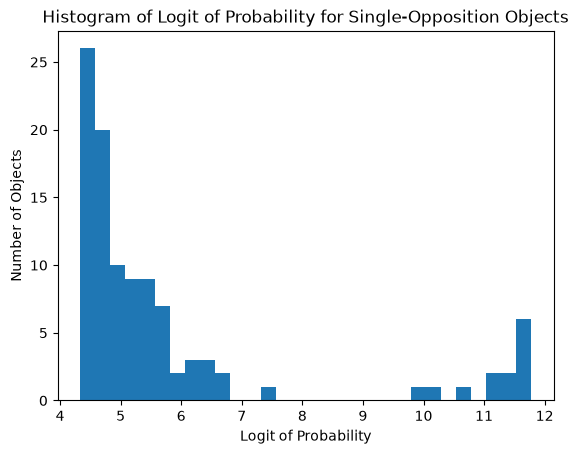

In [104]:
%matplotlib inline
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

# plot histogram of logit_prob
tempout = final[(final["Arc_length"]>7)
      &(final["Num_obs"]>6)
      &(final["prob"]>0.987)
      # &(final["TJ"]>3.05)
      &(final["a"]>1.1)
      &(final["a"]<5.4)
      &(~final["a"].between(5,5.4))
      &(final["extension_difficulty"]<0.02)
      &(final["Orbital_period"]<20)].copy()

# # The following code can be uncommented in order to remove recently discovered objects which may not have complete ITF and DESDES linkages and may corrupt training slightly. The following is an example of removing entries which are MPEC DOU E2026-L and later.
# tempout = tempout[~((tempout["Num_opps"]==1)
#                               &(tempout["Ref"].str.startswith("E2026"))
#                               &(tempout["Ref"]>"E2026-L"))]

tempout["logit_prob"] = np.log(tempout["prob"]/(1-tempout["prob"]))

plt.hist(tempout["logit_prob"], bins=30)
plt.xlabel("Logit of Probability")
plt.ylabel("Number of Objects")
plt.title("Histogram of Logit of Probability for Single-Opposition Objects")
plt.show()

In [105]:
tempout[tempout["prob"]>0.998][["Num_obs","Arc_length","U","prob","extension_difficulty","nights_total","Known / Strong Suspect"]].sort_values("prob", ascending=False)

,Num_obs,Arc_length,U,prob,extension_difficulty,nights_total,Known / Strong Suspect
Principal_desig,,,,,,,
2025 HV38,48,51,8,0.999992,0.000002,18.0,True
2015 BC566,52,39,5,0.999992,0.000003,11.0,True
2001 BV70,32,50,10,0.999992,0.000164,8.0,True
2007 VB146,13,16,10,0.999991,0.001466,4.0,True
2008 BJ22,53,83,4,0.999991,0.000014,13.0,True
2025 VZ8,50,43,6,0.999991,0.000003,15.0,True
2019 OE31,32,137,3,0.999989,0.000071,10.0,True
2021 AY8,24,101,4,0.999989,0.000009,7.0,True
2018 BJ11,46,107,5,0.999987,0.000013,13.0,True


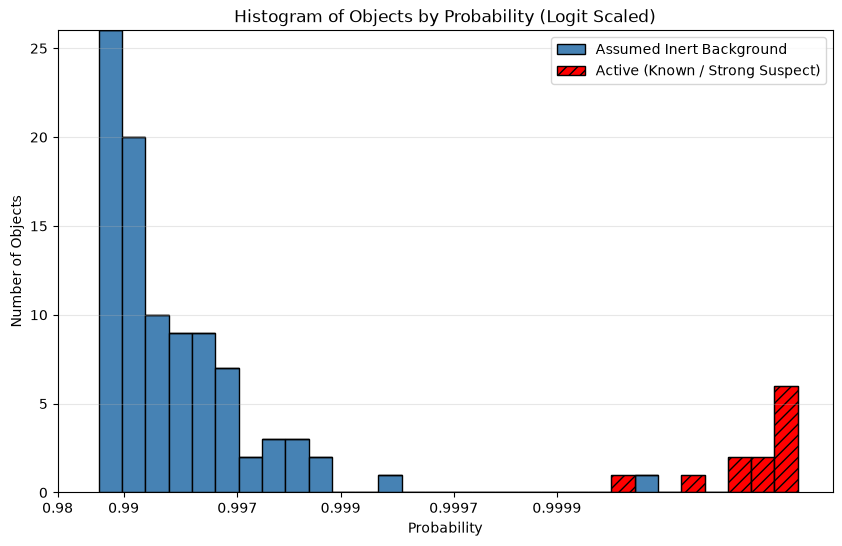

In [106]:
# 1. Calculate logit as before
tempout["logit_prob"] = np.log(tempout["prob"] / (1 - tempout["prob"]))

# 2. Split by activity status
active_mask = tempout["Known / Strong Suspect"].astype(bool)
logit_active = tempout.loc[active_mask, "logit_prob"]
logit_background = tempout.loc[~active_mask, "logit_prob"]

# 3. Define shared bins
bins = np.histogram_bin_edges(tempout["logit_prob"], bins=30)

# 4. Plot stacked histogram
plt.figure(figsize=(10, 6))
plt.hist([logit_background, logit_active], bins=bins, stacked=True,
         color=['steelblue', 'red'], edgecolor='black')

# Add black hatching over active bars for colorblind accessibility
bg_counts, _ = np.histogram(logit_background, bins=bins)
plt.hist(logit_active, bins=bins, bottom=bg_counts,
         color=(0, 0, 0, 0), edgecolor='black', hatch='///', linewidth=0.8)

# 5. Define the probability values you want to see on the X-axis
prob_ticks = np.array([0.98, 0.99, 0.997, 0.999, 0.9997, 0.9999])
logit_ticks = np.log(prob_ticks / (1 - prob_ticks))
plt.xticks(logit_ticks, labels=[f"{p}" for p in prob_ticks])

plt.xlabel("Probability")
plt.ylabel("Number of Objects")
plt.title("Histogram of Objects by Probability (Logit Scaled)")

# Custom legend handles so the key matches the bars (fill + hatch)
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(facecolor='steelblue', edgecolor='black', label='Assumed Inert Background'),
    mpatches.Patch(facecolor='red', edgecolor='black', hatch='///', label='Active (Known / Strong Suspect)'),
]
plt.legend(handles=legend_handles)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
import matplotlib
import matplotlib.patches as mpatches
matplotlib.use("pgf")
# Optional: Configure PGF settings to automatically match your LaTeX document style
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "font.family": "serif",
    "text.usetex": True,
    "pgf.rcfonts": False,
})

# Calculate logit as before
tempout["logit_prob"] = np.log(tempout["prob"] / (1 - tempout["prob"]))

# Split by activity status
active_mask = tempout["Known / Strong Suspect"].astype(bool)
logit_active = tempout.loc[active_mask, "logit_prob"]
logit_background = tempout.loc[~active_mask, "logit_prob"]

# Define shared bins
bins = np.histogram_bin_edges(tempout["logit_prob"], bins=30)

# Initialize the figure
fig, ax = plt.subplots(figsize=(4.5, 2.5))

# Stacked histogram: blue for background, red for active
ax.hist([logit_background, logit_active], bins=bins, stacked=True,
        color=['steelblue', 'red'], edgecolor='black')

# Add black hatching over active bars for colorblind accessibility
bg_counts, _ = np.histogram(logit_background, bins=bins)
ax.hist(logit_active, bins=bins, bottom=bg_counts,
        color=(0, 0, 0, 0), edgecolor='black', hatch='///', linewidth=0.8)

# Define the probability values you want to see on the X-axis
prob_ticks = np.array([0.99, 0.999, 0.9999, 0.99999])
logit_ticks = np.log(prob_ticks / (1 - prob_ticks))
ax.set_xticks(logit_ticks)
ax.set_xticklabels([f"{p}" for p in prob_ticks])

ax.set_xlabel(r"$P(N_{\rm opp}\ge4)$")
ax.set_ylabel("Number of Objects")

# Custom legend handles so the key matches the bars (fill + hatch)
legend_handles = [
    mpatches.Patch(facecolor='steelblue', edgecolor='black', label='Assumed Inert Background'),
    mpatches.Patch(facecolor='red', edgecolor='black', hatch='///', label='Active (Known / Strong Suspect)'),
]
ax.legend(handles=legend_handles)

# Save the figure as a .pgf file
plt.savefig("histogram.pgf", bbox_inches="tight")

# Spreads that are clearly narrower than Poisson

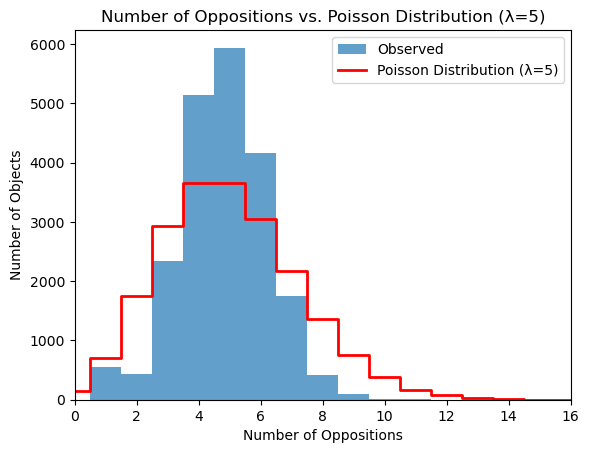

In [ ]:
# 1. Filter the data (as per your logic)
# Note: Filtering for 4.9 < x < 5.1 effectively selects objects where exp_Num_opps is 5

final_56 = final[(final["exp_Num_opps"] > 4.9) & (final["exp_Num_opps"] < 5.1)]
final_56 = final_56[final_56["Num_obs"] > 13]

# 2. Plot the histogram
# Bins [0.5, 1.5, 2.5...] center the bars on integers 1, 2, 3...
plt.hist(final_56["Num_opps"], bins=np.arange(0.5, 16.5, 1), alpha=0.7, label='Observed')

# 3. Prepare Poisson distribution data
x = np.arange(0, 17) # Range to cover the histogram bins
lambda_ = 5
poisson_pmf = poisson.pmf(x, lambda_)
# Scale PMF by the number of objects to match the histogram frequency
y = poisson_pmf * len(final_56)

# 4. Plot the red line as a stepwise function
# 'where='mid'' aligns the horizontal steps with the centers of the histogram bins
plt.step(x, y, color='red', where='mid', linewidth=2, label='Poisson Distribution (λ=5)')

# Formatting
plt.xlabel("Number of Oppositions")
plt.ylabel("Number of Objects")
plt.title("Number of Oppositions vs. Poisson Distribution (λ=5)")
plt.legend()
plt.xlim(0, 16)
plt.show()

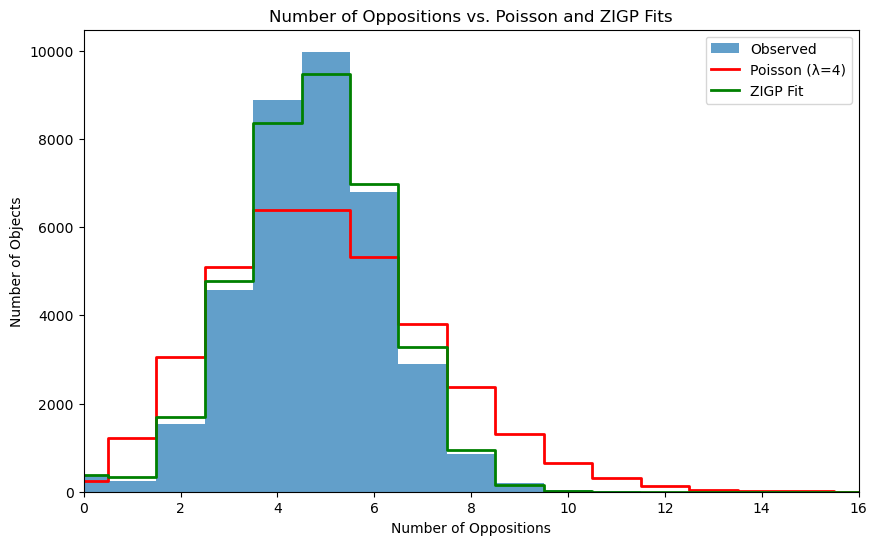

In [ ]:


# ... [Your previous data loading/filtering code] ...
# Assuming 'final' is already loaded as per your context

# 1. Filter the data
final_56 = final[(final["exp_Num_opps"] > 5.8) & (final["exp_Num_opps"] < 6.2)]
final_56 = final_56[final_56["Num_obs"] > 13]
final_56["exp_Num_Recov"] = final_56["exp_Num_opps"] - 1
final_56["Num_Recov"] = final_56["Num_opps"] - 1

# 2. Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(final_56["Num_Recov"], bins=np.arange(-0.5, 16.5, 1), alpha=0.7, label='Observed')

# 3. Prepare Poisson distribution data (Red Line)
x = np.arange(0, 17)
lambda_ = 5
poisson_pmf = poisson.pmf(x, lambda_)
y_poisson = poisson_pmf * len(final_56)
plt.step(x, y_poisson, color='red', where='mid', linewidth=2, label='Poisson (λ=4)')

# ---------------------------------------------------------
# 4. Fit ZIGP and Plot (Green Line)
# ---------------------------------------------------------

# Prepare data for Statsmodels
# We need an 'intercept' (column of 1s) to fit the mean of the distribution
endog = final_56["Num_Recov"]
exog = np.ones((len(endog), 1))

# Initialize and fit the ZIGP model
# inflation='logit' is the standard method for modeling the zero-inflation probability
zigp_model = sm.ZeroInflatedGeneralizedPoisson(endog, exog, inflation='logit')
res_zigp = zigp_model.fit(disp=0)  # disp=0 suppresses convergence messages

# Calculate predicted PMF
# We use a single dummy observation [1] to predict the distribution curve
exog_pred = np.array([[1.0]])
zigp_dist = res_zigp.get_distribution(exog=exog_pred)
zigp_pmf = zigp_dist.pmf(x) # Get PMF for x = 0..16

# Depending on statsmodels version, the output shape might vary. 
# We ensure it's a flat array matching 'x'
if zigp_pmf.ndim > 1:
    zigp_pmf = zigp_pmf.flatten()

# Scale to match histogram counts
y_zigp = zigp_pmf * len(final_56)

# Plot the green line
plt.step(x, y_zigp, color='green', where='mid', linewidth=2, label='ZIGP Fit')
# ---------------------------------------------------------

# Formatting
plt.xlabel("Number of Oppositions")
plt.ylabel("Number of Objects")
plt.title("Number of Oppositions vs. Poisson and ZIGP Fits")
plt.legend()
plt.xlim(0, 16)
plt.show()

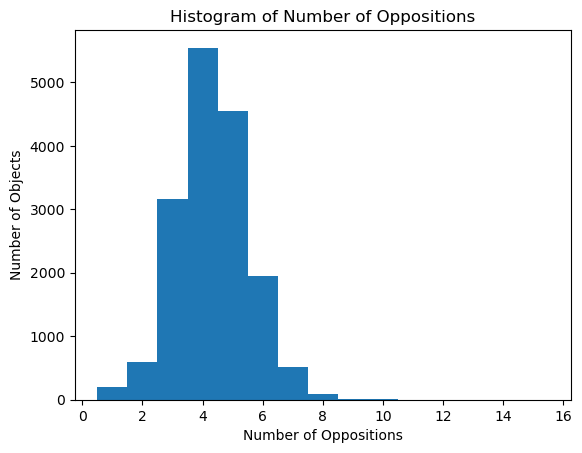

In [ ]:
# filter final for objects with exp_Num_opps between 5 and 6
final_56 = final[(final["exp_Num_opps"]>4) & (final["exp_Num_opps"]<4.2)]
final_56 = final_56[final_56["Num_obs"]>30]
# show a histogram of number of opps for final_56
plt.hist(final_56["Num_opps"], bins=np.arange(0.5, 16.5, 1))
plt.xlabel("Number of Oppositions")
plt.ylabel("Number of Objects")
plt.title("Histogram of Number of Oppositions")
plt.show()

# On to some tables, including the big one

In [92]:
# Brightest objects with ____ or later initial linkage and designation
cols_to_show = ["Num_obs","Num_opps","Ref","Arc_length","prob", "exp_Num_opps" , "extension_difficulty"]
tempout = final[(pd.to_numeric(final.index.str[0:4], errors="coerce")>=2025)
                &(pd.to_numeric(final.index.str[0:4], errors="coerce")<=2026)
                &(final["extension_difficulty"]<0.1)
      &(final["prob"]>0.999)]
tempout = tempout[cols_to_show]
tempout.head(20).to_clipboard()
tempout.head(20)

,Num_obs,Num_opps,Ref,Arc_length,prob,exp_Num_opps,extension_difficulty
Principal_desig,,,,,,,
2025 HV38,48,1,MPO988024,51,0.999992,20.975428,0.000002
2025 ME397,12,1,E2026-OA4,28,0.999856,22.534264,0.029709
2026 GW20,13,1,E2026-OA4,7,0.999631,14.838529,0.002657
2025 VZ8,50,1,MPO988040,43,0.999991,12.467668,0.000003
2025 PO267,6,1,E2026-L10,4,0.999987,11.771912,0.064264
2026 BS14,65,3,E2026-PA2,<NA>,0.999931,15.340380,0.002920
2025 MA388,11,1,E2026-M34,23,0.999693,17.294031,0.003105
2026 GS23,15,1,E2026-OA4,95,0.999660,16.095924,0.000060
2025 PA2,100,3,E2026-RD3,<NA>,0.999958,14.313383,0.000045


In [93]:
# OUTPUT BIG TABLE FOR PAPER

for_paper = final.copy()
for_paper["Principal_desig"] = for_paper.index
for_paper["Object"] = for_paper["Number"].astype(str) + " " + for_paper["Principal_desig"]
# replace "<NA> " with ""
for_paper["Object"] = for_paper["Object"].str.replace("<NA> ", "")

import paper_table, importlib
importlib.reload(paper_table)

# Build one lookup frame from both sources (orbit-derived + comet-file objects)
combined = paper_table.combine_sources(for_paper, cometmerge)

# Render the full table; notes/group/asterisk come from the CSV
latex = paper_table.build_table(combined, "table_notes.csv")
print(latex)

# also output it to temp_table.tex
with open("temp_table.tex", "w") as f:
    f.write(latex)

\begin{longrotatetable}

\begin{longtable}{lrrrrrrrrrrrl}
\caption{\activityscope\ candidates, recoveries, and false positives. Confirmed active objects are marked with an asterisk.}
\label{tab:activityscope_results}\\
\toprule
Object & $q$ {\footnotesize (AU)} & $a$ {\footnotesize (AU)} & $e$ & $i~(^\circ)$ &
$T_J$\tabnote{Tisserand parameter with respect to Jupiter.} &
$H_V$\tabnote{Absolute magnitude in the $V$ band, assuming an inert object.} &
$N_{\rm opp}$\tabnote{Number of oppositions on which the object has been observed.} &
{\footnotesize $E[N_{\rm opp}]$}\tabnote{Expected number of observed oppositions for an inert object of the same orbit and $H_V$, predicted by the regression model.} &
{\footnotesize $P(N_{\rm opp}\ge4)$}\tabnote{Binary-classifier probability that an inert object of the same orbit and $H_V$ would be observed on at least four oppositions.} &
$\Delta Q$\tabnote{Quantile deficit $\Delta Q = Q_{0.006} - N_{\rm opp}$, where $Q_{0.006}$ is the model's $0.006$-qua

# Decision space scatter

['2003 BM80', '2008 GO98', '2010 RH69', '2017 QN84']


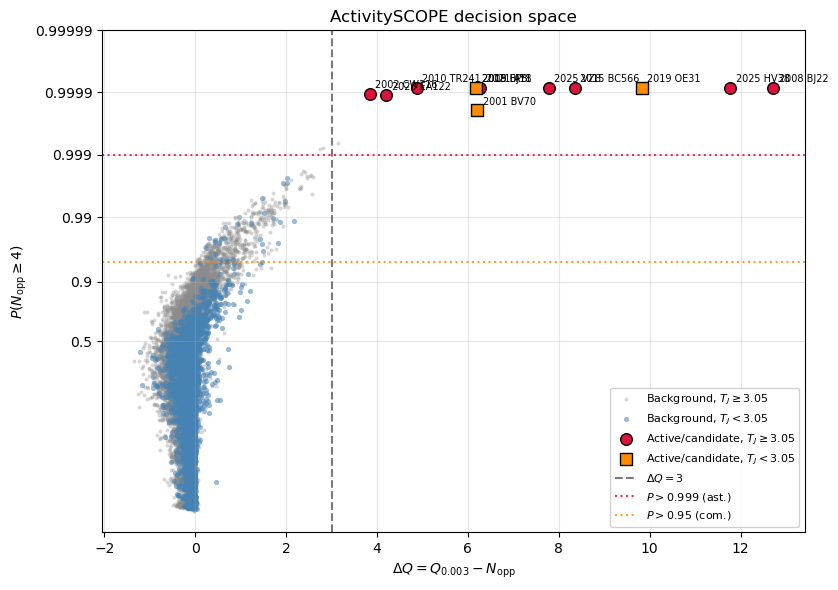

In [ ]:
#reload dss first
import decision_space_scatter as dss
import importlib
importlib.reload(dss)

fig, ax, info = dss.decision_space_scatter(final)
print(info["actives_missing"])
fig

In [ ]:
raise Exception("Stop here for now.")

Exception: Stop here for now.

# Nearest Neighbor Code
You can use this to troubleshoot or figure out why an object is getting the ratings it is getting.

In [ ]:
obj_to_examine = "2012 BG126"

nn_cols = ["vis_typ", "H", "e", "i", "node_plus_peri", "Peri", "Node"]#"Peri"] #"Tp", 
scaler = StandardScaler()
final_normalized = scaler.fit_transform(final[nn_cols])
nn = NearestNeighbors(n_neighbors=25)
nn.fit(final_normalized)
obj = final[final.index==obj_to_examine][nn_cols]
obj_normalized = scaler.transform(obj)
distances, indices = nn.kneighbors(obj_normalized)
out = final.iloc[indices[0]][["H","a","e","i", "Tp", "Node", "Peri", "Tp", "Num_opps", "extension_difficulty", "exp_Num_opps", "prob"]]
out.to_clipboard()
out

,H,a,e,i,Tp,Node,Peri,Tp,Num_opps,extension_difficulty,exp_Num_opps,prob
Principal_desig,,,,,,,,,,,,
2012 BG126,15.39,3.041732,0.082865,21.03676,2460258.95123,310.22647,278.46058,2460258.95123,8,0.000175,14.705095,0.999992
2009 BB97,15.32,3.101336,0.088202,20.4025,2461421.68992,317.99525,279.53566,2461421.68992,16,0.000175,15.097328,0.999987
2005 YK274,15.24,3.238312,0.078544,19.71457,2460713.35298,309.28534,280.08249,2460713.35298,11,0.000175,14.376964,0.999991
2001 XR265,15.36,3.212228,0.087201,21.79221,2461288.12088,293.62028,295.27425,2461288.12088,16,0.000175,13.267000,0.999990
2011 YX67,15.03,3.113697,0.106497,19.64384,2460499.01973,310.47646,282.54399,2460499.01973,14,0.000175,17.009636,0.999983
2009 BT28,15.47,3.142841,0.044506,20.8063,2461530.4537,308.14348,283.28166,2461530.4537,15,0.000175,13.100785,0.999986
2008 AL43,15.27,3.073904,0.068009,21.35645,2460714.40593,312.27526,247.9459,2460714.40593,14,0.000175,15.034163,0.999994
2015 QQ11,15.11,3.234569,0.089952,21.25263,2460550.45482,278.26638,281.88873,2460550.45482,14,0.000175,14.653041,0.999986
2015 MU91,15.38,3.231661,0.076463,20.90115,2461202.32648,305.91396,310.72713,2461202.32648,13,0.000175,13.130423,0.999992


# Variant Orbit Examination

In [ ]:
var_orbs = """00001   17.90  0.15 K262I 152.24281   27.64839  322.97462    1.63045  0.0823479  0.23441982   2.6049926    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [1]                 20260218
00002   17.83  0.15 K262I 160.20460   20.25129  323.07161    1.69034  0.0960834  0.23536447   2.5980178    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [2]                 20260218
00003   17.83  0.15 K262I 158.32285   21.80090  323.07219    1.69055  0.0967820  0.23528060   2.5986351    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [3]                 20260218
00004   17.59  0.15 K262I 174.49683    7.54475  323.38309    1.90854  0.1518294  0.23885153   2.5726697    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [4]                 20260218
00005   17.00  0.15 K262I 189.47235  357.52604  324.13476    2.68577  0.3310300  0.24986307   2.4965178    FO 260222    14   1    9 days 0.13 M-P 06  Find_Orb   0000 K26C04V [5]                 20260218
00006   18.20  0.15 K262I  98.34873   80.49982  322.55601    1.40728  0.0494537  0.23177571   2.6247670    FO 260222    14   1    9 days 0.13 M-P 06  Find_Orb   0000 K26C04V [6]                 20260218
00007   18.03  0.15 K262I 134.76390   44.61176  322.79552    1.52888  0.0615590  0.23307270   2.6150206    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [7]                 20260218
00008   17.63  0.15 K262I 174.93831    7.32511  323.34164    1.87653  0.1432720  0.23838381   2.5760337    FO 260222    14   1    9 days 0.13 M-P 06  Find_Orb   0000 K26C04V [8]                 20260218
00009   17.54  0.15 K262I 177.38891    5.25888  323.45241    1.96341  0.1657088  0.23973982   2.5663109    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [9]                 20260218
00010   17.23  0.15 K262I 184.88501  359.91143  323.84951    2.33632  0.2559067  0.24534987   2.5270403    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [10]                20260218
00011   17.69  0.15 K262I 168.65602   12.43568  323.25764    1.81519  0.1282929  0.23731491   2.5837631    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [11]                20260218
00012   17.64  0.15 K262I 170.75264   10.58060  323.31710    1.85855  0.1392735  0.23799215   2.5788592    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [12]                20260218
00013   17.46  0.15 K262I 177.69573    4.83165  323.56644    2.05974  0.1895489  0.24117820   2.5560971    FO 260222    14   1    9 days 0.13 M-P 06  Find_Orb   0000 K26C04V [13]                20260218
00014   17.64  0.15 K262I 170.97008   10.37586  323.32892    1.86728  0.1411996  0.23810404   2.5780512    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [14]                20260218
00015   17.37  0.15 K262I 181.92706    1.83058  323.67342    2.15745  0.2133049  0.24269613   2.5454280    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [15]                20260218
00016   17.58  0.15 K262I 175.29122    6.90915  323.40206    1.92346  0.1551241  0.23906166   2.5711619    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [16]                20260218
00017   17.43  0.15 K262I 180.47645    2.87352  323.59453    2.08449  0.1957380  0.24159396   2.5531638    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [17]                20260218
00018   17.30  0.15 K262I 183.61075    0.70410  323.76881    2.25111  0.2364933  0.24415886   2.5352515    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [18]                20260218
00019   17.98  0.15 K262I 144.47052   35.44622  322.86006    1.56389  0.0662710  0.23361318   2.6109857    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [19]                20260218
00020   17.69  0.15 K262I 171.14157   10.50217  323.25942    1.81645  0.1275482  0.23738192   2.5832769    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [20]                20260218
00021   18.42  0.15 K262I  58.61837  119.13291  322.24534    1.27096  0.0685787  0.23077435   2.6323544    FO 260222    14   1    9 days 0.15 M-P 06  Find_Orb   0000 K26C04V [21]                20260218
00022   17.90  0.15 K262I 154.63727   25.64290  322.97205    1.62874  0.0809547  0.23451997   2.6042509    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [22]                20260218
00023   18.07  0.15 K262I 127.62819   51.68413  322.73785    1.49790  0.0560880  0.23271670   2.6176868    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [23]                20260218
00024   17.50  0.15 K262I 177.25830    5.24655  323.50894    2.01014  0.1771184  0.24040262   2.5615918    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [24]                20260218
00025   17.83  0.15 K262I 158.13692   21.96326  323.06870    1.68853  0.0966867  0.23527649   2.5986654    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [25]                20260218
00026   18.23  0.15 K262I  90.22950   88.67651  322.50767    1.38467  0.0484954  0.23164083   2.6257858    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [26]                20260218
00027   18.10  0.15 K262I 122.86168   56.46823  322.69992    1.47853  0.0528094  0.23253554   2.6190462    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [27]                20260218
00028   17.90  0.15 K262I 153.29502   26.80185  322.96913    1.62736  0.0810596  0.23445425   2.6047376    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [28]                20260218
00029   18.01  0.15 K262I 139.89147   39.86926  322.81958    1.54161  0.0622460  0.23332778   2.6131144    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [29]                20260218
00030   17.55  0.15 K262I 175.73701    6.49505  323.43606    1.95031  0.1626016  0.23950401   2.5679951    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [30]                20260218
00031   17.97  0.15 K262I 143.53109   36.05389  322.87821    1.57434  0.0698641  0.23363202   2.6108453    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [31]                20260218
00032   17.73  0.15 K262I 167.73756   13.42313  323.19996    1.77505  0.1172632  0.23670640   2.5881893    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [32]                20260218
00033   17.58  0.15 K262I 174.36875    7.60207  323.39849    1.92033  0.1544570  0.23899112   2.5716678    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [33]                20260218
00034   18.13  0.15 K262I 113.07389   65.72607  322.65623    1.45588  0.0534425  0.23216266   2.6218497    FO 260222    14   1    9 days 0.14 M-P 06  Find_Orb   0000 K26C04V [34]                20260218
00035   18.29  0.15 K262I  78.63841  100.19070  322.43016    1.34970  0.0503050  0.23143086   2.6273738    FO 260222    14   1    9 days 0.13 M-P 06  Find_Orb   0000 K26C04V [35]                20260218
00036   17.81  0.15 K262I 161.14314   19.33251  323.09356    1.70422  0.0997693  0.23556823   2.5965194    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [36]                20260218
00037   18.15  0.15 K262I 111.68167   67.61835  322.62728    1.44192  0.0482069  0.23218722   2.6216648    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [37]                20260218
00038   17.73  0.15 K262I 169.76090   11.81115  323.20071    1.77517  0.1170121  0.23679414   2.5875500    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [38]                20260218
00039   17.52  0.15 K262I 176.63052    5.75203  323.47977    1.98581  0.1713605  0.24005356   2.5640743    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [39]                20260218
00040   17.93  0.15 K262I 151.83480   28.35642  322.93411    1.60621  0.0755780  0.23419810   2.6066365    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [40]                20260218
00041   17.94  0.15 K262I 148.67062   31.22994  322.91629    1.59602  0.0739880  0.23399549   2.6081409    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [41]                20260218
00042   17.92  0.15 K262I 152.12272   28.02475  322.94182    1.61114  0.0771341  0.23426332   2.6061527    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [42]                20260218
00043   17.60  0.15 K262I 173.62238    8.20246  323.38217    1.90778  0.1513624  0.23878918   2.5731175    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [43]                20260218
00044   17.54  0.15 K262I 175.64763    6.50300  323.46118    1.97057  0.1674085  0.23977672   2.5660476    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [44]                20260218
00045   17.84  0.15 K262I 158.59003   21.67040  323.05883    1.68169  0.0944826  0.23521540   2.5991153    FO 260222    14   1    9 days 0.13 M-P 06  Find_Orb   0000 K26C04V [45]                20260218
00046   17.61  0.15 K262I 173.21203    8.56699  323.36260    1.89274  0.1476462  0.23856800   2.5747077    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [46]                20260218
00047   17.37  0.15 K262I 180.79082    2.58771  323.67030    2.15475  0.2131202  0.24267445   2.5455796    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [47]                20260218
00048   17.85  0.15 K262I 159.55121   20.99661  323.04192    1.67144  0.0910009  0.23513063   2.5997399    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [48]                20260218
00049   18.10  0.15 K262I 124.37205   55.19942  322.69987    1.47811  0.0511035  0.23260921   2.6184932    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [49]                20260218
00050   17.72  0.15 K262I 169.50865   11.93818  323.21888    1.78825  0.1203812  0.23694634   2.5864418    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [50]                20260218
00051   17.43  0.15 K262I 178.80111    4.02335  323.59372    2.08388  0.1957434  0.24158214   2.5532470    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [51]                20260218
00052   17.65  0.15 K262I 172.74507    9.07527  323.31435    1.85646  0.1379218  0.23800893   2.5787380    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [52]                20260218
00053   17.84  0.15 K262I 162.12763   18.77037  323.05402    1.67937  0.0923907  0.23530694   2.5984412    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [53]                20260218
00054   17.79  0.15 K262I 163.09169   17.55393  323.12348    1.72366  0.1046646  0.23587397   2.5942751    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [54]                20260218
00055   17.88  0.15 K262I 159.31847   21.43566  323.00565    1.64935  0.0849453  0.23488711   2.6015365    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [55]                20260218
00056   17.66  0.15 K262I 172.43829    9.36452  323.29684    1.84363  0.1348104  0.23782135   2.5800937    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [56]                20260218
00057   17.19  0.15 K262I 185.60779  359.49318  323.89977    2.39165  0.2690798  0.24616319   2.5214710    FO 260222    14   1    9 days 0.15 M-P 06  Find_Orb   0000 K26C04V [57]                20260218
00058   18.00  0.15 K262I 142.85274   37.09591  322.83774    1.55144  0.0634243  0.23348133   2.6119685    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [58]                20260218
00059   17.89  0.15 K262I 156.20572   24.17638  322.98945    1.63915  0.0833612  0.23466866   2.6031508    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [59]                20260218
00060   17.78  0.15 K262I 165.42842   15.59073  323.13804    1.73328  0.1060494  0.23606970   2.5928410    FO 260222    14   1    9 days 0.13 M-P 06  Find_Orb   0000 K26C04V [60]                20260218
00061   17.65  0.15 K262I 170.87996   10.48934  323.31691    1.85829  0.1388468  0.23797096   2.5790122    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [61]                20260218
00062   17.93  0.15 K262I 151.44946   28.67069  322.93623    1.60771  0.0760182  0.23420436   2.6065901    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [62]                20260218
00063   17.82  0.15 K262I 160.57485   19.90174  323.07762    1.69424  0.0971648  0.23542468   2.5975748    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [63]                20260218
00064   17.69  0.15 K262I 169.85624   11.53057  323.25160    1.81084  0.1265887  0.23727992   2.5840171    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [64]                20260218
00065   17.97  0.15 K262I 145.24961   34.52159  322.88077    1.57592  0.0698343  0.23371671   2.6102145    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [65]                20260218
00066   18.02  0.15 K262I 138.40637   41.22127  322.81576    1.53934  0.0622543  0.23325092   2.6136884    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [66]                20260218
00067   17.74  0.15 K262I 166.56505   14.40737  323.18715    1.76612  0.1156393  0.23657561   2.5891432    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [67]                20260218
00068   18.03  0.15 K262I 134.84860   44.62910  322.79155    1.52620  0.0603271  0.23307295   2.6150187    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [68]                20260218
00069   17.65  0.15 K262I 171.60841    9.93165  323.31671    1.85840  0.1388761  0.23801842   2.5786694    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [69]                20260218
00070   17.90  0.15 K262I 152.57733   27.34976  322.97417    1.63041  0.0825719  0.23445602   2.6047244    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [70]                20260218
00071   17.92  0.15 K262I 152.63735   27.52119  322.95197    1.61683  0.0781173  0.23432540   2.6056923    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [71]                20260218
00072   17.99  0.15 K262I 141.52215   38.10700  322.85027    1.55853  0.0662199  0.23346304   2.6121050    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [72]                20260218
00073   17.74  0.15 K262I 166.61675   14.32353  323.19678    1.77292  0.1171897  0.23665646   2.5885535    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [73]                20260218
00074   17.75  0.15 K262I 167.51731   13.72856  323.17339    1.75680  0.1120746  0.23644093   2.5901263    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [74]                20260218
00075   17.78  0.15 K262I 162.90694   17.63822  323.13605    1.73203  0.1066703  0.23596497   2.5936082    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [75]                20260218
00076   17.84  0.15 K262I 162.67181   18.30935  323.05601    1.68023  0.0924533  0.23534281   2.5981772    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [76]                20260218
00077   17.89  0.15 K262I 153.51807   26.44370  322.98857    1.63875  0.0844073  0.23456310   2.6039317    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [77]                20260218
00078   17.78  0.15 K262I 164.13906   16.66117  323.13001    1.72822  0.1057232  0.23599356   2.5933987    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [78]                20260218
00079   18.10  0.15 K262I 120.06491   59.03347  322.69323    1.47460  0.0536524  0.23242834   2.6198514    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [79]                20260218
00080   17.93  0.15 K262I 149.59220   30.23110  322.93667    1.60820  0.0773171  0.23413041   2.6071389    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [80]                20260218
00081   17.76  0.15 K262I 166.07936   14.92245  323.16420    1.75057  0.1109926  0.23632420   2.5909792    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [81]                20260218
00082   17.90  0.15 K262I 154.39733   25.81719  322.97672    1.63171  0.0816262  0.23451880   2.6042596    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [82]                20260218
00083   17.98  0.15 K262I 145.91708   34.15588  322.86195    1.56521  0.0661434  0.23367592   2.6105183    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [83]                20260218
00084   17.53  0.15 K262I 177.04328    5.48254  323.46658    1.97509  0.1684478  0.23987877   2.5653198    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [84]                20260218
00085   17.91  0.15 K262I 151.84993   28.06986  322.96453    1.62463  0.0807946  0.23436187   2.6054220    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [85]                20260218
00086   17.50  0.15 K262I 178.64896    4.25859  323.50855    2.00974  0.1772906  0.24045467   2.5612221    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [86]                20260218
00087   17.28  0.15 K262I 183.43979    0.80884  323.78550    2.26858  0.2402142  0.24439006   2.5336524    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [87]                20260218
00088   17.90  0.15 K262I 154.67988   25.60787  322.97435    1.63032  0.0808569  0.23450570   2.6043566    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [88]                20260218
00089   17.43  0.15 K262I 179.17529    3.76381  323.59670    2.08620  0.1957061  0.24158447   2.5532306    FO 260222    14   1    9 days 0.15 M-P 06  Find_Orb   0000 K26C04V [89]                20260218
00090   17.18  0.15 K262I 187.62707  358.30563  323.91947    2.41440  0.2743552  0.24642827   2.5196625    FO 260222    14   1    9 days 0.14 M-P 06  Find_Orb   0000 K26C04V [90]                20260218
00091   17.87  0.15 K262I 154.14602   25.71812  323.01451    1.65440  0.0881926  0.23472738   2.6027166    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [91]                20260218
00092   17.70  0.15 K262I 169.78058   11.59571  323.25059    1.81052  0.1262871  0.23726518   2.5841242    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [92]                20260218
00093   17.77  0.15 K262I 166.39418   14.73995  323.14923    1.74100  0.1083621  0.23620997   2.5918144    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [93]                20260218
00094   17.92  0.15 K262I 151.99980   28.08050  322.95038    1.61588  0.0780598  0.23428990   2.6059555    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [94]                20260218
00095   17.47  0.15 K262I 178.94297    4.00309  323.54068    2.03715  0.1841863  0.24087478   2.5582432    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [95]                20260218
00096   17.68  0.15 K262I 169.94880   11.35247  323.27878    1.83055  0.1315972  0.23755172   2.5820457    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [96]                20260218
00097   17.80  0.15 K262I 163.47974   17.28499  323.11782    1.71969  0.1030122  0.23582043   2.5946678    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [97]                20260218
00098   17.93  0.15 K262I 150.33645   29.69307  322.92774    1.60280  0.0752077  0.23411609   2.6072452    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [98]                20260218
00099   17.50  0.15 K262I 177.94207    4.76676  323.50443    2.00629  0.1766940  0.24040133   2.5616009    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [99]                20260218
00100   17.65  0.15 K262I 171.40231   10.13319  323.30526    1.84961  0.1364320  0.23784767   2.5799034    FO 260222    14   1    9 days 0.13 M-P 06  Find_Orb   0000 K26C04V [100]               20260218
00101   18.04  0.15 K262I 137.56606   42.34088  322.78803    1.52458  0.0575773  0.23316755   2.6143114    FO 260222    14   1    9 days 0.12 M-P 06  Find_Orb   0000 K26C04V [101]               20260218
00102   17.50  0.15 K262I 177.77613    4.88964  323.50194    2.00410  0.1760410  0.24036354   2.5618694    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [102]               20260218
00103   17.89  0.15 K262I 157.44198   23.10152  322.99693    1.64401  0.0835225  0.23472714   2.6027184    FO 260222    14   1    9 days 0.14 M-P 06  Find_Orb   0000 K26C04V [103]               20260218
00104   18.20  0.15 K262I  97.13465   81.68562  322.55146    1.40499  0.0495504  0.23174124   2.6250274    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [104]               20260218
00105   17.61  0.15 K262I 173.12454    8.64746  323.35755    1.88897  0.1467323  0.23850379   2.5751697    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [105]               20260218
00106   17.93  0.15 K262I 150.68953   29.34034  322.93462    1.60665  0.0759541  0.23415440   2.6069608    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [106]               20260218
00107   17.62  0.15 K262I 172.70510    8.98621  323.34978    1.88313  0.1453935  0.23840775   2.5758613    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [107]               20260218
00108   17.41  0.15 K262I 179.88578    3.23824  323.62851    2.11567  0.2034440  0.24207055   2.5498115    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [108]               20260218
00109   17.79  0.15 K262I 163.16984   17.45471  323.12899    1.72753  0.1057622  0.23593221   2.5938482    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [109]               20260218
00110   18.04  0.15 K262I 132.55999   46.84725  322.77460    1.51728  0.0590063  0.23294721   2.6159597    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [110]               20260218
00111   17.43  0.15 K262I 179.92232    3.24506  323.60150    2.09116  0.1976791  0.24170726   2.5523658    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [111]               20260218
00112   17.70  0.15 K262I 168.24427   12.84166  323.23916    1.80216  0.1247056  0.23710116   2.5853158    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [112]               20260218
00113   18.11  0.15 K262I 118.95288   60.26110  322.67903    1.46752  0.0519275  0.23239807   2.6200789    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [113]               20260218
00114   17.69  0.15 K262I 168.76775   12.37221  323.25405    1.81261  0.1271287  0.23725244   2.5842167    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [114]               20260218
00115   17.61  0.15 K262I 173.45052    8.36567  323.37044    1.89854  0.1490525  0.23865061   2.5741134    FO 260222    14   1    9 days 0.10 M-P 06  Find_Orb   0000 K26C04V [115]               20260218
00116   17.70  0.15 K262I 169.14366   12.12168  323.24426    1.80578  0.1251112  0.23717098   2.5848083    FO 260222    14   1    9 days 0.09 M-P 06  Find_Orb   0000 K26C04V [116]               20260218
00117   17.87  0.15 K262I 156.90744   23.40272  323.01454    1.65440  0.0871986  0.23484700   2.6018327    FO 260222    14   1    9 days 0.11 M-P 06  Find_Orb   0000 K26C04V [117]               20260218
"""

In [ ]:
# parse these as fwf
mpc_names = ["Provis","H","G","Epoch","M","Peri","Node","i","e","n","a","ignore1","Num_obs","Num_opps","Arc_length","ignore2","Last_obs"]
mpc_widths = [7,6,6,6,10,11,11,11,11,12,12,13,6,4,5,63,8]

# take var_orbs as a string and turn it into a StringIO object
from io import StringIO
var_orbs_io = StringIO(var_orbs)

var_orb = pd.read_fwf(var_orbs_io, index_col=False, names=mpc_names, widths=mpc_widths, skiprows=0)


In [ ]:
# Define the character mappings based on the specifications
CENTURY_MAP = {'I': '18', 'J': '19', 'K': '20'}

# Generate Month Map: 1-9, then A-C
MONTH_CHARS = '123456789ABC'
MONTH_MAP = {char: str(idx + 1).zfill(2) for idx, char in enumerate(MONTH_CHARS)}

# Generate Day Map: 1-9, then A-V
DAY_CHARS = '123456789ABCDEFGHIJKLMNOPQRSTUV'
DAY_MAP = {char: str(idx + 1).zfill(2) for idx, char in enumerate(DAY_CHARS)}

def parse_packed_date(val):
    """
    Parses a single packed date string into a pandas Timestamp.
    """
    if pd.isna(val) or not isinstance(val, str) or len(val) < 5:
        return pd.NaT

    # Extract standard components
    cent_char = val[0].upper()
    yy = val[1:3]
    month_char = val[3].upper()
    day_char = val[4].upper()

    # Map to standard date strings
    century = CENTURY_MAP.get(cent_char)
    month = MONTH_MAP.get(month_char)
    day = DAY_MAP.get(day_char)

    # Validate that all parts were successfully mapped
    if not all([century, month, day]):
        return pd.NaT 

    # Formulate the base date
    base_date = pd.to_datetime(f"{century}{yy}-{month}-{day}")

    # Handle decimal fraction of the day if it exists
    if len(val) > 5:
        fraction_str = "0." + val[5:]
        fraction = float(fraction_str)
        # Add the fraction of the day as a timedelta
        base_date += pd.Timedelta(days=fraction)

    return base_date
var_orb["Epoch"] = var_orb["Epoch"].apply(parse_packed_date)

In [ ]:
var_orb

,Provis,H,G,Epoch,M,Peri,Node,i,e,n,a,ignore1,Num_obs,Num_opps,Arc_length,ignore2,Last_obs
0,Z0001Wf,19.7,0.15,2014-05-03,36.91684,316.09139,216.78131,2.31557,0.047127,0.304121,2.189972,9 OrbImp,14,1,2,days 0.07 M-v 3Ek Doppler 2.0867659 2456659.111297,20250419
1,Z0001Wg,20.0,0.15,2014-05-03,327.67978,231.97327,25.66523,2.73118,0.159702,0.280968,2.308688,9 OrbImp,12,1,2,days 0.08 M-v 3Ek Doppler 1.9399849 2456895.531827,20250419
2,Z0001Wh,18.6,0.15,2014-05-03,94.94818,236.03942,212.46378,1.12222,0.262186,0.247911,2.509606,9 OrbImp,13,1,2,days 0.09 M-v 3Ek Doppler 1.8516215 2456397.507061,20250419
3,Z0001Wj,17.2,0.15,2014-05-03,81.20165,39.21633,33.96953,3.20800,0.519560,0.158103,3.387213,9 OrbImp,10,1,2,days 0.07 M-v 3Ek Doppler 1.6273535 2456266.900522,20250419
4,Z0001Wk,17.7,0.15,2014-05-03,92.72233,80.74585,30.66991,18.32424,0.055861,0.170824,3.216892,9 OrbImp,14,1,2,days 0.06 M-v 3Ek Doppler 3.0371931 2456237.706087,20250419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51523,Z001iHJ,19.2,0.15,2025-09-22,356.76137,327.33566,54.65093,14.01944,0.194529,0.230575,2.633871,6 OrbImp,16,1,25,days 0.10 M-v 3Ek Doppler 2.1215063 2460954.545886,20251016
51524,Z001znR,16.8,0.15,2026-03-01,338.71091,11.68582,190.47631,7.42789,0.315687,0.146816,3.558659,7 OrbImp,18,1,8,days 0.18 M-v 3Ek Doppler 2.4352356 2461245.504862,20260228
51525,Z001ks9,19.7,0.15,2025-10-12,42.38899,199.20046,120.04318,3.56103,0.210973,0.272285,2.357510,5 OrbImp,19,1,30,days 0.27 M-v 3Ek Doppler 1.8601405 2460804.821219,20251105
51526,Z001y3t,16.8,0.15,2025-08-13,0.02406,151.97100,68.64736,144.24627,0.983234,0.000377,189.733253,5 OrbImp,21,1,39,days 0.19 M-v 3Ek Doppler 3.1810285 2460836.689834,20260202


In [ ]:
# calculate the model predictions for these
var_orb["Perihelion_dist"] = var_orb["a"] * (1-var_orb["e"])
var_orb["Orbital_period"] = (var_orb["a"].to_numpy())**1.5
var_orb = utils.feature_engineering(var_orb)
var_orb["exp_Num_opps"] = predictor_reg.predict(var_orb) + 1
var_orb["quantile_Opps"] = predictor_quant.predict(var_orb)[0.006] + 1
var_orb["prob"] = predictor.predict_proba(var_orb)[1]

var_orb

,Provis,H,G,Epoch,M,Peri,Node,i,e,n,...,vis_orbit_flux_opp,vis_mag_timeavg,vis_orbit_flux_multi,vis_orbit_mag_multi,vis_last_perihelion,perihelion_delta_true,perihelion_dec_true,exp_Num_opps,quantile_Opps,prob
0,Z0001Wf,19.7,0.15,2014-05-03,36.91684,316.09139,216.78131,2.31557,0.047127,0.304121,...,21.931298,21.951470,22.708400,23.049299,23.255777,1.436177,-0.164406,3.894764,0.984550,0.637358
1,Z0001Wg,20.0,0.15,2014-05-03,327.67978,231.97327,25.66523,2.73118,0.159702,0.280968,...,22.397095,22.600578,23.170164,23.623382,23.838224,1.644244,-0.431145,2.390122,0.988731,0.186226
2,Z0001Wh,18.6,0.15,2014-05-03,94.94818,236.03942,212.46378,1.12222,0.262186,0.247911,...,21.101111,21.643123,21.909437,22.626515,22.358637,2.834504,0.398071,7.327197,3.417457,0.994637
3,Z0001Wj,17.2,0.15,2014-05-03,81.20165,39.21633,33.96953,3.20800,0.519560,0.158103,...,20.107932,22.142468,20.965247,22.834003,19.780004,1.015930,0.439658,6.166714,2.776446,0.975538
4,Z0001Wk,17.7,0.15,2014-05-03,92.72233,80.74585,30.66991,18.32424,0.055861,0.170824,...,22.381731,22.411997,22.826077,22.929052,23.440824,2.947258,0.613922,2.858047,0.984160,0.296095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51523,Z001iHJ,19.2,0.15,2025-09-22,356.76137,327.33566,54.65093,14.01944,0.194529,0.230575,...,22.589792,22.854462,23.193935,23.551417,22.625071,1.376605,0.095000,2.030819,0.982825,0.064911
51524,Z001znR,16.8,0.15,2026-03-01,338.71091,11.68582,190.47631,7.42789,0.315687,0.146816,...,21.291619,21.914979,21.868053,22.495944,21.774799,2.417456,-0.265594,6.243056,2.694146,0.982036
51525,Z001ks9,19.7,0.15,2025-10-12,42.38899,199.20046,120.04318,3.56103,0.210973,0.272285,...,22.109048,22.468460,22.889277,23.450468,23.410073,1.569286,-0.415841,2.444263,0.984904,0.182098
51526,Z001y3t,16.8,0.15,2025-08-13,0.02406,151.97100,68.64736,144.24627,0.983234,0.000377,...,29.806542,41.070313,30.137977,41.088500,22.104095,2.471521,-0.032033,1.229682,0.845926,0.011843


In [ ]:
# # ad hoc
# var_orb[(var_orb["prob"] > 0.999)
#         & (var_orb["Arc_length"].between(7,20))
#         & (var_orb["Epoch"].between(pd.Timestamp("2009-01-01"), pd.Timestamp("2015-01-01")))]

,Provis,H,G,Epoch,M,Peri,Node,i,e,n,...,vis_orbit_flux_opp,vis_mag_timeavg,vis_orbit_flux_multi,vis_orbit_mag_multi,vis_last_perihelion,perihelion_delta_true,perihelion_dec_true,exp_Num_opps,quantile_Opps,prob
319,Z001Bvr,17.2,0.15,2013-11-24,322.14976,281.67795,186.75332,8.41332,0.164295,0.181823,...,21.375425,21.543107,21.929339,22.192899,21.205674,1.713218,0.189859,9.103936,5.152739,0.999354
335,Z001RUu,16.5,0.15,2014-03-04,262.86136,122.85949,168.85955,2.34143,0.269746,0.182081,...,20.241501,20.729514,20.911877,21.482374,21.441169,2.648010,-0.263157,14.461700,10.083965,0.999997
6039,Z001tIQ,14.4,0.15,2013-10-15,75.16217,282.90098,8.25851,14.78981,0.085999,0.086930,...,21.176294,21.217605,21.501876,21.576297,20.991303,3.688763,-0.677126,11.521753,7.866276,0.999995
6166,Z001tIk,17.2,0.15,2013-11-04,45.67389,116.47881,210.82277,13.52975,0.222700,0.217181,...,20.749520,21.067904,21.340571,21.738003,19.924167,1.172664,0.117260,9.846926,5.770650,0.999985
32677,Z001X8q,17.1,0.15,2012-10-20,293.33711,262.72872,216.43756,4.14788,0.094702,0.204231,...,20.857071,20.917190,21.471394,21.688307,22.167298,2.415576,0.329774,13.025463,9.010742,0.999985
32679,Z001X8F,16.5,0.15,2013-09-25,247.60026,295.68173,201.09911,4.34763,0.090358,0.173890,...,20.832922,20.884973,21.394200,21.570861,22.136099,2.938690,0.295874,14.324795,10.434327,0.999996
38246,Z001oki,14.7,0.15,2014-04-13,252.79887,331.60676,51.10809,12.39693,0.852243,0.182480,...,17.292446,20.478561,18.084203,20.820031,15.514911,1.055980,-0.328854,19.800964,14.635109,0.999998


# Quantile Level Tuner
This is how we empirically picked the quantile level for the quantile model (0.006)

Excluding 2 rows for designations: ['2015 LT68', '2026 EX121']


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.13
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.6.0: Mon Jan 19 22:00:55 PST 2026; root:xnu-11417.140.69.708.3~1/RELEASE_ARM64_T6000
CPU Count:          10
Pytorch Version:    2.9.1
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       6.26 GB / 32.00 GB (19.6%)
Disk Space Avail:   51.45 GB / 926.35 GB (5.6%)
Presets specified: ['good_quality']
Using hyperparameters preset: hyperparameters='light'
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid th


=== quantile_level = 0.003  (path: /var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/quantile_tuner_ag/q_0.003_20260522_162230) ===


Beginning AutoGluon training ... Time limit = 300s
AutoGluon will save models to "/var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/quantile_tuner_ag/q_0.003_20260522_162230"
Train Data Rows:    906817
Train Data Columns: 18
Label Column:       Num_opps_minus_one
Problem Type:       quantile
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    6411.13 MB
	Train Data (Original)  Memory Usage: 62.27 MB (1.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
	Stage 4 Generators:
		Fitting DropUniqueFeatureGenerator...
	Stage 5 Generators:
		Fitting DropDuplicatesFeatureGenerator...
	Types of features in original d

  AUC=1.0000  min_gap=0.602  n_active=14  n_inert=1155793
  actives outside filter window: ['2007 VB146', '2010 RH69']

=== quantile_level = 0.006  (path: /var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/quantile_tuner_ag/q_0.006_20260522_162230) ===


...

  AUC=1.0000  min_gap=0.235  n_active=14  n_inert=1155793
  actives outside filter window: ['2007 VB146', '2010 RH69']

=== quantile_level = 0.13  (path: /var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/quantile_tuner_ag/q_0.13_20260522_162230) ===


Beginning AutoGluon training ... Time limit = 300s
AutoGluon will save models to "/var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/quantile_tuner_ag/q_0.13_20260522_162230"
Train Data Rows:    906817
Train Data Columns: 18
Label Column:       Num_opps_minus_one
Problem Type:       quantile
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    6333.52 MB
	Train Data (Original)  Memory Usage: 62.27 MB (1.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
	Stage 4 Generators:
		Fitting DropUniqueFeatureGenerator...
	Stage 5 Generators:
		Fitting DropDuplicatesFeatureGenerator...
	Types of features in original da

  AUC=1.0000  min_gap=0.120  n_active=14  n_inert=1155793
  actives outside filter window: ['2007 VB146', '2010 RH69']

=== quantile_level = 0.25  (path: /var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/quantile_tuner_ag/q_0.25_20260522_162230) ===


Beginning AutoGluon training ... Time limit = 300s
AutoGluon will save models to "/var/folders/q_/q72gghqx0dbbrygb127lyk2m0000gp/T/quantile_tuner_ag/q_0.25_20260522_162230"
Train Data Rows:    906817
Train Data Columns: 18
Label Column:       Num_opps_minus_one
Problem Type:       quantile
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    6759.45 MB
	Train Data (Original)  Memory Usage: 62.27 MB (0.9% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
	Stage 4 Generators:
		Fitting DropUniqueFeatureGenerator...
	Stage 5 Generators:
		Fitting DropDuplicatesFeatureGenerator...
	Types of features in original da

  AUC=1.0000  min_gap=0.079  n_active=14  n_inert=1155793
  actives outside filter window: ['2007 VB146', '2010 RH69']
{'best_quantile_level': 0.006, 'best_auc': 1.0, 'best_min_gap': 1.0235986709594727, 'tiebreak_used': True}


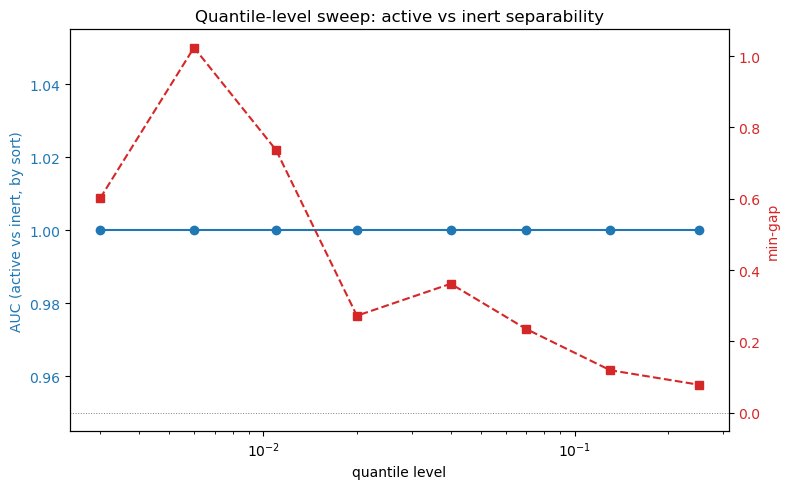

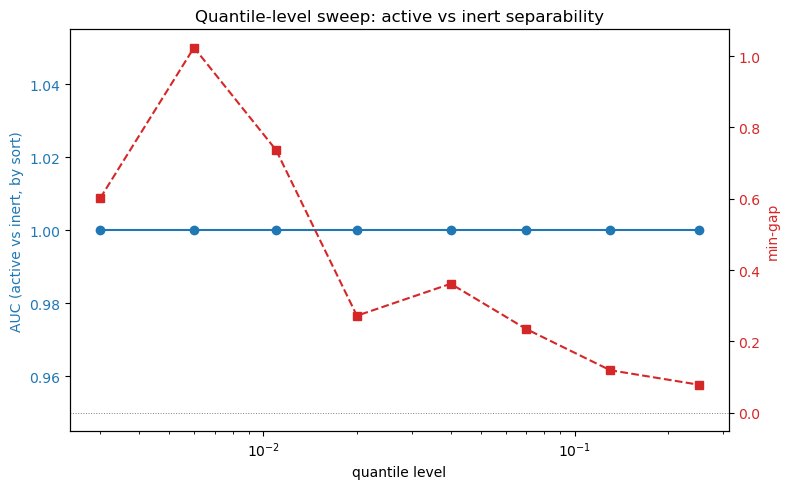

In [ ]:
# Quantile tuner goes here where we will import it and run it based on data_df_reg
import quantile_tuner as qt
import importlib
importlib.reload(qt)

artifacts, results, summary = qt.tune(
    data_df_reg=data_df_reg,
    eval_data=orb_pred,          # or orb/final — needs Num_opps, extension_difficulty, a, Principal_desig
    quantile_levels=[0.003, 0.006, 0.011, 0.02, 0.040, 0.07, 0.13, 0.25],
    # fast=True,
)
print(summary)                   # {"best_quantile_level": ..., "best_auc": ..., "best_min_gap": ..., "tiebreak_used": ...}
qt.plot_separability(results)

In [ ]:
results

,quantile_level,auc,min_gap,min_active_sort,max_inert_sort,n_active,n_inert
0,0.003,1.0,0.601628,3.379683,2.778055,14,1155793
1,0.006,1.0,1.023599,4.293551,3.269953,14,1155793
2,0.011,1.0,0.736735,4.657668,3.920933,14,1155793
3,0.020,1.0,0.272206,4.718336,4.446130,14,1155793
4,0.040,1.0,0.361768,5.065926,4.704157,14,1155793
5,0.070,1.0,0.234661,5.481317,5.246656,14,1155793
6,0.130,1.0,0.119503,6.017932,5.898429,14,1155793
7,0.250,1.0,0.078939,6.518692,6.439753,14,1155793


# Curiosities

In [ ]:
# A curiousity: some of the most over-observed objects!
final_low = final[(final["exp_Num_opps"]>1) & (final["exp_Num_opps"]<1.5)]
final_low = final_low[final_low["Num_obs"]>13]
final_low = final_low[final_low["q"]>=1.3]

final_low.sort_values(by="poisson_cdf", ascending=False)[['Number','H','Num_opps','poisson_cdf','exp_Num_opps','prob']]

In [ ]:
# See which manually filtered (in csv) objects rank the highest... did we potentially filter out some in error?

default_col_set = ["prob", "DeltaQ", "poisson_cdf", "extension_difficulty", "Num_opps", "quantile_Opps", "exp_Num_opps", "nights_total",  "Ref", "Num_obs", "Arc_length", "U","a","i","H","q","TJ"]
# engineer a feature that grades overall "priority" of follow up based on a gradient such that up and to the left on the scatterplot below is higher priority and lines of equal priority are parallel to the point going from 0,4 to 0.8,11
orb_pred_incl_mislinkages["priority_score"] = orb_pred_incl_mislinkages["DeltaQ"] - (orb_pred_incl_mislinkages["extension_difficulty"] * (10-3.8)/(0.4-0))

filtered_rankings = orb_pred_incl_mislinkages[((orb_pred_incl_mislinkages["Arc_length"]>=8)|(orb_pred_incl_mislinkages["Arc_length"].isna()))
      &(orb_pred_incl_mislinkages["Num_obs"]>=6)
      &(orb_pred_incl_mislinkages["filtered_out"].astype(bool)==True)

      # Admitted this is a bit of a hack but it excludes THOR objects with odd sparsity
      &((orb_pred_incl_mislinkages["Num_obs"]>=7)|(orb_pred_incl_mislinkages["nights_total"]>=5))

      &(orb_pred_incl_mislinkages["DeltaQ"]>0.3*orb_pred_incl_mislinkages["quantile_Opps"])

      &(orb_pred_incl_mislinkages["prob"]>0.9)
      &(orb_pred_incl_mislinkages["q"]>1.1)
      &((orb_pred_incl_mislinkages["extension_difficulty"].between(0,0.9))|(orb_pred_incl_mislinkages["nights_total"].isna()))
      &(orb_pred_incl_mislinkages["Orbital_period"]<20)].copy()

filtered_rankings.sort_values("priority_score", ascending=False, inplace=True)

filtered_rankings.head(1000)[['Known / Strong Suspect']+default_col_set].head(25)

,Known / Strong Suspect,prob,DeltaQ,poisson_cdf,extension_difficulty,Num_opps,quantile_Opps,exp_Num_opps,nights_total,Ref,Num_obs,Arc_length,U,a,i,H,q,TJ
Principal_desig,,,,,,,,,,,,,,,,,,
1988 RH9,False,0.999988,22.885965,6.821879e-16,0.001320,1,23.885965,35.921227,7.0,MPO121290,15,11,10,2.631991,19.16897,11.06,1.837113,3.257699
2025 QG193,False,0.999972,5.078355,1.395394e-04,0.021657,1,6.078355,9.877164,3.0,E2026-HE1,7,11,9,2.938208,1.15124,17.35,2.329198,3.24082
2014 EQ71,False,0.999983,4.382321,4.611956e-04,0.000430,2,6.382321,11.087507,7.0,MPO703687,20,<NA>,6,2.918478,1.62323,17.22,2.408885,3.25707
2026 EH29,False,0.999097,4.291929,1.194859e-04,0.000082,1,5.291929,10.032312,4.0,E2026-H99,24,14,7,5.241783,9.73045,14.59,4.976065,2.968618
2014 EU123,False,0.999978,5.21685,1.338741e-04,0.076331,1,6.216850,9.918611,4.0,MPO987419,10,12,8,2.634771,7.97397,17.50,2.395606,3.378393
2014 QS209,False,0.999984,3.71505,3.544114e-03,0.000876,2,5.715050,8.819424,5.0,MPO519599,18,<NA>,5,3.047305,20.91388,16.40,2.117515,3.06899
2013 EH143,False,0.999960,3.619527,2.196291e-03,0.003451,2,5.619527,9.357123,5.0,E2024-V74,18,<NA>,7,2.271064,4.25908,17.85,1.318054,3.487066
2014 WL185,False,0.999445,3.359955,1.540533e-04,0.000258,1,4.359955,9.778212,4.0,MPO771218,14,31,7,2.524428,9.09592,17.51,1.907493,3.394939
2025 QU66,False,0.997232,3.205694,5.825412e-04,0.000195,1,4.205694,8.448111,4.0,MPO950580,11,31,6,5.20243,19.55756,14.68,4.997872,2.88316


In [ ]:
# A random sample of mislinkages and secure linkages:

orb_pred_incl_mislinkages[
    (orb_pred_incl_mislinkages["extension_difficulty"] > 0.8)
    & (orb_pred_incl_mislinkages["prob"] > 0.999)
    & (orb_pred_incl_mislinkages["U"] < 9)
    & (orb_pred_incl_mislinkages["Num_opps"] > 1)
    # also exclude anything with Principal_desig starting with "2010" since those are all C51 and a different thing
    & (~orb_pred_incl_mislinkages.index.str.startswith("2010"))
].sample(5)["prob"]

23

2020 RR101    0.999393
2016 FM126    0.999965
2023 TO165    0.999232
2014 YA43     0.999986
2014 HR544    0.999487

A random sample of highly-ranked objects with extension_difficulty > 0.8 (mislinkage type) includes:
2020 RR$_{101}$, 2016 FM$_{126}, 2023 TO$_{165}, 2014 YA$_{43}, and 2014 HR$_{544}

In [ ]:
# A random sample of mislinkages and secure linkages:

orb_pred_incl_mislinkages[
    (orb_pred_incl_mislinkages["extension_difficulty"] > 0.8)
    & (orb_pred_incl_mislinkages["prob"] > 0.999)
    & (orb_pred_incl_mislinkages["Arc_length"] > 25)
    # also exclude anything with Principal_desig starting with "2010" since those are all C51 and a different thing
    & (~orb_pred_incl_mislinkages.index.str.startswith("2010"))
]

,Critical_list_numbered_object_flag,H,G,Num_obs,rms,U,Arc_years,Perturbers,Perturbers_2,Number,...,exp_Num_opps,quantile_Opps,prob,poisson_cdf,v_mag_gap,second_minmax_gap,v_mag_gap_1,v_mag_gap_2,DeltaQ,Known / Strong Suspect
Principal_desig,,,,,,,,,,,,,,,,,,,,,
1927 LA,<NA>,11.00,0.15,3,<NA>,10,<NA>,<NA>,<NA>,<NA>,...,44.159149,25.022541,0.999994,1.803930e-19,0.00,NaN,0.000000,0.000000,24.022541,False
1939 RR,<NA>,12.00,0.15,3,<NA>,10,<NA>,<NA>,<NA>,<NA>,...,33.801739,23.203217,0.999994,5.680491e-15,NaN,NaN,NaN,NaN,22.203217,False
2009 AN42,<NA>,16.70,0.15,9,0.44,10,<NA>,<NA>,<NA>,<NA>,...,18.066471,14.126070,0.999996,3.873698e-08,0.80,0.00,0.266667,0.533333,13.12607,False
2021 HQ25,<NA>,16.10,0.15,11,0.22,6,<NA>,M-v,38h,<NA>,...,13.203571,9.378091,0.999997,5.012522e-06,0.30,0.20,0.157143,0.142857,8.378091,False
2008 AM127,<NA>,16.89,0.15,10,0.2,10,<NA>,<NA>,<NA>,<NA>,...,13.418064,9.299411,0.999996,4.044858e-06,0.90,0.80,0.550000,0.350000,8.299411,False
2017 JY13,<NA>,16.36,0.15,7,0.7,5,<NA>,M-v,3Ek,<NA>,...,11.770097,8.028437,0.999996,2.101873e-05,1.99,1.39,0.955714,1.034286,7.028437,False
2002 GH177,<NA>,17.13,0.15,5,0.38,7,<NA>,M-v,3Ek,<NA>,...,11.543504,6.983770,0.999994,2.636419e-05,0.50,0.29,0.202500,0.297500,5.98377,False
2009 UO63,<NA>,18.30,0.15,12,0.27,10,<NA>,<NA>,<NA>,<NA>,...,10.338572,6.301746,0.999986,8.796500e-05,0.90,0.70,0.408333,0.491667,5.301746,False
2008 SL297,<NA>,17.70,0.15,12,0.6,10,<NA>,<NA>,<NA>,<NA>,...,9.354474,5.771465,0.999983,2.353412e-04,1.70,0.10,1.000000,0.700000,4.771465,False


In [ ]:
# A random sample of mislinkages and secure linkages:

orb_pred_incl_mislinkages[
    (orb_pred_incl_mislinkages["extension_difficulty"] > 0.8)
    & (orb_pred_incl_mislinkages["prob"] > 0.999)
    & (orb_pred_incl_mislinkages["Arc_length"] < 6)
    # also exclude anything with Principal_desig starting with "2010" since those are all C51 and a different thing
    & (~orb_pred_incl_mislinkages.index.str.startswith("2010"))
].sample(5)["prob"]

Principal_desig
2014 EJ130    0.999383
2014 EA235    0.999454
2014 EH74     0.999995
2014 EV114    0.999454
2014 EZ127    0.999867
Name: prob, dtype: float64

2014 EJ130    0.999383
2014 EA235    0.999454
2014 EH74     0.999995
2014 EV114    0.999454
2014 EZ127    0.999867

A random sample of highly-ranked objects with extension_difficulty > 0.8 (uncertainty type) includes:
2014 EJ$_{130}, 2014 EA$_{235}, 2014 EH$_{74}, 2014 EV$_{114}, 2014 EZ$_{127}

In [ ]:
# A random sample of good linkages:

orb_pred_incl_mislinkages[
    (orb_pred_incl_mislinkages["extension_difficulty"] < 0.001)
    & (orb_pred_incl_mislinkages["prob"] > 0.998)
    & (orb_pred_incl_mislinkages["Num_opps"] == 1)
    # also exclude anything with Principal_desig starting with "2010" since those are all C51 and a different thing
    & (~orb_pred_incl_mislinkages.index.str.startswith("2010"))
].sample(5)["prob"]

Principal_desig
2025 MA349    0.999953
2020 HE197    0.999992
2016 HM15     0.999972
2020 RZ21     0.998360
2015 HK383    0.999750
Name: prob, dtype: float64

2025 MA349    0.999953
2020 HE197    0.999992
2016 HM15     0.999972
2020 RZ21     0.998360
2015 HK383    0.999750

A random sample of highly-ranked objects with extension_difficulty < 0.001 (secure, extensible orbit) includes:
2025 MA$_{349}, 2020 HE$_{197}, 2016 HM$_{15}, 2020 RZ$_{21}, 2015 HK$_{383}$